# Bureau / Bureau Balance 1차 EDA

외부 금융기관 신용계약(`bureau`)과 계약별 월간 상태 이력(`bureau_balance`)을 분석한다.

- 현재 범위: 테이블 관계, 키·중복, 자료형·코드값 점검
- 분석 단위: 월별 이력 → 계약(`SK_ID_BUREAU`) → 고객(`SK_ID_CURR`)
- 원칙: 원시 월별 행을 고객 또는 Application 테이블에 직접 결합하지 않는다.
- `application_train/test`는 고객 단위 피처 완성 후 `TARGET` 분석과 train/test 비교 단계에서만 사용한다.


## 목차

1. [분석 목적과 범위](#1.-분석-목적과-범위)
2. [환경 설정 및 데이터 로딩](#2.-환경-설정-및-데이터-로딩)
3. [구조와 기초 품질 점검](#3.-구조와-기초-품질-점검)
   - [3.1 테이블 관계](#3.1-테이블-관계)
   - [3.2 키·중복·고아 키](#3.2-키·중복·고아-키)
   - [3.3 자료형·결측률·코드값](#3.3-자료형·결측률·코드값)
4. [데이터 품질 및 이상치 탐지](#4.-데이터-품질-및-이상치-탐지)
5. [계약·고객 단위 파생변수](#5.-계약·고객-단위-파생변수)
   - [5.1 bureau_balance 계약 단위 특성](#5.1-bureau_balance-계약-단위-특성)
   - [5.2 bureau 고객 단위 특성](#5.2-bureau-고객-단위-특성)
   - [5.3 결합 고객 단위 특성](#5.3-결합-고객-단위-특성)
   - [5.4 검증과 노트북 내 재사용](#5.4-검증과-노트북-내-재사용)
6. [기초 시각화](#6.-기초-시각화)
   - [6.1 계약 규모와 이력 길이](#6.1-계약-규모와-이력-길이)
   - [6.2 계약 구성과 최신 상태](#6.2-계약-구성과-최신-상태)
   - [6.3 총신용과 총부채 관계](#6.3-총신용과-총부채-관계)
   - [6.4 월별 이력 커버리지와 최근 연체](#6.4-월별-이력-커버리지와-최근-연체)
7. [Application 통합 및 TARGET 설명 분석](#7.-application-통합-및-target-설명-분석)
   - [7.1 Application 전체 통합과 이력 커버리지](#7.1-application-전체-통합과-이력-커버리지)
   - [7.2 계약 규모·활성·부채 비율과 TARGET](#7.2-계약-규모활성부채-비율과-target)
   - [7.3 월별 연체 이력과 TARGET](#7.3-월별-연체-이력과-target)
8. [결론 및 다음 분석](#8.-결론-및-다음-분석)


## 1. 분석 목적과 범위

이번 1차 EDA에서는 두 이력 테이블의 구조를 먼저 검증한다.

1. `bureau.SK_ID_BUREAU`가 계약 키로 유일한지 확인한다.
2. `bureau_balance`의 `SK_ID_BUREAU + MONTHS_BALANCE`가 월별 관측 키로 유일한지 확인한다.
3. 완전 중복, 키 충돌, 정상적인 반복 계약·월별 관측을 구분한다.
4. `STATUS`를 포함한 범주형 코드와 수치형 컬럼의 자료형·결측률을 확인한다.
5. 이후 EDA가 계약 단위와 고객 단위로 안전하게 확장될 수 있는지 검증한다.


## 2. 환경 설정 및 데이터 로딩

현재 단계에서는 `bureau.csv`와 `bureau_balance.csv`만 불러온다. Application 데이터는 후속 `TARGET` 분석 전까지 사용하지 않는다.


In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "data" / "raw").is_dir() and (candidate / "EDA" / "jsw").is_dir():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다. 노트북을 프로젝트 내부에서 실행하세요.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "data" / "raw"
FILE_PATHS = {
    "bureau": DATA_DIR / "bureau.csv",
    "bureau_balance": DATA_DIR / "bureau_balance.csv",
}

missing_files = [str(path) for path in FILE_PATHS.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"다음 원본 파일을 찾을 수 없습니다: {missing_files}")

pd.DataFrame(
    {
        "table": FILE_PATHS.keys(),
        "path": [str(path) for path in FILE_PATHS.values()],
        "size_mb": [path.stat().st_size / (1024**2) for path in FILE_PATHS.values()],
    }
)


,table,path,size_mb
0,bureau,D:\FinDA-2-A-Project\data\raw\bureau.csv,162.1406
1,bureau_balance,D:\FinDA-2-A-Project\data\raw\bureau_balance.csv,358.1933


#### 실행 결과 해석 — 분석 파일 확인

**확인 내용**

- 분석 대상 파일은 프로젝트의 `data/raw`에서 정상적으로 확인됐다.
- CSV 파일 크기는 `bureau` 약 162.14MB, `bureau_balance` 약 358.19MB이다.
- 현재 단계에서 Application 데이터는 불러오지 않았으므로 분석 범위가 외부 신용계약과 월별 상태 이력에 한정돼 있다.

**해석**

파일 경로 검증을 통과했으므로 이후 결과는 의도한 두 원본 테이블을 기준으로 한다. `bureau_balance`는 디스크 크기부터 `bureau`보다 크므로, 반복적인 전체 행 연산을 피하고 계약·월 키 집계 결과를 재사용할 필요가 있다.


In [24]:
bureau = pd.read_csv(
    FILE_PATHS["bureau"],
    encoding="utf-8-sig",
    low_memory=False,
)
bureau_balance = pd.read_csv(
    FILE_PATHS["bureau_balance"],
    encoding="utf-8-sig",
    low_memory=False,
)

tables = {
    "bureau": bureau,
    "bureau_balance": bureau_balance,
}

table_overview = pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "memory_mb": df.memory_usage(deep=True).sum() / (1024**2),
        }
        for name, df in tables.items()
    ]
)
display(table_overview)


,table,rows,columns,memory_mb
0,bureau,1716428,17,271.4845
1,bureau_balance,27299925,3,650.8811


#### 실행 결과 해석 — 테이블 규모

**확인 내용**

| 테이블 | 행 수 | 열 수 | 메모리 사용량 |
|---|---:|---:|---:|
| `bureau` | 1,716,428 | 17 | 약 271.48MB |
| `bureau_balance` | 27,299,925 | 3 | 약 650.88MB |

**해석**

- 두 테이블의 메모리 사용량은 합계 약 922MB이며, 월별 이력 테이블이 전체 처리 비용의 대부분을 차지한다.
- `bureau`는 계약 단위, `bureau_balance`는 계약별 월 단위이므로 행 수 차이는 정상적인 1:N 관계에서 발생할 수 있다.
- 이후 EDA에서는 `bureau_balance` 원본을 시각화나 조인 때마다 반복 순회하지 않고, 계약 단위 중간 집계표를 만들어 재사용하는 방식이 적합하다.


## 3. 구조와 기초 품질 점검

### 3.1 테이블 관계

두 테이블의 분석 단위는 다음과 같다.

```text
bureau_balance: 계약별 월간 상태 여러 행
        ↓ SK_ID_BUREAU 단위 집계
bureau: 외부 신용계약 1행
        ↓ SK_ID_CURR 단위 집계
고객별 외부 신용 피처 1행
```

원시 `bureau_balance` 행을 `bureau`나 Application에 그대로 붙이면 행이 증폭되므로 반드시 위 순서를 지킨다.


In [25]:
def distribution_summary(series: pd.Series, name: str) -> pd.DataFrame:
    quantiles = series.quantile([0, 0.01, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
    result = quantiles.rename_axis("quantile").reset_index(name="value")
    result.insert(0, "metric", name)
    result["mean"] = series.mean()
    result["std"] = series.std()
    return result


def column_profile(df: pd.DataFrame, table_name: str) -> pd.DataFrame:
    profile = pd.DataFrame(
        {
            "table": table_name,
            "column": df.columns,
            "dtype": df.dtypes.astype(str).values,
            "non_null_count": df.notna().sum().values,
            "missing_count": df.isna().sum().values,
            "missing_rate": df.isna().mean().values,
            "nunique_including_na": [df[column].nunique(dropna=False) for column in df.columns],
        }
    )
    profile["role"] = np.select(
        [
            profile["column"].str.startswith("SK_ID_"),
            profile["dtype"].isin(["object", "str", "string", "category"]),
        ],
        ["join_key", "categorical"],
        default="numeric_or_other",
    )
    return profile.sort_values(["role", "missing_rate"], ascending=[True, False])


#### 셀 설명 — 공통 점검 함수

이 셀은 데이터를 분석하지 않고 이후 표를 만들기 위한 함수를 정의한다.

- `distribution_summary`: 최솟값, 주요 분위수, 평균과 표준편차를 같은 형식으로 반환한다.
- `column_profile`: 자료형, 결측 수·비율, 고유값 수와 컬럼 역할을 정리한다.
- 함수 정의만 수행하므로 출력이 없는 것이 정상이다.

문자열 자료형은 환경에 따라 `object`, `str`, `string`, `category`로 표시될 수 있어 모두 범주형으로 분류한다.


### 3.2 키·중복·고아 키

다음 항목을 서로 구분해서 확인한다.

- `bureau.SK_ID_BUREAU` 계약 키의 유일성
- `bureau_balance.SK_ID_BUREAU + MONTHS_BALANCE` 계약-월 키의 유일성
- 모든 값이 같은 완전 중복과, 같은 키에서 `STATUS`가 다른 충돌
- `bureau_balance`에만 존재하는 고아 계약 ID
- 고객별 계약 수와 계약별 월 관측 수

`bureau_balance`는 행 수가 크므로 계약-월 그룹을 한 번 계산한 뒤 모든 중복 지표에 재사용한다.


In [26]:
BB_KEYS = ["SK_ID_BUREAU", "MONTHS_BALANCE"]
bb_value_columns = [column for column in bureau_balance.columns if column not in BB_KEYS]

if bb_value_columns != ["STATUS"]:
    raise ValueError(
        "현재 중복 점검은 bureau_balance의 비키 컬럼이 STATUS 하나인 구조를 전제로 합니다. "
        f"실제 비키 컬럼: {bb_value_columns}"
    )

# 대용량 원본에 duplicated()를 반복하지 않고 동일한 그룹 정보를 재사용한다.
bb_grouped = bureau_balance.groupby(BB_KEYS, dropna=False, sort=False)["STATUS"]
bb_key_profile = pd.concat(
    [
        bb_grouped.size().rename("ROW_COUNT"),
        bb_grouped.nunique(dropna=False).rename("DISTINCT_STATUS_COUNT"),
    ],
    axis=1,
).reset_index()

bb_duplicate_key_mask = bb_key_profile["ROW_COUNT"] > 1
bb_conflict_key_mask = bb_key_profile["DISTINCT_STATUS_COUNT"] > 1
bb_exact_duplicate_mask = bb_key_profile["ROW_COUNT"] > bb_key_profile["DISTINCT_STATUS_COUNT"]

bureau_key_counts = bureau.groupby("SK_ID_BUREAU", dropna=False, sort=False).size()
bureau_duplicate_key_mask = bureau_key_counts > 1
bureau_exact_duplicate_mask = bureau.duplicated(keep=False)
bureau_distinct_rows = bureau.drop_duplicates()
bureau_conflict_mask = bureau_distinct_rows.duplicated("SK_ID_BUREAU", keep=False)

key_checks = pd.DataFrame(
    [
        {
            "table": "bureau",
            "keys": "SK_ID_BUREAU",
            "missing_key_rows": int(bureau["SK_ID_BUREAU"].isna().sum()),
            "unique_key_count": len(bureau_key_counts),
            "duplicate_key_rows": int(bureau_key_counts[bureau_duplicate_key_mask].sum()),
            "duplicate_key_extra_rows": int((bureau_key_counts[bureau_duplicate_key_mask] - 1).sum()),
            "conflicting_key_count": int(
                bureau_distinct_rows.loc[bureau_conflict_mask, "SK_ID_BUREAU"].nunique(dropna=False)
            ),
            "is_unique": bool(
                not bureau_duplicate_key_mask.any() and not bureau["SK_ID_BUREAU"].isna().any()
            ),
        },
        {
            "table": "bureau_balance",
            "keys": "SK_ID_BUREAU + MONTHS_BALANCE",
            "missing_key_rows": int(bureau_balance[BB_KEYS].isna().any(axis=1).sum()),
            "unique_key_count": len(bb_key_profile),
            "duplicate_key_rows": int(bb_key_profile.loc[bb_duplicate_key_mask, "ROW_COUNT"].sum()),
            "duplicate_key_extra_rows": int(
                (bb_key_profile.loc[bb_duplicate_key_mask, "ROW_COUNT"] - 1).sum()
            ),
            "conflicting_key_count": int(bb_conflict_key_mask.sum()),
            "is_unique": bool(
                not bb_duplicate_key_mask.any()
                and not bureau_balance[BB_KEYS].isna().any(axis=1).any()
            ),
        },
    ]
)

duplicate_checks = pd.DataFrame(
    [
        {
            "table": "bureau",
            "exact_duplicate_extra_rows": int(bureau.duplicated(keep="first").sum()),
            "rows_in_exact_duplicate_groups": int(bureau_exact_duplicate_mask.sum()),
        },
        {
            "table": "bureau_balance",
            "exact_duplicate_extra_rows": int(
                (bb_key_profile["ROW_COUNT"] - bb_key_profile["DISTINCT_STATUS_COUNT"]).sum()
            ),
            "rows_in_exact_duplicate_groups": int(
                bb_key_profile.loc[bb_exact_duplicate_mask, "ROW_COUNT"].sum()
            ),
        },
    ]
)

bureau_contract_ids = set(bureau["SK_ID_BUREAU"].dropna().unique())
bb_contract_ids = set(bb_key_profile["SK_ID_BUREAU"].dropna().unique())
orphan_bb_ids = bb_contract_ids - bureau_contract_ids
contract_link_check = pd.DataFrame(
    [
        {
            "check": "bureau_balance 계약 ID -> bureau 연결",
            "base_unique_ids": len(bb_contract_ids),
            "matched_unique_ids": len(bb_contract_ids & bureau_contract_ids),
            "unmatched_unique_ids": len(orphan_bb_ids),
            "match_rate": len(bb_contract_ids & bureau_contract_ids) / len(bb_contract_ids),
        }
    ]
)

contracts_per_customer = bureau.groupby("SK_ID_CURR", dropna=False)["SK_ID_BUREAU"].nunique()
months_per_contract = bb_key_profile.groupby("SK_ID_BUREAU", dropna=False).size()
relationship_distributions = pd.concat(
    [
        distribution_summary(contracts_per_customer, "contracts_per_customer"),
        distribution_summary(months_per_contract, "observed_months_per_contract"),
    ],
    ignore_index=True,
)

display(key_checks)
display(duplicate_checks)
display(contract_link_check)
display(relationship_distributions)
display(pd.DataFrame({"orphan_SK_ID_BUREAU": sorted(orphan_bb_ids)}).head(20))


,table,keys,missing_key_rows,unique_key_count,duplicate_key_rows,duplicate_key_extra_rows,conflicting_key_count,is_unique
0,bureau,SK_ID_BUREAU,0,1716428,0,0,0,True
1,bureau_balance,SK_ID_BUREAU + MONTHS_BALANCE,0,27299925,0,0,0,True


,table,exact_duplicate_extra_rows,rows_in_exact_duplicate_groups
0,bureau,0,0
1,bureau_balance,0,0


,check,base_unique_ids,matched_unique_ids,unmatched_unique_ids,match_rate
0,bureau_balance 계약 ID -> bureau 연결,817395,774354,43041,0.9473


,metric,quantile,value,mean,std
0,contracts_per_customer,0.0000,1.0000,5.6127,4.4304
1,contracts_per_customer,0.0100,1.0000,5.6127,4.4304
2,contracts_per_customer,0.2500,2.0000,5.6127,4.4304
3,contracts_per_customer,0.5000,4.0000,5.6127,4.4304
4,contracts_per_customer,0.7500,8.0000,5.6127,4.4304
5,contracts_per_customer,0.9500,14.0000,5.6127,4.4304
6,contracts_per_customer,0.9900,21.0000,5.6127,4.4304
7,contracts_per_customer,1.0000,116.0000,5.6127,4.4304
8,observed_months_per_contract,0.0000,1.0000,33.3987,25.7947
9,observed_months_per_contract,0.0100,2.0000,33.3987,25.7947


,orphan_SK_ID_BUREAU
0,5001709
1,5001740
2,5001761
3,5001781
4,5001801
5,5001822
6,5001826
7,5001866
8,5001868
9,5001869


#### 실행 결과 해석 — 키·중복·연결 관계

**1. 키 무결성**

- `bureau.SK_ID_BUREAU` 1,716,428개는 모두 유일하며 결측 키가 없다.
- `bureau_balance`의 `SK_ID_BUREAU + MONTHS_BALANCE` 27,299,925개 조합도 모두 유일하며 결측 키가 없다.
- 두 테이블 모두 완전 중복 행과 동일 키 내 값 충돌이 0건이다.

따라서 현재 원본에서는 중복 제거가 필요하지 않다. 한 고객에게 여러 계약이 있거나 한 계약에 여러 월별 행이 있는 것은 중복이 아니라 테이블의 정상적인 반복 구조이다.

**2. 계약 ID 연결**

- `bureau_balance`의 계약 ID 817,395개 중 774,354개가 `bureau`에 연결된다.
- 연결되지 않는 계약 ID는 43,041개로, `bureau_balance` 계약의 5.27%이다.
- 반대로 계산하면 `bureau` 계약 1,716,428개 중 월별 이력이 연결되는 계약은 45.11%이며, 942,074개(54.89%)는 `bureau_balance` 이력이 없다.

고아 계약 43,041개는 `SK_ID_CURR`로 연결할 수 없으므로 고객 피처에는 직접 사용할 수 없다. 다만 이를 즉시 오류나 삭제 대상으로 단정할 수는 없으며, 별도 품질 지표로 수량과 비율을 보존해야 한다. `bureau`에 있지만 월별 이력이 없는 계약도 값 0과 구분해 `HAS_BUREAU_BALANCE` 플래그로 관리해야 한다.

**3. 반복 구조의 분포**

- 고객별 계약 수는 평균 5.61개, 중앙값 4개, 75백분위 8개, 95백분위 14개, 99백분위 21개이며 최댓값은 116개이다.
- 계약별 관측 월 수는 평균 33.40개월, 중앙값 26개월, 75백분위 48개월, 95백분위 90개월이며 최댓값은 97개월이다.

고객별 계약 수는 평균이 중앙값보다 높고 최댓값이 99백분위보다 크게 나타나 오른쪽 꼬리가 긴 분포이다. 계약 수가 많은 고객은 자동 제외하지 않고 극단값 플래그와 로그 축 시각화 대상으로 다룬다. 관측 월 수도 계약마다 크게 다르므로 연체 횟수만 비교하지 말고 관측 월 수로 나눈 비율과 최소 관측기간 조건을 함께 사용해야 한다.


In [27]:
# 키 검증을 통과한 경우에만 월별 이력 → 계약 → 고객 순서의 구조를 확인한다.
bureau_key_is_unique = bool(key_checks.loc[key_checks["table"] == "bureau", "is_unique"].iloc[0])
bb_month_key_is_unique = bool(
    key_checks.loc[key_checks["table"] == "bureau_balance", "is_unique"].iloc[0]
)
relationship_ready = bureau_key_is_unique and bb_month_key_is_unique

if not relationship_ready:
    print("키 중복 또는 충돌이 있어 구조 집계를 중단합니다. 위 점검표에서 원인을 먼저 확인하세요.")
else:
    if orphan_bb_ids:
        print(
            f"고아 bureau_balance 계약 {len(orphan_bb_ids):,}개는 별도 보고하고, "
            "bureau 기준 계약·고객 집계에서는 제외합니다."
        )
    bb_contract_level = (
        bb_key_profile.groupby("SK_ID_BUREAU", as_index=False)
        .agg(
            BB_MONTH_ROW_COUNT=("ROW_COUNT", "sum"),
            BB_DISTINCT_MONTH_COUNT=("MONTHS_BALANCE", "size"),
            BB_OLDEST_MONTH=("MONTHS_BALANCE", "min"),
            BB_LATEST_MONTH=("MONTHS_BALANCE", "max"),
        )
    )
    assert bb_contract_level["SK_ID_BUREAU"].is_unique

    bureau_contract_level = bureau.merge(
        bb_contract_level,
        on="SK_ID_BUREAU",
        how="left",
        validate="one_to_one",
    )
    bureau_contract_level["HAS_BUREAU_BALANCE"] = bureau_contract_level[
        "BB_MONTH_ROW_COUNT"
    ].notna()

    bureau_customer_level = (
        bureau_contract_level.groupby("SK_ID_CURR", as_index=False)
        .agg(
            BUR_CONTRACT_COUNT=("SK_ID_BUREAU", "nunique"),
            BB_CONTRACT_WITH_HISTORY_COUNT=("HAS_BUREAU_BALANCE", "sum"),
            BB_TOTAL_MONTH_ROW_COUNT=("BB_MONTH_ROW_COUNT", "sum"),
        )
    )
    assert bureau_customer_level["SK_ID_CURR"].is_unique

    aggregation_grain_check = pd.DataFrame(
        [
            {
                "level": "bureau_balance raw",
                "key": "SK_ID_BUREAU + MONTHS_BALANCE",
                "rows": len(bureau_balance),
                "key_is_unique": bb_month_key_is_unique,
            },
            {
                "level": "contract",
                "key": "SK_ID_BUREAU",
                "rows": len(bureau_contract_level),
                "key_is_unique": bureau_contract_level["SK_ID_BUREAU"].is_unique,
            },
            {
                "level": "customer",
                "key": "SK_ID_CURR",
                "rows": len(bureau_customer_level),
                "key_is_unique": bureau_customer_level["SK_ID_CURR"].is_unique,
            },
        ]
    )
    display(aggregation_grain_check)


고아 bureau_balance 계약 43,041개는 별도 보고하고, bureau 기준 계약·고객 집계에서는 제외합니다.


,level,key,rows,key_is_unique
0,bureau_balance raw,SK_ID_BUREAU + MONTHS_BALANCE,27299925,True
1,contract,SK_ID_BUREAU,1716428,True
2,customer,SK_ID_CURR,305811,True


#### 앞선 결과를 반영한 집계 정책

**확인 내용**

이전 실행에서는 키 중복이나 충돌이 아니라 `bureau_balance`에만 존재하는 고아 계약 43,041개 때문에 집계가 중단됐다. 앞선 해석에 따라 고아 계약은 별도 품질 지표로 보고하되, 연결 가능한 계약의 집계는 계속 진행하도록 조건을 수정했다.

**해석 및 후속 처리 원칙**

- 키 무결성은 이미 확인됐으므로 774,354개의 연결 가능한 계약은 계약 단위로 집계할 수 있다.
- 연결되지 않는 43,041개 계약은 별도 고아 키 보고표에 유지하고, 고객 단위 피처 계산에서는 제외됐음을 명시해야 한다.
- `bureau`를 기준으로 왼쪽 결합하면 월별 이력이 없는 942,074개 계약도 보존할 수 있다.
- 이력 없음은 연체 0과 의미가 다르므로 건수 외의 최근 상태·비율·기간 피처는 임의로 0 대체하지 않고 결측을 유지하며 `HAS_BUREAU_BALANCE`를 함께 제공한다.

수정된 셀은 `bureau`를 기준으로 계약 1,716,428개를 보존하고, 연결 가능한 774,354개 계약에는 월별 이력 요약을 붙인다. 나머지 942,074개 계약은 `HAS_BUREAU_BALANCE=False`로 구분한다. 고아 계약 43,041개는 고객 ID로 연결할 수 없으므로 고객 단위 집계에서는 제외되지만 별도 보고 수치는 유지한다.


### 3.3 자료형·결측률·코드값

- ID 컬럼은 설명변수가 아니라 연결 키로 취급한다.
- `STATUS`가 `0`~`5`, `C`, `X`로 구성되는지 확인한다.
- `C`는 종료, `X`는 상태 미상으로 유지하며 정상 상태 `0`과 합치지 않는다.
- 금액·일수·월 변수의 자료형과 결측률을 확인한다.
- 범주형 컬럼의 빈도, 희소 범주와 예상하지 못한 코드값을 확인한다.


In [28]:
bureau_profile = column_profile(bureau, "bureau")
bureau_balance_profile = column_profile(bureau_balance, "bureau_balance")
column_profiles = pd.concat([bureau_profile, bureau_balance_profile], ignore_index=True)

id_type_checks = column_profiles.loc[
    column_profiles["column"].str.startswith("SK_ID_"),
    ["table", "column", "dtype", "missing_count", "nunique_including_na", "role"],
]

amount_day_month_mask = column_profiles["column"].str.contains(
    r"(?:^AMT_|^DAYS_|MONTHS_)", regex=True
)
amount_day_month_checks = column_profiles.loc[
    amount_day_month_mask,
    ["table", "column", "dtype", "missing_count", "missing_rate", "nunique_including_na"],
]

expected_status = {"0", "1", "2", "3", "4", "5", "C", "X"}
status_as_string = bureau_balance["STATUS"].astype("string")
actual_status = set(status_as_string.dropna().unique())
status_counts = (
    status_as_string.value_counts(dropna=False)
    .rename_axis("STATUS")
    .reset_index(name="count")
)
status_counts["rate"] = status_counts["count"] / len(bureau_balance)
status_counts["meaning"] = status_counts["STATUS"].map(
    {
        "0": "정상",
        "1": "1개월 연체",
        "2": "2개월 연체",
        "3": "3개월 연체",
        "4": "4개월 연체",
        "5": "5개월 이상 연체",
        "C": "종료",
        "X": "상태 미상",
    }
).fillna("예상하지 못한 코드 또는 결측")
status_validation = pd.DataFrame(
    {
        "check": ["expected_codes", "actual_codes", "unexpected_codes", "missing_count"],
        "value": [
            sorted(expected_status),
            sorted(actual_status),
            sorted(actual_status - expected_status),
            int(status_as_string.isna().sum()),
        ],
    }
)

display(column_profiles)
display(id_type_checks)
display(amount_day_month_checks)
display(status_counts)
display(status_validation)

for table_name, df in tables.items():
    categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns
    for column in categorical_columns:
        frequency = (
            df[column]
            .value_counts(dropna=False)
            .rename_axis("value")
            .reset_index(name="count")
        )
        frequency["rate"] = frequency["count"] / len(df)
        frequency["is_rare_below_0.1pct"] = frequency["rate"] < 0.001
        print(f"[{table_name}.{column}] unique including NA = {df[column].nunique(dropna=False):,}")
        display(frequency)


,table,column,dtype,non_null_count,missing_count,missing_rate,nunique_including_na,role
0,bureau,CREDIT_ACTIVE,str,1716428,0,0.0000,4,categorical
1,bureau,CREDIT_CURRENCY,str,1716428,0,0.0000,4,categorical
2,bureau,CREDIT_TYPE,str,1716428,0,0.0000,15,categorical
3,bureau,SK_ID_CURR,int64,1716428,0,0.0000,305811,join_key
4,bureau,SK_ID_BUREAU,int64,1716428,0,0.0000,1716428,join_key
5,bureau,AMT_ANNUITY,float64,489637,1226791,0.7147,40322,numeric_or_other
6,bureau,AMT_CREDIT_MAX_OVERDUE,float64,591940,1124488,0.6551,68252,numeric_or_other
7,bureau,DAYS_ENDDATE_FACT,float64,1082775,633653,0.3692,2918,numeric_or_other
8,bureau,AMT_CREDIT_SUM_LIMIT,float64,1124648,591780,0.3448,51727,numeric_or_other
9,bureau,AMT_CREDIT_SUM_DEBT,float64,1458759,257669,0.1501,226538,numeric_or_other


,table,column,dtype,missing_count,nunique_including_na,role
3,bureau,SK_ID_CURR,int64,0,305811,join_key
4,bureau,SK_ID_BUREAU,int64,0,1716428,join_key
18,bureau_balance,SK_ID_BUREAU,int64,0,817395,join_key


,table,column,dtype,missing_count,missing_rate,nunique_including_na
5,bureau,AMT_ANNUITY,float64,1226791,0.7147,40322
6,bureau,AMT_CREDIT_MAX_OVERDUE,float64,1124488,0.6551,68252
7,bureau,DAYS_ENDDATE_FACT,float64,633653,0.3692,2918
8,bureau,AMT_CREDIT_SUM_LIMIT,float64,591780,0.3448,51727
9,bureau,AMT_CREDIT_SUM_DEBT,float64,257669,0.1501,226538
10,bureau,DAYS_CREDIT_ENDDATE,float64,105553,0.0615,14097
11,bureau,AMT_CREDIT_SUM,float64,13,0.0000,236709
12,bureau,DAYS_CREDIT,int64,0,0.0000,2923
15,bureau,AMT_CREDIT_SUM_OVERDUE,float64,0,0.0000,1616
16,bureau,DAYS_CREDIT_UPDATE,int64,0,0.0000,2982


,STATUS,count,rate,meaning
0,C,13646993,0.4999,종료
1,0,7499507,0.2747,정상
2,X,5810482,0.2128,상태 미상
3,1,242347,0.0089,1개월 연체
4,5,62406,0.0023,5개월 이상 연체
5,2,23419,0.0009,2개월 연체
6,3,8924,0.0003,3개월 연체
7,4,5847,0.0002,4개월 연체


,check,value
0,expected_codes,"[0, 1, 2, 3, 4, 5, C, X]"
1,actual_codes,"[0, 1, 2, 3, 4, 5, C, X]"
2,unexpected_codes,[]
3,missing_count,0


...

,value,count,rate,is_rare_below_0.1pct
0,currency 1,1715020,0.9992,False
1,currency 2,1224,0.0007,True
2,currency 3,174,0.0001,True
3,currency 4,10,0.0000,True


[bureau.CREDIT_TYPE] unique including NA = 15


,value,count,rate,is_rare_below_0.1pct
0,Consumer credit,1251615,0.7292,False
1,Credit card,402195,0.2343,False
2,Car loan,27690,0.0161,False
3,Mortgage,18391,0.0107,False
4,Microloan,12413,0.0072,False
5,Loan for business development,1975,0.0012,False
6,Another type of loan,1017,0.0006,True
7,Unknown type of loan,555,0.0003,True
8,Loan for working capital replenishment,469,0.0003,True
9,Cash loan (non-earmarked),56,0.0000,True


[bureau_balance.STATUS] unique including NA = 8


,value,count,rate,is_rare_below_0.1pct
0,C,13646993,0.4999,False
1,0,7499507,0.2747,False
2,X,5810482,0.2128,False
3,1,242347,0.0089,False
4,5,62406,0.0023,False
5,2,23419,0.0009,True
6,3,8924,0.0003,True
7,4,5847,0.0002,True


#### 실행 결과 해석 — 자료형·결측·범주값

**1. 자료형과 키**

- `SK_ID_CURR`, `SK_ID_BUREAU`, `MONTHS_BALANCE`는 정수형이며 연결 키에 결측이 없다.
- ID는 크기 자체에 수치적 의미가 없으므로 모델 설명변수나 상관분석 변수로 사용하지 않는다.
- `CREDIT_ACTIVE`, `CREDIT_CURRENCY`, `CREDIT_TYPE`, `STATUS`는 문자열 범주형이다. 이전 출력의 `role` 열에서 문자열이 `numeric_or_other`로 보인다면 프로파일러의 dtype 표기 차이 때문이며 원본 데이터 문제가 아니다. 분류 조건에 `str`을 반영했으므로 공통 함수 셀부터 다시 실행하면 범주형으로 표시된다.

**2. 결측률**

| 컬럼 | 결측 수 | 결측률 |
|---|---:|---:|
| `AMT_ANNUITY` | 1,226,791 | 71.47% |
| `AMT_CREDIT_MAX_OVERDUE` | 1,124,488 | 65.51% |
| `DAYS_ENDDATE_FACT` | 633,653 | 36.92% |
| `AMT_CREDIT_SUM_LIMIT` | 591,780 | 34.48% |
| `AMT_CREDIT_SUM_DEBT` | 257,669 | 15.01% |
| `DAYS_CREDIT_ENDDATE` | 105,553 | 6.15% |
| `AMT_CREDIT_SUM` | 13 | 약 0.001% |

결측률이 높은 컬럼은 단순 평균·중앙값 대체보다 계약 유형이나 활성 상태에 따른 구조적 결측인지 먼저 확인해야 한다. 특히 종료일, 한도, 연금액의 결측은 ‘해당 없음’일 가능성과 정보 미수집 가능성을 구분해야 하며, 결측 여부 자체를 파생변수 후보로 유지한다. 결측이 13건뿐인 `AMT_CREDIT_SUM`도 원인을 확인하기 전 자동 삭제하지 않는다.

**3. 월별 상태 코드**

- 실제 `STATUS`는 예상한 `0`~`5`, `C`, `X`의 8개 값으로만 구성되며 결측과 미등록 코드는 없다.
- 종료 상태 `C`가 49.99%, 정상 상태 `0`이 27.47%, 상태 미상 `X`가 21.28%이다.
- 연체 상태 `1`~`5`는 합계 342,943행으로 전체 월별 이력의 1.26%이다.
- `C`와 `X`가 합계 71.27%를 차지하므로 이를 정상 `0`과 합치면 실제 정상·연체 비율이 왜곡된다.

연체 상태는 전체에서 희소하므로 단순 행 수뿐 아니라 계약별 연체 경험 여부, 최대 연체 심도, 최근 3·6·12개월 연체율로 요약해야 한다. `2`~`4`가 각각 0.1% 미만이라는 이유만으로 통합하면 연체 심도 정보가 사라지므로 EDA 단계에서는 원래 코드를 유지한다.

**4. `bureau` 범주형 분포**

- `CREDIT_ACTIVE`는 `Closed` 62.88%, `Active` 36.74%가 대부분이며 `Bad debt`는 21건으로 매우 희소하다.
- `CREDIT_CURRENCY`는 `currency 1`이 99.92%로 사실상 대부분을 차지한다.
- `CREDIT_TYPE`은 `Consumer credit` 72.92%, `Credit card` 23.43%로 두 범주가 합계 96.35%이며 나머지는 긴 꼬리 형태이다.

희소 범주는 데이터 오류와 동일하지 않다. EDA에서는 원래 범주별 빈도를 보존하고, 추후 모델링 단계에서만 표본 수·업무 의미·train/test 재현성을 확인한 뒤 `OTHER` 통합 여부를 결정한다.


## 4. 데이터 품질 및 이상치 탐지

앞선 구조·기초 품질 분석에서 다음 사실을 확인했다.

- 계약 키와 계약-월 키는 유일하며 완전 중복과 값 충돌이 없다.
- `bureau_balance` 계약의 5.27%는 `bureau`에 연결되지 않고, `bureau` 계약의 54.89%는 월별 이력이 없다.
- 금액 컬럼의 결측률이 높고 계약 상태·유형에 따라 달라질 가능성이 있다.
- 고객별 계약 수와 계약별 관측 월 수는 오른쪽 꼬리가 길다.

따라서 이번 단계에서는 앞선 결과를 다시 계산하는 데서 끝내지 않고, 결측의 구조·영과다 수치형 변수의 극단값·값 범위·계약 내 논리 불일치를 순서대로 확인한다. 모든 이상치는 삭제하지 않고 검토용 플래그로 보존한다.


#### 순차 분석 원칙

이후 코드는 외부 Python 파일을 호출하지 않는다. 각 목차의 코드 셀이 그 단계에서 필요한 분석·전처리·파생변수 생성을 직접 수행하며, 다음 목차는 앞 셀에서 생성된 결과만 이어받는다. 따라서 노트북을 위에서 아래로 읽으면 분석 판단과 데이터 변환의 흐름을 그대로 확인할 수 있다.


#### 실행 결과 검증 방식

각 절의 코드는 해당 위치에서 직접 실행된다. 원본 `bureau`, `bureau_balance`는 2절에서 한 번만 불러오고, 이후 계약·고객 집계 결과는 변수로 이어서 재사용한다. 모든 결과표와 그래프는 해당 코드 셀 아래에만 표시하며 외부 파일로 저장하지 않는다.

이번 분석은 첫 실행 결과에서 표본 1건짜리 `CREDIT_TYPE`이 결측률 비교를 지배하고, 영과다 변수의 IQR·MAD가 0이 되는 문제를 확인한 뒤 코드를 보완해 재실행한 두 번째 결과를 기준으로 작성했다.


### 4.1 결측 패턴과 이력 없음

전체 결측률에서 한 단계 더 나아가 계약 상태·계약 유형별 결측률, 관련 금액의 동시 결측, 월별 이력 보유 여부를 확인한다. 계약 유형 비교는 극소 범주가 결과를 왜곡하지 않도록 계약 1,000건 이상인 범주만 사용하고 제외된 범주는 별도 표로 남긴다.

`application_train/test`와 `TARGET`별 비교는 아직 수행하지 않는다. 고객 단위 피처가 완성되기 전에 Application을 결합하면 분석 단위가 흔들릴 수 있으므로 목차 7절에서 진행한다.


In [29]:
from itertools import combinations




# 4.1 Missingness, based on the columns already found to contain missing values.
missing_columns = [column for column in bureau.columns if bureau[column].isna().any()]
missing_summary = pd.DataFrame(
    {
        "COLUMN": missing_columns,
        "MISSING_COUNT": [int(bureau[column].isna().sum()) for column in missing_columns],
        "MISSING_RATE": [float(bureau[column].isna().mean()) for column in missing_columns],
    }
).sort_values("MISSING_RATE", ascending=False)
missing_summary["FLAG_CANDIDATE"] = "IS_MISSING_" + missing_summary["COLUMN"]
missing_summary["PRIORITY"] = np.select(
    [
        missing_summary["MISSING_RATE"] >= 0.30,
        missing_summary["MISSING_RATE"] >= 0.05,
    ],
    ["high", "medium"],
    default="low",
)

MIN_GROUP_SIZE = 1_000
group_spread_rows: list[dict] = []
small_group_rows: list[dict] = []
for group_column in ["CREDIT_ACTIVE", "CREDIT_TYPE"]:
    group_sizes = bureau.groupby(group_column, dropna=False, observed=True).size()
    for group_value, group_size in group_sizes.items():
        if group_size < MIN_GROUP_SIZE:
            small_group_rows.append(
                {
                    "GROUP_COLUMN": group_column,
                    "GROUP_VALUE": str(group_value),
                    "GROUP_N": int(group_size),
                    "EXCLUSION_REASON": f"group_n < {MIN_GROUP_SIZE}",
                }
            )
    rates = (
        bureau[missing_columns]
        .isna()
        .groupby(bureau[group_column], dropna=False, observed=True)
        .mean()
    )
    stable_groups = group_sizes[group_sizes >= MIN_GROUP_SIZE].index
    stable_rates = rates.loc[stable_groups]
    for column in missing_columns:
        column_rates = stable_rates[column]
        highest_group = column_rates.idxmax()
        lowest_group = column_rates.idxmin()
        group_spread_rows.append(
            {
                "GROUP_COLUMN": group_column,
                "VALUE_COLUMN": column,
                "LOWEST_GROUP": str(lowest_group),
                "LOWEST_MISSING_RATE": float(column_rates.loc[lowest_group]),
                "LOWEST_GROUP_N": int(group_sizes.loc[lowest_group]),
                "HIGHEST_GROUP": str(highest_group),
                "HIGHEST_MISSING_RATE": float(column_rates.loc[highest_group]),
                "HIGHEST_GROUP_N": int(group_sizes.loc[highest_group]),
                "RATE_GAP": float(
                    column_rates.loc[highest_group] - column_rates.loc[lowest_group]
                ),
            }
        )
missing_group_spread = pd.DataFrame(group_spread_rows).sort_values(
    ["GROUP_COLUMN", "RATE_GAP"], ascending=[True, False]
)

amount_columns = [
    column
    for column in [
        "AMT_CREDIT_SUM",
        "AMT_CREDIT_SUM_DEBT",
        "AMT_CREDIT_SUM_LIMIT",
        "AMT_CREDIT_SUM_OVERDUE",
        "AMT_CREDIT_MAX_OVERDUE",
        "AMT_ANNUITY",
    ]
    if column in bureau.columns
]
co_missing_rows: list[dict] = []
for left, right in combinations(amount_columns, 2):
    left_missing = bureau[left].isna()
    right_missing = bureau[right].isna()
    both_missing = int((left_missing & right_missing).sum())
    left_missing_count = int(left_missing.sum())
    right_missing_count = int(right_missing.sum())
    co_missing_rows.append(
        {
            "LEFT": left,
            "RIGHT": right,
            "BOTH_MISSING_COUNT": both_missing,
            "P_RIGHT_MISSING_GIVEN_LEFT_MISSING": (
                both_missing / left_missing_count if left_missing_count else np.nan
            ),
            "P_LEFT_MISSING_GIVEN_RIGHT_MISSING": (
                both_missing / right_missing_count if right_missing_count else np.nan
            ),
        }
    )
co_missing_summary = pd.DataFrame(co_missing_rows).sort_values(
    "BOTH_MISSING_COUNT", ascending=False
)

bb_contract_ids = pd.Index(bureau_balance["SK_ID_BUREAU"].unique())
has_bb = bureau["SK_ID_BUREAU"].isin(bb_contract_ids)
history_summary = pd.DataFrame(
    [
        {
            "METRIC": "bureau contracts",
            "COUNT": len(bureau),
            "RATE": 1.0,
        },
        {
            "METRIC": "bureau contracts with bureau_balance",
            "COUNT": int(has_bb.sum()),
            "RATE": float(has_bb.mean()),
        },
        {
            "METRIC": "bureau contracts without bureau_balance",
            "COUNT": int((~has_bb).sum()),
            "RATE": float((~has_bb).mean()),
        },
    ]
)
display(missing_summary)
display(missing_group_spread)
display(pd.DataFrame(small_group_rows))
display(co_missing_summary)
display(history_summary)

,COLUMN,MISSING_COUNT,MISSING_RATE,FLAG_CANDIDATE,PRIORITY
6,AMT_ANNUITY,1226791,0.7147,IS_MISSING_AMT_ANNUITY,high
2,AMT_CREDIT_MAX_OVERDUE,1124488,0.6551,IS_MISSING_AMT_CREDIT_MAX_OVERDUE,high
1,DAYS_ENDDATE_FACT,633653,0.3692,IS_MISSING_DAYS_ENDDATE_FACT,high
5,AMT_CREDIT_SUM_LIMIT,591780,0.3448,IS_MISSING_AMT_CREDIT_SUM_LIMIT,high
4,AMT_CREDIT_SUM_DEBT,257669,0.1501,IS_MISSING_AMT_CREDIT_SUM_DEBT,medium
0,DAYS_CREDIT_ENDDATE,105553,0.0615,IS_MISSING_DAYS_CREDIT_ENDDATE,medium
3,AMT_CREDIT_SUM,13,0.0000,IS_MISSING_AMT_CREDIT_SUM,low


,GROUP_COLUMN,VALUE_COLUMN,LOWEST_GROUP,LOWEST_MISSING_RATE,LOWEST_GROUP_N,HIGHEST_GROUP,HIGHEST_MISSING_RATE,HIGHEST_GROUP_N,RATE_GAP
1,CREDIT_ACTIVE,DAYS_ENDDATE_FACT,Closed,0.0001,1079273,Active,0.9969,630607,0.9968
5,CREDIT_ACTIVE,AMT_CREDIT_SUM_LIMIT,Active,0.2748,630607,Sold,0.7552,6527,0.4803
4,CREDIT_ACTIVE,AMT_CREDIT_SUM_DEBT,Active,0.1166,630607,Sold,0.5474,6527,0.4308
2,CREDIT_ACTIVE,AMT_CREDIT_MAX_OVERDUE,Active,0.6536,630607,Sold,0.7671,6527,0.1135
0,CREDIT_ACTIVE,DAYS_CREDIT_ENDDATE,Closed,0.0300,1079273,Active,0.1150,630607,0.0849
6,CREDIT_ACTIVE,AMT_ANNUITY,Active,0.6843,630607,Closed,0.7326,1079273,0.0482
3,CREDIT_ACTIVE,AMT_CREDIT_SUM,Sold,0.0000,6527,Active,0.0000,630607,0.0000
12,CREDIT_TYPE,AMT_CREDIT_SUM_LIMIT,Another type of loan,0.0875,1017,Loan for business development,0.9129,1975,0.8254
7,CREDIT_TYPE,DAYS_CREDIT_ENDDATE,Consumer credit,0.0105,1251615,Another type of loan,0.5713,1017,0.5607
8,CREDIT_TYPE,DAYS_ENDDATE_FACT,Loan for business development,0.1797,1975,Mortgage,0.7308,18391,0.5510


,GROUP_COLUMN,GROUP_VALUE,GROUP_N,EXCLUSION_REASON
0,CREDIT_ACTIVE,Bad debt,21,group_n < 1000
1,CREDIT_TYPE,Cash loan (non-earmarked),56,group_n < 1000
2,CREDIT_TYPE,Interbank credit,1,group_n < 1000
3,CREDIT_TYPE,Loan for purchase of shares (margin lending),4,group_n < 1000
4,CREDIT_TYPE,Loan for the purchase of equipment,19,group_n < 1000
5,CREDIT_TYPE,Loan for working capital replenishment,469,group_n < 1000
6,CREDIT_TYPE,Mobile operator loan,1,group_n < 1000
7,CREDIT_TYPE,Real estate loan,27,group_n < 1000
8,CREDIT_TYPE,Unknown type of loan,555,group_n < 1000


,LEFT,RIGHT,BOTH_MISSING_COUNT,P_RIGHT_MISSING_GIVEN_LEFT_MISSING,P_LEFT_MISSING_GIVEN_RIGHT_MISSING
14,AMT_CREDIT_MAX_OVERDUE,AMT_ANNUITY,752407,0.6691,0.6133
10,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_MAX_OVERDUE,505069,0.8535,0.4492
11,AMT_CREDIT_SUM_LIMIT,AMT_ANNUITY,403536,0.6819,0.3289
5,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,257569,0.9996,0.4352
8,AMT_CREDIT_SUM_DEBT,AMT_ANNUITY,182672,0.7089,0.1489
7,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_MAX_OVERDUE,174559,0.6775,0.1552
3,AMT_CREDIT_SUM,AMT_CREDIT_MAX_OVERDUE,13,1.0000,0.0000
1,AMT_CREDIT_SUM,AMT_CREDIT_SUM_LIMIT,13,1.0000,0.0000
4,AMT_CREDIT_SUM,AMT_ANNUITY,10,0.7692,0.0000
0,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,0,0.0000,0.0000


,METRIC,COUNT,RATE
0,bureau contracts,1716428,1.0000
1,bureau contracts with bureau_balance,774354,0.4511
2,bureau contracts without bureau_balance,942074,0.5489


#### 실행 결과 해석 — 결측 패턴

**전체 결측과 플래그 우선순위**

- 고결측 변수는 `AMT_ANNUITY` 71.47%, `AMT_CREDIT_MAX_OVERDUE` 65.51%, `DAYS_ENDDATE_FACT` 36.92%, `AMT_CREDIT_SUM_LIMIT` 34.48%이다.
- `AMT_CREDIT_SUM_DEBT` 15.01%와 `DAYS_CREDIT_ENDDATE` 6.15%는 중간 우선순위 결측 플래그 후보이다.
- `AMT_CREDIT_SUM` 결측은 13건으로 매우 적지만, 다른 금액과 결측 구조가 달라 원인 확인 전 삭제하지 않는다.

**계약 상태·유형별 구조적 차이**

- `DAYS_ENDDATE_FACT` 결측률은 `Closed` 0.012%와 `Active` 99.69%로 거의 완전히 갈린다. 실제 종료일 결측은 무작위 누락보다 계약 상태의 의미를 반영하는 구조적 결측으로 보는 것이 타당하다.
- `Sold` 계약은 `AMT_CREDIT_SUM_LIMIT` 결측률 75.52%, `AMT_CREDIT_SUM_DEBT` 54.74%로 `Active`의 27.48%, 11.66%보다 높다.
- 계약 유형별로는 `AMT_CREDIT_SUM_LIMIT` 결측률이 `Another type of loan` 8.75%에서 `Loan for business development` 91.29%까지 차이 난다. 다만 이 비교는 계약 1,000건 이상인 유형만 사용했으며, 9개 희소 유형은 안정적인 비교에서 제외해 별도 보존했다.

**관련 금액의 동시 결측**

- `AMT_CREDIT_SUM_DEBT`가 결측인 257,669건 중 99.96%에서 `AMT_CREDIT_SUM_LIMIT`도 결측이다.
- `AMT_CREDIT_SUM_LIMIT` 결측 중 85.35%는 `AMT_CREDIT_MAX_OVERDUE`도 결측이다.
- `AMT_CREDIT_MAX_OVERDUE` 결측 중 66.91%는 `AMT_ANNUITY`도 결측이다.

이 결과는 주요 금액 결측이 서로 독립적이지 않음을 보여준다. 개별 컬럼을 각각 단순 대체하기보다 `IS_MISSING_*` 플래그와 금액군 공동 결측 패턴을 함께 유지해야 한다.

**월별 이력 없음**

`bureau` 계약 중 774,354개(45.11%)만 월별 이력이 있고 942,074개(54.89%)는 `bureau_balance` 이력이 없다. 이력 없음은 연체 0이 아니므로 `HAS_BUREAU_BALANCE`로 구분하고, 월별 최근값·비율·기간 피처는 임의로 0 대체하지 않는다.


### 4.2 수치형 극단값

금액·일수 변수에는 전체 분포의 IQR과 MAD 기준을 적용한다. 다만 연체·한도·부채 변수처럼 0이 대부분인 경우 전체 중앙값과 IQR이 0이 되어 극단값 탐지가 작동하지 않으므로, 양수 부분만 분리한 중앙값·MAD·95/99백분위도 함께 확인한다. 원본값은 유지하고 플래그만 만든다.


In [30]:
# 4.2 Robust outlier summaries and candidate flags.
numeric_columns = [
    column
    for column in bureau.select_dtypes(include=np.number).columns
    if not column.startswith("SK_ID_")
]
outlier_rows: list[dict] = []
outlier_rules: dict[str, dict] = {}
for column in numeric_columns:
    values = bureau[column].dropna()
    quantiles = values.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    q1 = float(quantiles.loc[0.25])
    q3 = float(quantiles.loc[0.75])
    iqr = q3 - q1
    iqr_lower = q1 - 1.5 * iqr
    iqr_upper = q3 + 1.5 * iqr
    median = float(quantiles.loc[0.50])
    mad = float(np.median(np.abs(values.to_numpy() - median)))
    iqr_mask = (values < iqr_lower) | (values > iqr_upper) if iqr > 0 else None
    if mad > 0:
        robust_z = 0.6745 * (values - median) / mad
        mad_mask = robust_z.abs() > 3.5
        mad_count = int(mad_mask.sum())
        mad_rate = float(mad_mask.mean())
    else:
        mad_count = 0
        mad_rate = np.nan
    iqr_count = int(iqr_mask.sum()) if iqr_mask is not None else 0
    iqr_rate = float(iqr_mask.mean()) if iqr_mask is not None else np.nan
    outlier_rows.append(
        {
            "COLUMN": column,
            "NON_NULL_COUNT": len(values),
            "MIN": float(values.min()),
            "P01": float(quantiles.loc[0.01]),
            "P05": float(quantiles.loc[0.05]),
            "P25": q1,
            "MEDIAN": median,
            "MEAN": float(values.mean()),
            "P75": q3,
            "P95": float(quantiles.loc[0.95]),
            "P99": float(quantiles.loc[0.99]),
            "MAX": float(values.max()),
            "STD": float(values.std()),
            "IQR_LOWER": iqr_lower,
            "IQR_UPPER": iqr_upper,
            "IQR_OUTLIER_COUNT": iqr_count,
            "IQR_OUTLIER_RATE": iqr_rate,
            "MAD": mad,
            "MAD_OUTLIER_COUNT": mad_count,
            "MAD_OUTLIER_RATE": mad_rate,
        }
    )
    outlier_rules[column] = {
        "iqr": iqr,
        "iqr_lower": iqr_lower,
        "iqr_upper": iqr_upper,
        "median": median,
        "mad": mad,
    }
outlier_summary = pd.DataFrame(outlier_rows)

contracts_per_customer = bureau.groupby("SK_ID_CURR")["SK_ID_BUREAU"].nunique()
customer_values = contracts_per_customer.astype(float)
customer_q1 = float(customer_values.quantile(0.25))
customer_q3 = float(customer_values.quantile(0.75))
customer_iqr = customer_q3 - customer_q1
customer_upper = customer_q3 + 1.5 * customer_iqr
customer_median = float(customer_values.median())
customer_mad = float(np.median(np.abs(customer_values.to_numpy() - customer_median)))
customer_robust_z = 0.6745 * (customer_values - customer_median) / customer_mad
customer_contract_outliers = pd.DataFrame(
    [
        {
            "CUSTOMER_COUNT": len(customer_values),
            "MIN": float(customer_values.min()),
            "MEDIAN": customer_median,
            "MEAN": float(customer_values.mean()),
            "P95": float(customer_values.quantile(0.95)),
            "P99": float(customer_values.quantile(0.99)),
            "MAX": float(customer_values.max()),
            "IQR_UPPER": customer_upper,
            "IQR_OUTLIER_COUNT": int((customer_values > customer_upper).sum()),
            "IQR_OUTLIER_RATE": float((customer_values > customer_upper).mean()),
            "MAD": customer_mad,
            "MAD_OUTLIER_COUNT": int((customer_robust_z.abs() > 3.5).sum()),
            "MAD_OUTLIER_RATE": float((customer_robust_z.abs() > 3.5).mean()),
        }
    ]
)

log_rows: list[dict] = []
for column in [column for column in numeric_columns if column.startswith("AMT_")]:
    values = bureau[column].dropna()
    nonnegative = values[values >= 0]
    log_values = np.log1p(nonnegative)
    log_rows.append(
        {
            "COLUMN": column,
            "NONNEGATIVE_COUNT": len(nonnegative),
            "NEGATIVE_COUNT": int((values < 0).sum()),
            "ORIGINAL_SKEW": float(nonnegative.skew()),
            "LOG1P_SKEW": float(log_values.skew()),
            "ORIGINAL_P99": float(nonnegative.quantile(0.99)),
            "LOG1P_P99": float(log_values.quantile(0.99)),
        }
    )
log_distribution_summary = pd.DataFrame(log_rows)

zero_inflated_columns = [
    "CREDIT_DAY_OVERDUE",
    "CNT_CREDIT_PROLONG",
    *[column for column in numeric_columns if column.startswith("AMT_")],
]
positive_tail_rows: list[dict] = []
for column in dict.fromkeys(zero_inflated_columns):
    values = bureau[column].dropna()
    positive = values[values > 0]
    positive_count = len(positive)
    if positive_count:
        positive_median = float(positive.median())
        positive_mad = float(
            np.median(np.abs(positive.to_numpy() - positive_median))
        )
        positive_p99 = float(positive.quantile(0.99))
        if positive_mad > 0:
            positive_robust_z = (
                0.6745 * (positive - positive_median) / positive_mad
            )
            positive_mad_outlier_count = int(
                (positive_robust_z.abs() > 3.5).sum()
            )
            positive_mad_outlier_rate = (
                positive_mad_outlier_count / positive_count
            )
        else:
            positive_mad_outlier_count = 0
            positive_mad_outlier_rate = np.nan
        positive_tail_rows.append(
            {
                "COLUMN": column,
                "NON_NULL_COUNT": len(values),
                "ZERO_COUNT": int(values.eq(0).sum()),
                "ZERO_RATE": float(values.eq(0).mean()),
                "POSITIVE_COUNT": positive_count,
                "POSITIVE_RATE": positive_count / len(values),
                "POSITIVE_MEDIAN": positive_median,
                "POSITIVE_P95": float(positive.quantile(0.95)),
                "POSITIVE_P99": positive_p99,
                "POSITIVE_MAX": float(positive.max()),
                "POSITIVE_MAD": positive_mad,
                "POSITIVE_MAD_OUTLIER_COUNT": positive_mad_outlier_count,
                "POSITIVE_MAD_OUTLIER_RATE": positive_mad_outlier_rate,
                "ABOVE_POSITIVE_P99_COUNT": int((positive > positive_p99).sum()),
            }
        )
    else:
        positive_tail_rows.append(
            {
                "COLUMN": column,
                "NON_NULL_COUNT": len(values),
                "ZERO_COUNT": int(values.eq(0).sum()),
                "ZERO_RATE": float(values.eq(0).mean()),
                "POSITIVE_COUNT": 0,
                "POSITIVE_RATE": 0.0,
                "POSITIVE_MEDIAN": np.nan,
                "POSITIVE_P95": np.nan,
                "POSITIVE_P99": np.nan,
                "POSITIVE_MAX": np.nan,
                "POSITIVE_MAD": np.nan,
                "POSITIVE_MAD_OUTLIER_COUNT": 0,
                "POSITIVE_MAD_OUTLIER_RATE": np.nan,
                "ABOVE_POSITIVE_P99_COUNT": 0,
            }
        )
zero_inflated_summary = pd.DataFrame(positive_tail_rows)
outlier_display_columns = [
    "COLUMN", "MIN", "MEDIAN", "MEAN", "P95", "P99", "MAX",
    "IQR_OUTLIER_COUNT", "IQR_OUTLIER_RATE",
    "MAD_OUTLIER_COUNT", "MAD_OUTLIER_RATE",
]
display(outlier_summary[outlier_display_columns])
display(customer_contract_outliers)
display(log_distribution_summary)
display(zero_inflated_summary)

,COLUMN,MIN,MEDIAN,MEAN,P95,P99,MAX,IQR_OUTLIER_COUNT,IQR_OUTLIER_RATE,MAD_OUTLIER_COUNT,MAD_OUTLIER_RATE
0,DAYS_CREDIT,"-2,922.0000",-987.0000,"-1,142.1077",-125.0000,-38.0000,0.0000,0,0.0000,0,0.0000
1,CREDIT_DAY_OVERDUE,0.0000,0.0000,0.8182,0.0000,0.0000,"2,792.0000",0,NaN,0,NaN
2,DAYS_CREDIT_ENDDATE,"-42,060.0000",-330.0000,510.5174,"2,623.0000","31,029.0000","31,199.0000",79340,0.0493,73843,0.0458
3,DAYS_ENDDATE_FACT,"-42,023.0000",-897.0000,"-1,017.4371",-94.0000,-24.0000,0.0000,1,0.0000,1,0.0000
4,AMT_CREDIT_MAX_OVERDUE,0.0000,0.0000,"3,825.4177","14,220.4522","41,988.7453","115,987,185.0000",0,NaN,0,NaN
5,CNT_CREDIT_PROLONG,0.0000,0.0000,0.0064,0.0000,0.0000,9.0000,0,NaN,0,NaN
6,AMT_CREDIT_SUM,0.0000,"125,518.5000","354,994.5919","1,350,000.0000","3,700,916.1000","585,000,000.0000",187998,0.1095,229422,0.1337
7,AMT_CREDIT_SUM_DEBT,"-4,705,600.3200",0.0000,"137,085.1200","628,902.4500","2,259,728.4600","170,100,000.0000",280455,0.1923,0,NaN
8,AMT_CREDIT_SUM_LIMIT,"-586,406.1150",0.0000,"6,229.5150","5,736.0667","199,620.5562","4,705,600.3200",0,NaN,0,NaN
9,AMT_CREDIT_SUM_OVERDUE,0.0000,0.0000,37.9128,0.0000,0.0000,"3,756,681.0000",0,NaN,0,NaN


,CUSTOMER_COUNT,MIN,MEDIAN,MEAN,P95,P99,MAX,IQR_UPPER,IQR_OUTLIER_COUNT,IQR_OUTLIER_RATE,MAD,MAD_OUTLIER_COUNT,MAD_OUTLIER_RATE
0,305811,1.0000,4.0000,5.6127,14.0000,21.0000,116.0000,17.0000,6611,0.0216,2.0000,14035,0.0459


,COLUMN,NONNEGATIVE_COUNT,NEGATIVE_COUNT,ORIGINAL_SKEW,LOG1P_SKEW,ORIGINAL_P99,LOG1P_P99
0,AMT_CREDIT_MAX_OVERDUE,591940,0,470.9138,1.5907,"41,988.7453",10.6452
1,AMT_CREDIT_SUM,1716415,0,124.5861,-3.0366,"3,700,916.1000",15.1241
2,AMT_CREDIT_SUM_DEBT,1450341,8418,36.3271,0.9509,"2,268,387.9000",14.6346
3,AMT_CREDIT_SUM_LIMIT,1124297,351,18.0490,3.7663,"199,759.7718",12.2049
4,AMT_CREDIT_SUM_OVERDUE,1716428,0,403.2419,25.5885,0.0000,0.0000
5,AMT_ANNUITY,489637,0,212.5431,0.1708,"118,451.8800",11.6823


,COLUMN,NON_NULL_COUNT,ZERO_COUNT,ZERO_RATE,POSITIVE_COUNT,POSITIVE_RATE,POSITIVE_MEDIAN,POSITIVE_P95,POSITIVE_P99,POSITIVE_MAX,POSITIVE_MAD,POSITIVE_MAD_OUTLIER_COUNT,POSITIVE_MAD_OUTLIER_RATE,ABOVE_POSITIVE_P99_COUNT
0,CREDIT_DAY_OVERDUE,1716428,1712211,0.9975,4217,0.0025,34.0000,"2,138.6000","2,615.6800","2,792.0000",25.0000,1018,0.2414,43
1,CNT_CREDIT_PROLONG,1716428,1707314,0.9947,9114,0.0053,1.0000,2.0000,3.0000,9.0000,0.0000,0,NaN,81
2,AMT_CREDIT_MAX_OVERDUE,591940,470650,0.7951,121290,0.2049,"7,374.0600","41,316.9750","117,780.4800","115,987,185.0000","4,654.4625",9537,0.0786,1213
3,AMT_CREDIT_SUM,1716415,66582,0.0388,1649833,0.9612,"135,000.0000","1,350,000.0000","3,825,000.0000","585,000,000.0000","90,040.6800",231515,0.1403,16401
4,AMT_CREDIT_SUM_DEBT,1458759,1016434,0.6968,433907,0.2974,"163,674.0000","1,706,099.1300","5,356,972.9629","170,100,000.0000","124,020.0000",55648,0.1282,4340
5,AMT_CREDIT_SUM_LIMIT,1124648,1050142,0.9338,74155,0.0659,"38,260.8450","366,989.2875","652,500.0000","4,705,600.3200","36,607.1400",8470,0.1142,737
6,AMT_CREDIT_SUM_OVERDUE,1716428,1712270,0.9976,4158,0.0024,283.5000,"46,863.3308","239,580.1350","3,756,681.0000",270.0000,990,0.2381,42
7,AMT_ANNUITY,489637,256915,0.5247,232722,0.4753,"14,229.0000","70,347.8250","226,959.4800","118,453,423.5000","8,412.9300",16993,0.0730,2328


#### 실행 결과 해석 — 수치형 극단값

**일반 IQR·MAD 결과**

- `AMT_CREDIT_SUM`은 IQR 기준 187,998건(10.95%), MAD 기준 229,422건(13.37%)이 극단값 후보이다. 최댓값 585,000,000은 99백분위 약 3,700,916보다 매우 크다.
- `DAYS_CREDIT_ENDDATE`는 IQR 기준 79,340건(4.93%), MAD 기준 73,843건(4.58%)이 꼬리 후보이다. 이 컬럼은 예정 종료일이므로 양수 자체는 오류가 아니며 분포 꼬리와 값 범위를 분리해 해석해야 한다.
- 고객별 계약 수는 IQR 상한 17개를 넘는 고객이 6,611명(2.16%), MAD 기준 후보가 14,035명(4.59%)이다. 최댓값은 116개지만 실제 다계약 고객일 수 있으므로 삭제하지 않는다.

**영과다 변수 보완 결과**

- `CREDIT_DAY_OVERDUE`는 99.75%가 0이고 양수는 4,217건(0.246%)뿐이다. 양수 집단의 중앙값은 34일, 99백분위 2,615.68일, 최댓값 2,792일이다.
- `AMT_CREDIT_SUM_OVERDUE`는 99.76%가 0이고 양수는 4,158건(0.242%)이다. 양수 집단의 중앙값은 283.5, 99백분위 239,580.14, 최댓값 3,756,681이다.
- `AMT_CREDIT_MAX_OVERDUE`는 비결측 값의 79.51%가 0이지만 양수 집단의 최댓값은 115,987,185이다.
- `CNT_CREDIT_PROLONG`은 99.47%가 0이고 양수 집단의 중앙값과 MAD가 각각 1과 0이다. 이 경우 MAD 플래그를 만들 수 없으므로 99백분위 또는 명시적 횟수 기준을 사용해야 한다.

따라서 전체 IQR·MAD 결과가 0건이라는 사실을 ‘극단값 없음’으로 해석하지 않는다. 영과다 변수는 `HAS_POSITIVE_*`와 양수 집단 내 상위 꼬리 플래그를 분리한다.

**`log1p` 검토**

`log1p`는 `AMT_CREDIT_MAX_OVERDUE` 왜도를 470.91에서 1.59, `AMT_CREDIT_SUM_DEBT`를 36.33에서 0.95, `AMT_ANNUITY`를 212.54에서 0.17로 크게 낮춘다. 반면 `AMT_CREDIT_SUM`은 -3.04로 반대쪽 왜도가 커지고, `AMT_CREDIT_SUM_OVERDUE`는 25.59로 여전히 치우쳐 있다. 모든 금액에 동일 변환을 강제하지 않고 컬럼별 원본·로그 분포를 비교해야 한다.


### 4.3 값 범위와 월 연속성

변수 정의상 허용되는 값과 오류 후보를 구분한다. 예정 종료일인 `DAYS_CREDIT_ENDDATE`의 양수는 허용하지만, 과거 발생·갱신 시점과 월별 관측 시점의 양수는 오류 후보로 본다. 음수 금액과 월 중간 누락은 빈도와 사례를 함께 확인한다.


In [31]:
# 4.3 Range and monthly continuity checks.
range_rows: list[dict] = []


def add_check(
    check: str,
    mask: pd.Series,
    denominator: int,
    status: str,
) -> None:
    range_rows.append(
        {
            "CHECK": check,
            "AFFECTED_COUNT": int(mask.sum()),
            "DENOMINATOR": int(denominator),
            "RATE": float(mask.sum() / denominator) if denominator else np.nan,
            "INTERPRETATION_STATUS": status,
        }
    )


add_check(
    "DAYS_CREDIT > 0",
    bureau["DAYS_CREDIT"] > 0,
    int(bureau["DAYS_CREDIT"].notna().sum()),
    "error_candidate",
)
add_check(
    "DAYS_CREDIT_UPDATE > 0",
    bureau["DAYS_CREDIT_UPDATE"] > 0,
    int(bureau["DAYS_CREDIT_UPDATE"].notna().sum()),
    "error_candidate",
)
add_check(
    "DAYS_CREDIT_ENDDATE > 0",
    bureau["DAYS_CREDIT_ENDDATE"] > 0,
    int(bureau["DAYS_CREDIT_ENDDATE"].notna().sum()),
    "allowed_future_enddate",
)
add_check(
    "MONTHS_BALANCE > 0",
    bureau_balance["MONTHS_BALANCE"] > 0,
    int(bureau_balance["MONTHS_BALANCE"].notna().sum()),
    "error_candidate",
)

nonnegative_columns = [
    "CREDIT_DAY_OVERDUE",
    "CNT_CREDIT_PROLONG",
    *[column for column in bureau.columns if column.startswith("AMT_")],
]
for column in dict.fromkeys(nonnegative_columns):
    values = bureau[column]
    add_check(
        f"{column} < 0",
        values < 0,
        int(values.notna().sum()),
        "error_candidate",
    )

unexpected_status = ~bureau_balance["STATUS"].astype("string").isin(
    ["0", "1", "2", "3", "4", "5", "C", "X"]
)
add_check(
    "STATUS outside expected codes",
    unexpected_status,
    len(bureau_balance),
    "error_candidate",
)

bb_month_continuity = (
    bureau_balance.groupby("SK_ID_BUREAU", sort=False)["MONTHS_BALANCE"]
    .agg(OLDEST_MONTH="min", LATEST_MONTH="max", OBSERVED_MONTH_COUNT="nunique")
    .reset_index()
)
bb_month_continuity["EXPECTED_MONTH_COUNT"] = (
    bb_month_continuity["LATEST_MONTH"] - bb_month_continuity["OLDEST_MONTH"] + 1
)
bb_month_continuity["MISSING_MONTH_COUNT"] = (
    bb_month_continuity["EXPECTED_MONTH_COUNT"]
    - bb_month_continuity["OBSERVED_MONTH_COUNT"]
)
bb_month_continuity["HAS_MONTH_GAP"] = bb_month_continuity["MISSING_MONTH_COUNT"] > 0
add_check(
    "contracts with missing intermediate MONTHS_BALANCE",
    bb_month_continuity["HAS_MONTH_GAP"],
    len(bb_month_continuity),
    "review_candidate",
)
range_summary = pd.DataFrame(range_rows)

range_example_specs = {
    "DAYS_CREDIT_UPDATE > 0": bureau["DAYS_CREDIT_UPDATE"] > 0,
    "AMT_CREDIT_SUM_DEBT < 0": bureau["AMT_CREDIT_SUM_DEBT"] < 0,
    "AMT_CREDIT_SUM_LIMIT < 0": bureau["AMT_CREDIT_SUM_LIMIT"] < 0,
}
range_example_columns = [
    "SK_ID_CURR",
    "SK_ID_BUREAU",
    "CREDIT_ACTIVE",
    "CREDIT_TYPE",
    "DAYS_CREDIT",
    "DAYS_CREDIT_UPDATE",
    "AMT_CREDIT_SUM",
    "AMT_CREDIT_SUM_DEBT",
    "AMT_CREDIT_SUM_LIMIT",
]
range_example_frames = []
for check, mask in range_example_specs.items():
    examples = bureau.loc[mask, range_example_columns].head(10).copy()
    examples.insert(0, "CHECK", check)
    range_example_frames.append(examples)
range_check_examples = pd.concat(range_example_frames, ignore_index=True)

continuity_summary = pd.DataFrame(
    [
        {
            "CONTRACT_COUNT": len(bb_month_continuity),
            "CONTRACTS_WITH_GAP": int(bb_month_continuity["HAS_MONTH_GAP"].sum()),
            "GAP_RATE": float(bb_month_continuity["HAS_MONTH_GAP"].mean()),
            "TOTAL_MISSING_MONTHS": int(bb_month_continuity["MISSING_MONTH_COUNT"].sum()),
            "MEDIAN_MISSING_MONTHS_AMONG_GAPS": float(
                bb_month_continuity.loc[
                    bb_month_continuity["HAS_MONTH_GAP"], "MISSING_MONTH_COUNT"
                ].median()
            ),
            "MAX_MISSING_MONTHS": int(bb_month_continuity["MISSING_MONTH_COUNT"].max()),
        }
    ]
)

display(range_summary)
display(range_check_examples)
display(continuity_summary)
display(bb_month_continuity.loc[bb_month_continuity["HAS_MONTH_GAP"]].head(20))

,CHECK,AFFECTED_COUNT,DENOMINATOR,RATE,INTERPRETATION_STATUS
0,DAYS_CREDIT > 0,0,1716428,0.0000,error_candidate
1,DAYS_CREDIT_UPDATE > 0,17,1716428,0.0000,error_candidate
2,DAYS_CREDIT_ENDDATE > 0,602603,1610875,0.3741,allowed_future_enddate
3,MONTHS_BALANCE > 0,0,27299925,0.0000,error_candidate
4,CREDIT_DAY_OVERDUE < 0,0,1716428,0.0000,error_candidate
5,CNT_CREDIT_PROLONG < 0,0,1716428,0.0000,error_candidate
6,AMT_CREDIT_MAX_OVERDUE < 0,0,591940,0.0000,error_candidate
7,AMT_CREDIT_SUM < 0,0,1716415,0.0000,error_candidate
8,AMT_CREDIT_SUM_DEBT < 0,8418,1458759,0.0058,error_candidate
9,AMT_CREDIT_SUM_LIMIT < 0,351,1124648,0.0003,error_candidate


,CHECK,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_TYPE,DAYS_CREDIT,DAYS_CREDIT_UPDATE,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT
0,DAYS_CREDIT_UPDATE > 0,282366,6595671,Active,Car loan,-484,20,"2,555,946.0000","2,140,128.0000",0.0000
1,DAYS_CREDIT_UPDATE > 0,412793,5056780,Active,Car loan,-679,20,"3,063,946.5000","2,243,178.0000",0.0000
2,DAYS_CREDIT_UPDATE > 0,323208,5977667,Active,Car loan,-241,13,"3,755,313.0000","1,658,169.0000",0.0000
3,DAYS_CREDIT_UPDATE > 0,277653,5102523,Active,Car loan,-484,13,"3,089,313.0000","2,834,914.5000",0.0000
4,DAYS_CREDIT_UPDATE > 0,306394,5102823,Active,Car loan,-268,13,"2,619,000.0000","2,185,474.5000",0.0000
5,DAYS_CREDIT_UPDATE > 0,315469,5074184,Active,Car loan,-594,22,"1,125,000.0000","884,875.5000",0.0000
6,DAYS_CREDIT_UPDATE > 0,271171,5774840,Active,Car loan,-419,23,"2,206,138.5000","1,767,573.0000",0.0000
7,DAYS_CREDIT_UPDATE > 0,213638,6119857,Active,Car loan,-151,16,"2,225,641.5000","2,098,674.0000",0.0000
8,DAYS_CREDIT_UPDATE > 0,272467,6204245,Active,Car loan,-249,19,"5,213,277.0000","5,013,787.5000",0.0000
9,DAYS_CREDIT_UPDATE > 0,243211,5917741,Active,Car loan,-360,14,"3,360,600.0000","3,205,611.0000",0.0000


,CONTRACT_COUNT,CONTRACTS_WITH_GAP,GAP_RATE,TOTAL_MISSING_MONTHS,MEDIAN_MISSING_MONTHS_AMONG_GAPS,MAX_MISSING_MONTHS
0,817395,0,0.0000,0,NaN,0


,SK_ID_BUREAU,OLDEST_MONTH,LATEST_MONTH,OBSERVED_MONTH_COUNT,EXPECTED_MONTH_COUNT,MISSING_MONTH_COUNT,HAS_MONTH_GAP


#### 실행 결과 해석 — 값 범위와 월 연속성

**정상 범위가 확인된 항목**

- `DAYS_CREDIT > 0`, `MONTHS_BALANCE > 0`, 음수 `CREDIT_DAY_OVERDUE`, 음수 `CNT_CREDIT_PROLONG`, 예상 밖 `STATUS`는 모두 0건이다.
- `DAYS_CREDIT_ENDDATE > 0`은 602,603건(비결측의 37.41%)이지만 예정 종료일은 신청 시점 이후일 수 있으므로 오류로 분류하지 않는다.
- `bureau_balance` 계약 817,395개 모두 최초월부터 최근월까지 중간 월 누락이 없다. 앞서 확인한 계약-월 키 유일성과 함께 월별 시계열 구조가 연속적임을 확인했다.

**검토가 필요한 항목**

- `DAYS_CREDIT_UPDATE > 0`은 17건이다. 사례 표의 상위 10건이 모두 활성 자동차대출이며 값은 13~23일이다. 무작위 단일 입력 오류보다 특정 상품·기준시점의 기록 규칙일 가능성이 있으므로 원자료 정의를 다시 확인하고 플래그로 보존한다.
- `AMT_CREDIT_SUM_DEBT < 0`은 8,418건으로 비결측의 0.577%이다. 사례가 주로 신용카드이며 음수 부채와 비슷한 크기의 양수 한도가 함께 나타나 초과상환 또는 잔액·한도 표기 규칙일 가능성이 있다.
- `AMT_CREDIT_SUM_LIMIT < 0`은 351건(0.031%)이며 사례도 주로 신용카드이다. 단순 입력 오류로 확정하지 않고 부채·신용공여액과 함께 논리 플래그로 관리한다.


### 4.4 계약 내 논리 일관성

계약 금액·상태·종료일과 월별 최악 연체 상태 사이의 불일치를 플래그로 만든다. 월별 최대 연체 심도는 과거 전체 이력이고 `CREDIT_DAY_OVERDUE`는 현재 또는 다른 기준시점일 수 있으므로 차이가 크다는 이유만으로 오류로 확정하지 않는다.


In [32]:
# 4.4 Contract-level logical consistency flags.
status_map = {"0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "5": 5}
status_severity = (
    bureau_balance["STATUS"].astype("string").map(status_map).astype("Int8")
)
bb_max_status = (
    status_severity.groupby(bureau_balance["SK_ID_BUREAU"], sort=False)
    .max()
    .rename("BB_MAX_DELINQUENCY_STATUS")
)

closed_rows = bureau_balance["STATUS"].astype("string").eq("C")
delinquent_rows = bureau_balance["STATUS"].astype("string").isin(["1", "2", "3", "4", "5"])
bb_first_closed = (
    bureau_balance.loc[closed_rows]
    .groupby("SK_ID_BUREAU", sort=False)["MONTHS_BALANCE"]
    .min()
    .rename("BB_FIRST_C_MONTH")
)
bb_latest_delinquent = (
    bureau_balance.loc[delinquent_rows]
    .groupby("SK_ID_BUREAU", sort=False)["MONTHS_BALANCE"]
    .max()
    .rename("BB_LATEST_DELINQUENT_MONTH")
)
bb_consistency = pd.concat(
    [bb_max_status, bb_first_closed, bb_latest_delinquent],
    axis=1,
).reset_index()
bb_consistency["FLAG_C_THEN_LATER_DELINQUENCY"] = (
    bb_consistency["BB_FIRST_C_MONTH"].notna()
    & bb_consistency["BB_LATEST_DELINQUENT_MONTH"].notna()
    & (
        bb_consistency["BB_LATEST_DELINQUENT_MONTH"]
        > bb_consistency["BB_FIRST_C_MONTH"]
    )
)

contract_quality = bureau.merge(
    bb_consistency,
    on="SK_ID_BUREAU",
    how="left",
    validate="one_to_one",
)
days_overdue = contract_quality["CREDIT_DAY_OVERDUE"]
contract_quality["CURRENT_OVERDUE_SEVERITY"] = np.select(
    [
        days_overdue.eq(0),
        days_overdue.between(1, 30),
        days_overdue.between(31, 60),
        days_overdue.between(61, 90),
        days_overdue.between(91, 120),
        days_overdue.gt(120),
    ],
    [0, 1, 2, 3, 4, 5],
    default=np.nan,
)

contract_quality["FLAG_DEBT_GT_CREDIT"] = (
    contract_quality["AMT_CREDIT_SUM_DEBT"].notna()
    & contract_quality["AMT_CREDIT_SUM"].notna()
    & (
        contract_quality["AMT_CREDIT_SUM_DEBT"]
        > contract_quality["AMT_CREDIT_SUM"]
    )
)
contract_quality["FLAG_OVERDUE_AMT_GT_DEBT"] = (
    contract_quality["AMT_CREDIT_SUM_OVERDUE"].notna()
    & contract_quality["AMT_CREDIT_SUM_DEBT"].notna()
    & (
        contract_quality["AMT_CREDIT_SUM_OVERDUE"]
        > contract_quality["AMT_CREDIT_SUM_DEBT"]
    )
)
contract_quality["FLAG_CLOSED_WITHOUT_ENDDATE"] = (
    contract_quality["CREDIT_ACTIVE"].eq("Closed")
    & contract_quality["DAYS_ENDDATE_FACT"].isna()
)
contract_quality["FLAG_ACTIVE_WITH_ENDDATE"] = (
    contract_quality["CREDIT_ACTIVE"].eq("Active")
    & contract_quality["DAYS_ENDDATE_FACT"].notna()
)
contract_quality["FLAG_ZERO_DAYS_WITH_OVERDUE_AMT"] = (
    contract_quality["CREDIT_DAY_OVERDUE"].eq(0)
    & contract_quality["AMT_CREDIT_SUM_OVERDUE"].gt(0)
)
contract_quality["FLAG_BB_CURRENT_SEVERITY_GAP_GE_2"] = (
    contract_quality["BB_MAX_DELINQUENCY_STATUS"].notna()
    & contract_quality["CURRENT_OVERDUE_SEVERITY"].notna()
    & (
        (
            contract_quality["BB_MAX_DELINQUENCY_STATUS"].astype("Float64")
            - contract_quality["CURRENT_OVERDUE_SEVERITY"]
        ).abs()
        >= 2
    )
)
contract_quality["FLAG_C_THEN_LATER_DELINQUENCY"] = (
    contract_quality["FLAG_C_THEN_LATER_DELINQUENCY"].fillna(False).astype(bool)
)

eligible_masks = {
    "FLAG_DEBT_GT_CREDIT": (
        contract_quality["AMT_CREDIT_SUM_DEBT"].notna()
        & contract_quality["AMT_CREDIT_SUM"].notna()
    ),
    "FLAG_OVERDUE_AMT_GT_DEBT": (
        contract_quality["AMT_CREDIT_SUM_OVERDUE"].notna()
        & contract_quality["AMT_CREDIT_SUM_DEBT"].notna()
    ),
    "FLAG_CLOSED_WITHOUT_ENDDATE": contract_quality["CREDIT_ACTIVE"].eq("Closed"),
    "FLAG_ACTIVE_WITH_ENDDATE": contract_quality["CREDIT_ACTIVE"].eq("Active"),
    "FLAG_ZERO_DAYS_WITH_OVERDUE_AMT": (
        contract_quality["CREDIT_DAY_OVERDUE"].notna()
        & contract_quality["AMT_CREDIT_SUM_OVERDUE"].notna()
    ),
    "FLAG_BB_CURRENT_SEVERITY_GAP_GE_2": (
        contract_quality["BB_MAX_DELINQUENCY_STATUS"].notna()
        & contract_quality["CURRENT_OVERDUE_SEVERITY"].notna()
    ),
    "FLAG_C_THEN_LATER_DELINQUENCY": (
        contract_quality["BB_FIRST_C_MONTH"].notna()
        & contract_quality["BB_LATEST_DELINQUENT_MONTH"].notna()
    ),
}
flag_summary_rows: list[dict] = []
for flag, eligible_mask in eligible_masks.items():
    affected_count = int(contract_quality[flag].sum())
    eligible_count = int(eligible_mask.sum())
    flag_summary_rows.append(
        {
            "FLAG": flag,
            "AFFECTED_COUNT": affected_count,
            "ELIGIBLE_COUNT": eligible_count,
            "RATE_AMONG_ELIGIBLE": (
                affected_count / eligible_count if eligible_count else np.nan
            ),
            "RATE_AMONG_ALL_BUREAU": affected_count / len(contract_quality),
        }
    )
logical_flag_summary = pd.DataFrame(flag_summary_rows).sort_values(
    "RATE_AMONG_ALL_BUREAU", ascending=False
)

overdue_gt_debt_mask = contract_quality["FLAG_OVERDUE_AMT_GT_DEBT"]
overdue_gt_debt_breakdown = pd.DataFrame(
    [
        {
            "SUBGROUP": "debt < 0",
            "AFFECTED_COUNT": int(
                (overdue_gt_debt_mask & contract_quality["AMT_CREDIT_SUM_DEBT"].lt(0)).sum()
            ),
        },
        {
            "SUBGROUP": "debt == 0",
            "AFFECTED_COUNT": int(
                (overdue_gt_debt_mask & contract_quality["AMT_CREDIT_SUM_DEBT"].eq(0)).sum()
            ),
        },
        {
            "SUBGROUP": "debt > 0",
            "AFFECTED_COUNT": int(
                (overdue_gt_debt_mask & contract_quality["AMT_CREDIT_SUM_DEBT"].gt(0)).sum()
            ),
        },
    ]
)
overdue_gt_debt_breakdown["RATE_WITHIN_FLAG"] = (
    overdue_gt_debt_breakdown["AFFECTED_COUNT"]
    / overdue_gt_debt_breakdown["AFFECTED_COUNT"].sum()
)

example_columns = [
    "SK_ID_CURR",
    "SK_ID_BUREAU",
    "CREDIT_ACTIVE",
    "AMT_CREDIT_SUM",
    "AMT_CREDIT_SUM_DEBT",
    "AMT_CREDIT_SUM_OVERDUE",
    "CREDIT_DAY_OVERDUE",
    "DAYS_ENDDATE_FACT",
    "BB_MAX_DELINQUENCY_STATUS",
    "CURRENT_OVERDUE_SEVERITY",
    "BB_FIRST_C_MONTH",
    "BB_LATEST_DELINQUENT_MONTH",
]
example_frames = []
for flag in eligible_masks:
    examples = contract_quality.loc[contract_quality[flag], example_columns].head(5).copy()
    examples.insert(0, "FLAG", flag)
    example_frames.append(examples)
logical_flag_examples = pd.concat(example_frames, ignore_index=True)

display(logical_flag_summary)
display(overdue_gt_debt_breakdown)
display(logical_flag_examples)

,FLAG,AFFECTED_COUNT,ELIGIBLE_COUNT,RATE_AMONG_ELIGIBLE,RATE_AMONG_ALL_BUREAU
0,FLAG_DEBT_GT_CREDIT,29642,1458746,0.0203,0.0173
5,FLAG_BB_CURRENT_SEVERITY_GAP_GE_2,14946,663424,0.0225,0.0087
1,FLAG_OVERDUE_AMT_GT_DEBT,9198,1458759,0.0063,0.0054
3,FLAG_ACTIVE_WITH_ENDDATE,1969,630607,0.0031,0.0011
4,FLAG_ZERO_DAYS_WITH_OVERDUE_AMT,247,1716428,0.0001,0.0001
2,FLAG_CLOSED_WITHOUT_ENDDATE,125,1079273,0.0001,0.0001
6,FLAG_C_THEN_LATER_DELINQUENCY,43,56359,0.0008,0.0000


,SUBGROUP,AFFECTED_COUNT,RATE_WITHIN_FLAG
0,debt < 0,8418,0.9152
1,debt == 0,740,0.0805
2,debt > 0,40,0.0043


,FLAG,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_OVERDUE,CREDIT_DAY_OVERDUE,DAYS_ENDDATE_FACT,BB_MAX_DELINQUENCY_STATUS,CURRENT_OVERDUE_SEVERITY,BB_FIRST_C_MONTH,BB_LATEST_DELINQUENT_MONTH
0,FLAG_DEBT_GT_CREDIT,238881,5714486,Active,"450,000.0000","520,920.0000",0.0000,0,NaN,<NA>,0.0000,NaN,NaN
1,FLAG_DEBT_GT_CREDIT,452585,5714527,Active,"45,000.0000","54,000.0000",0.0000,0,NaN,<NA>,0.0000,NaN,NaN
2,FLAG_DEBT_GT_CREDIT,389599,5714533,Active,"270,000.0000","274,225.5000",0.0000,0,NaN,<NA>,0.0000,NaN,NaN
3,FLAG_DEBT_GT_CREDIT,242993,5714550,Active,"58,500.0000","59,809.5000",0.0000,0,NaN,<NA>,0.0000,NaN,NaN
4,FLAG_DEBT_GT_CREDIT,166034,5714701,Active,"459,000.0000","483,534.0000",0.0000,0,NaN,<NA>,0.0000,NaN,NaN
5,FLAG_OVERDUE_AMT_GT_DEBT,222183,5714491,Active,0.0000,-411.6150,0.0000,0,NaN,<NA>,0.0000,NaN,NaN
6,FLAG_OVERDUE_AMT_GT_DEBT,119939,5714568,Closed,"99,000.0000","-2,692.1700",0.0000,0,"-1,272.0000",<NA>,0.0000,NaN,NaN
7,FLAG_OVERDUE_AMT_GT_DEBT,119939,5714569,Closed,"135,000.0000",-149.0400,0.0000,0,"-1,263.0000",<NA>,0.0000,NaN,NaN
8,FLAG_OVERDUE_AMT_GT_DEBT,119939,5714570,Active,"4,500.0000",-2.5650,0.0000,0,NaN,<NA>,0.0000,NaN,NaN
9,FLAG_OVERDUE_AMT_GT_DEBT,293201,5714621,Closed,"225,000.0000",-701.2800,0.0000,0,"-1,780.0000",<NA>,0.0000,NaN,NaN


#### 실행 결과 해석 — 계약 논리 일관성

- 총부채가 신용공여액보다 큰 계약은 29,642건으로 비교 가능한 계약의 2.03%, 전체 `bureau`의 1.73%이다. 실제 고부채 계약과 금액 정의 차이를 함께 포함할 수 있으므로 삭제 대신 `FLAG_DEBT_GT_CREDIT`으로 유지한다.
- 월별 최악 연체 심도와 현재 연체일 기반 심도가 2단계 이상 다른 계약은 14,946건으로 비교 가능 계약의 2.25%이다. 과거 최악 상태와 현재 상태의 기준시점 차이가 포함된 탐색용 플래그이다.
- 연체금액이 총부채보다 큰 계약은 9,198건이지만, 그중 8,418건(91.52%)은 총부채가 음수이고 740건(8.05%)은 총부채가 0이다. 총부채가 양수인데도 연체금액이 더 큰 사례는 40건(0.43%)뿐이다. 따라서 원래 플래그는 대부분 음수 부채 표기 규칙을 다시 포착하며, 양수 부채 40건을 우선 검토하는 것이 적절하다.
- 종료 상태인데 실제 종료일이 없는 계약은 125건으로 종료 계약의 0.012%이다.
- 활성 상태인데 실제 종료일이 기록된 계약은 1,969건으로 활성 계약의 0.312%이다.
- 현재 연체일이 0인데 연체금액이 양수인 계약은 247건(0.014%)이다.
- 월별 상태가 `C`로 기록된 뒤 더 최근 월에 `1`~`5` 연체 코드가 다시 나타난 계약은 43건이며, `C`와 연체 상태를 모두 가진 비교 가능 계약의 0.076%이다.

플래그 빈도가 낮더라도 기준시점 차이, 상태 갱신 지연, 금액 표기 규칙이 원인일 수 있다. 원본 행은 유지하고 향후 고객 단위 집계에서 플래그 건수·비율을 품질 피처 또는 민감도 분석 기준으로 사용한다.


## 5. 계약·고객 단위 파생변수

앞 절에서 확인한 키 구조와 품질 이슈를 그대로 반영해 `bureau_balance` 월별 이력을 계약 단위로 먼저 집계하고, 이를 `bureau`에 결합한 뒤 고객 단위로 다시 집계한다. `C`·`X`는 연체 숫자로 변환하지 않고 별도 비율로 보존하며, 극단값과 논리 불일치는 삭제하지 않고 플래그로 남긴다.

최근 3·6·12개월은 각 계약의 마지막 관측월 기준이 아니라 신청시점 0개월을 기준으로 각각 `-2~0`, `-5~0`, `-11~0`을 사용한다. 따라서 최근 연체 건수와 함께 최근 관측월 수도 생성하여 관측되지 않은 기간을 정상 0개월로 오인하지 않도록 한다.


### 5.1 `bureau_balance` 계약 단위 특성


In [33]:
# 5.1 bureau_balance -> contract-level features.
bb_status_counts = (
    bureau_balance.groupby(
        ["SK_ID_BUREAU", "STATUS"],
        observed=True,
        sort=False,
    )
    .size()
    .unstack(fill_value=0)
)
for status_code in ["0", "1", "2", "3", "4", "5", "C", "X"]:
    if status_code not in bb_status_counts.columns:
        bb_status_counts[status_code] = 0

bb_contract_features = bb_month_continuity.rename(
    columns={
        "OBSERVED_MONTH_COUNT": "BB_OBS_MONTH_COUNT",
        "OLDEST_MONTH": "BB_MIN_MONTH",
        "LATEST_MONTH": "BB_MAX_MONTH",
        "EXPECTED_MONTH_COUNT": "BB_HISTORY_SPAN_MONTHS",
        "MISSING_MONTH_COUNT": "BB_MISSING_MONTH_COUNT",
    }
).set_index("SK_ID_BUREAU")
bb_contract_features = bb_contract_features[
    [
        "BB_OBS_MONTH_COUNT",
        "BB_MIN_MONTH",
        "BB_MAX_MONTH",
        "BB_HISTORY_SPAN_MONTHS",
        "BB_MISSING_MONTH_COUNT",
    ]
]

bb_status_counts = bb_status_counts.reindex(bb_contract_features.index, fill_value=0)
bb_valid_status_columns = ["0", "1", "2", "3", "4", "5"]
bb_delinquent_status_columns = ["1", "2", "3", "4", "5"]
bb_severe_status_columns = ["3", "4", "5"]

bb_contract_features["BB_VALID_STATUS_MONTH_COUNT"] = bb_status_counts[
    bb_valid_status_columns
].sum(axis=1)
bb_contract_features["BB_STATUS_0_RATIO"] = (
    bb_status_counts["0"] / bb_contract_features["BB_OBS_MONTH_COUNT"]
)
bb_contract_features["BB_CLOSED_RATIO"] = (
    bb_status_counts["C"] / bb_contract_features["BB_OBS_MONTH_COUNT"]
)
bb_contract_features["BB_UNKNOWN_RATIO"] = (
    bb_status_counts["X"] / bb_contract_features["BB_OBS_MONTH_COUNT"]
)
bb_contract_features["BB_DELINQUENT_MONTH_COUNT"] = bb_status_counts[
    bb_delinquent_status_columns
].sum(axis=1)
bb_contract_features["BB_DELINQUENT_MONTH_RATIO"] = np.where(
    bb_contract_features["BB_VALID_STATUS_MONTH_COUNT"] > 0,
    (
        bb_contract_features["BB_DELINQUENT_MONTH_COUNT"]
        / bb_contract_features["BB_VALID_STATUS_MONTH_COUNT"]
    ),
    np.nan,
)
bb_contract_features["BB_MAX_STATUS"] = bb_max_status.reindex(
    bb_contract_features.index
).astype("Float64")
bb_contract_features["BB_SEVERE_DELINQUENT_COUNT"] = bb_status_counts[
    bb_severe_status_columns
].sum(axis=1)

# Confirm chronological order once; sort only if the source order is not contract-month ascending.
bb_id_values = bureau_balance["SK_ID_BUREAU"].to_numpy()
bb_month_values = bureau_balance["MONTHS_BALANCE"].to_numpy()
bb_is_chronologically_sorted = bool(
    np.all(
        (bb_id_values[1:] > bb_id_values[:-1])
        | (
            (bb_id_values[1:] == bb_id_values[:-1])
            & (bb_month_values[1:] >= bb_month_values[:-1])
        )
    )
)
if bb_is_chronologically_sorted:
    bb_ordered = bureau_balance
else:
    bb_ordered = bureau_balance.sort_values(
        ["SK_ID_BUREAU", "MONTHS_BALANCE"],
        kind="mergesort",
    )

bb_latest_rows = bb_ordered.drop_duplicates("SK_ID_BUREAU", keep="last")
bb_latest_status = bb_latest_rows.set_index("SK_ID_BUREAU")["STATUS"].astype("string")
bb_contract_features["BB_LATEST_STATUS"] = bb_latest_status.reindex(
    bb_contract_features.index
)

ordered_ids = bb_ordered["SK_ID_BUREAU"].to_numpy()
ordered_status = bb_ordered["STATUS"].astype("string").to_numpy()
transition_mask = (
    (ordered_ids[1:] == ordered_ids[:-1])
    & (ordered_status[1:] != ordered_status[:-1])
)
transition_counts = pd.Series(
    ordered_ids[1:][transition_mask],
    copy=False,
).value_counts(sort=False)
bb_contract_features["BB_STATUS_TRANSITION_COUNT"] = (
    transition_counts.reindex(bb_contract_features.index).fillna(0).astype("int32")
)

recent_feature_columns: list[str] = []
for window in [3, 6, 12]:
    recent_mask = bureau_balance["MONTHS_BALANCE"].between(-(window - 1), 0)
    recent_ids = bureau_balance.loc[recent_mask, "SK_ID_BUREAU"]
    recent_status = status_severity.loc[recent_mask]
    recent_observation_count = recent_ids.value_counts(sort=False)
    recent_delinquent_count = recent_ids.loc[recent_status.ge(1).fillna(False)].value_counts(
        sort=False
    )
    recent_max_status = recent_status.groupby(recent_ids, sort=False).max()

    obs_column = f"BB_RECENT_OBS_COUNT_{window}M"
    delinquent_column = f"BB_DELINQUENT_COUNT_{window}M"
    max_status_column = f"BB_RECENT_MAX_STATUS_{window}M"
    bb_contract_features[obs_column] = (
        recent_observation_count.reindex(bb_contract_features.index)
        .fillna(0)
        .astype("int16")
    )
    bb_contract_features[delinquent_column] = (
        recent_delinquent_count.reindex(bb_contract_features.index)
        .fillna(0)
        .astype("int16")
    )
    bb_contract_features[max_status_column] = recent_max_status.reindex(
        bb_contract_features.index
    ).astype("Float64")
    recent_feature_columns.extend([obs_column, delinquent_column, max_status_column])

bb_last_delinquency_month = bb_latest_delinquent.reindex(bb_contract_features.index)
bb_contract_features["BB_MONTHS_SINCE_LAST_DELINQUENCY"] = (
    -bb_last_delinquency_month
).astype("Float64")

delinquent_month_rows = bureau_balance.loc[
    delinquent_rows,
    ["SK_ID_BUREAU", "MONTHS_BALANCE"],
].sort_values(["SK_ID_BUREAU", "MONTHS_BALANCE"])
delinquent_month_rows["STREAK_GROUP"] = (
    delinquent_month_rows.groupby("SK_ID_BUREAU", sort=False)["MONTHS_BALANCE"]
    .diff()
    .ne(1)
    .groupby(delinquent_month_rows["SK_ID_BUREAU"], sort=False)
    .cumsum()
)
bb_longest_streak = (
    delinquent_month_rows.groupby(
        ["SK_ID_BUREAU", "STREAK_GROUP"],
        sort=False,
    )
    .size()
    .groupby(level=0, sort=False)
    .max()
)
bb_contract_features["BB_LONGEST_DELINQUENT_STREAK"] = (
    bb_longest_streak.reindex(bb_contract_features.index).fillna(0).astype("int16")
)

recovery_status_mask = bureau_balance["STATUS"].astype("string").isin(["0", "C"])
bb_latest_recovery_month = (
    bureau_balance.loc[recovery_status_mask]
    .groupby("SK_ID_BUREAU", sort=False)["MONTHS_BALANCE"]
    .max()
)
recovery_eligible = bb_last_delinquency_month.notna()
bb_recovery_flag = pd.Series(
    pd.NA,
    index=bb_contract_features.index,
    dtype="boolean",
)
bb_recovery_flag.loc[recovery_eligible] = (
    bb_latest_recovery_month.reindex(bb_contract_features.index).loc[recovery_eligible]
    > bb_last_delinquency_month.loc[recovery_eligible]
)
bb_contract_features["BB_RECOVERY_FLAG"] = bb_recovery_flag

past_status_mask = bureau_balance["MONTHS_BALANCE"].lt(-2) & status_severity.notna()
bb_past_max_status_before_3m = status_severity.loc[past_status_mask].groupby(
    bureau_balance.loc[past_status_mask, "SK_ID_BUREAU"],
    sort=False,
).max()
recent_max_3m = bb_contract_features["BB_RECENT_MAX_STATUS_3M"]
past_max_3m = bb_past_max_status_before_3m.reindex(bb_contract_features.index).astype(
    "Float64"
)
worsening_eligible = recent_max_3m.notna() & past_max_3m.notna()
bb_worsening_flag = pd.Series(
    pd.NA,
    index=bb_contract_features.index,
    dtype="boolean",
)
bb_worsening_flag.loc[worsening_eligible] = (
    recent_max_3m.loc[worsening_eligible]
    > past_max_3m.loc[worsening_eligible]
)
bb_contract_features["BB_WORSENING_FLAG"] = bb_worsening_flag
bb_contract_features["BB_PAST_MAX_STATUS_BEFORE_3M"] = past_max_3m

bb_contract_features = bb_contract_features.reset_index()
assert bb_contract_features["SK_ID_BUREAU"].is_unique

bb_recent_window_coverage = pd.DataFrame(
    [
        {
            "WINDOW": f"{window}M",
            "CONTRACTS_WITH_OBSERVATION": int(
                bb_contract_features[f"BB_RECENT_OBS_COUNT_{window}M"].gt(0).sum()
            ),
            "COVERAGE_RATE": float(
                bb_contract_features[f"BB_RECENT_OBS_COUNT_{window}M"].gt(0).mean()
            ),
            "CONTRACTS_WITH_DELINQUENCY": int(
                bb_contract_features[f"BB_DELINQUENT_COUNT_{window}M"].gt(0).sum()
            ),
        }
        for window in [3, 6, 12]
    ]
)

def summarize_flag(name, values, eligible=None):
    """Return one analysis-ready count/rate row without treating NA as False."""
    values = values.astype("boolean")
    if eligible is None:
        eligible = values.notna()
    else:
        eligible = eligible.fillna(False).astype(bool)
    true_count = int(values.loc[eligible].fillna(False).sum())
    eligible_count = int(eligible.sum())
    return {
        "FLAG": name,
        "TRUE_COUNT": true_count,
        "ELIGIBLE_COUNT": eligible_count,
        "TRUE_RATE": true_count / eligible_count if eligible_count else np.nan,
    }


bb_behavior_flag_summary = pd.DataFrame(
    [
        summarize_flag(
            "EVER_DELINQUENT",
            bb_contract_features["BB_DELINQUENT_MONTH_COUNT"].gt(0),
        ),
        summarize_flag(
            "EVER_SEVERE_DELINQUENT",
            bb_contract_features["BB_SEVERE_DELINQUENT_COUNT"].gt(0),
        ),
        summarize_flag(
            "RECOVERED_AFTER_DELINQUENCY",
            bb_contract_features["BB_RECOVERY_FLAG"],
        ),
        summarize_flag(
            "RECENT_3M_WORSENED_VS_EARLIER",
            bb_contract_features["BB_WORSENING_FLAG"],
        ),
        summarize_flag(
            "HAS_STATUS_TRANSITION",
            bb_contract_features["BB_STATUS_TRANSITION_COUNT"].gt(0),
        ),
    ]
)

bb_latest_status_summary = (
    bb_contract_features["BB_LATEST_STATUS"]
    .fillna("<MISSING>")
    .value_counts(dropna=False)
    .rename_axis("BB_LATEST_STATUS")
    .reset_index(name="CONTRACT_COUNT")
)
bb_latest_status_summary["CONTRACT_RATE"] = (
    bb_latest_status_summary["CONTRACT_COUNT"] / len(bb_contract_features)
)
bb_contract_feature_summary_columns = [
    "BB_OBS_MONTH_COUNT",
    "BB_HISTORY_SPAN_MONTHS",
    "BB_STATUS_0_RATIO",
    "BB_CLOSED_RATIO",
    "BB_UNKNOWN_RATIO",
    "BB_DELINQUENT_MONTH_COUNT",
    "BB_DELINQUENT_MONTH_RATIO",
    "BB_MAX_STATUS",
    "BB_LONGEST_DELINQUENT_STREAK",
    "BB_MONTHS_SINCE_LAST_DELINQUENCY",
    "BB_STATUS_TRANSITION_COUNT",
]
bb_contract_feature_summary = (
    bb_contract_features[bb_contract_feature_summary_columns]
    .describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
    .reset_index(names="FEATURE")
)
bb_contract_feature_audit = pd.DataFrame(
    [{
        "TABLE": "bb_contract_features",
        "ROWS": len(bb_contract_features),
        "COLUMNS": bb_contract_features.shape[1],
        "KEY": "SK_ID_BUREAU",
        "KEY_IS_UNIQUE": bb_contract_features["SK_ID_BUREAU"].is_unique,
    }]
)


display(bb_contract_feature_audit)
display(bb_recent_window_coverage)
display(bb_behavior_flag_summary)
display(bb_latest_status_summary)
display(bb_contract_feature_summary)

,TABLE,ROWS,COLUMNS,KEY,KEY_IS_UNIQUE
0,bb_contract_features,817395,30,SK_ID_BUREAU,True


,WINDOW,CONTRACTS_WITH_OBSERVATION,COVERAGE_RATE,CONTRACTS_WITH_DELINQUENCY
0,3M,633172,0.7746,13671
1,6M,648799,0.7937,21336
2,12M,677572,0.8289,32617


,FLAG,TRUE_COUNT,ELIGIBLE_COUNT,TRUE_RATE
0,EVER_DELINQUENT,103264,817395,0.1263
1,EVER_SEVERE_DELINQUENT,8368,817395,0.0102
2,RECOVERED_AFTER_DELINQUENCY,92189,103264,0.8928
3,RECENT_3M_WORSENED_VS_EARLIER,6691,162491,0.0412
4,HAS_STATUS_TRANSITION,639965,817395,0.7829


,BB_LATEST_STATUS,CONTRACT_COUNT,CONTRACT_RATE
0,C,449603,0.5500
1,X,203003,0.2484
2,0,157328,0.1925
3,1,5768,0.0071
4,5,1258,0.0015
5,2,286,0.0003
6,3,86,0.0001
7,4,63,0.0001


,FEATURE,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
0,BB_OBS_MONTH_COUNT,"817,395.0000",33.3987,25.7947,1.0000,2.0000,13.0000,26.0000,48.0000,90.0000,97.0000,97.0000
1,BB_HISTORY_SPAN_MONTHS,"817,395.0000",33.3987,25.7947,1.0000,2.0000,13.0000,26.0000,48.0000,90.0000,97.0000,97.0000
2,BB_STATUS_0_RATIO,"817,395.0000",0.3995,0.3472,0.0000,0.0000,0.0870,0.3077,0.7059,1.0000,1.0000,1.0000
3,BB_CLOSED_RATIO,"817,395.0000",0.3710,0.3797,0.0000,0.0000,0.0000,0.2857,0.7640,0.9412,1.0000,1.0000
4,BB_UNKNOWN_RATIO,"817,395.0000",0.2157,0.3370,0.0000,0.0000,0.0000,0.0244,0.3043,1.0000,1.0000,1.0000
5,BB_DELINQUENT_MONTH_COUNT,"817,395.0000",0.4196,2.2754,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,8.0000,97.0000
6,BB_DELINQUENT_MONTH_RATIO,"687,027.0000",0.0329,0.1133,0.0000,0.0000,0.0000,0.0000,0.0000,0.2143,0.6302,1.0000
7,BB_MAX_STATUS,"687,027.0000",0.2028,0.6109,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3.0000,5.0000
8,BB_LONGEST_DELINQUENT_STREAK,"817,395.0000",0.3162,1.8927,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,5.0000,97.0000
9,BB_MONTHS_SINCE_LAST_DELINQUENCY,"103,264.0000",30.6793,25.8450,-0.0000,-0.0000,8.0000,25.0000,48.0000,81.0000,92.0000,96.0000


#### 실행 결과 해석 — 계약별 월 이력 특성

- 월별 27,299,925행은 `SK_ID_BUREAU`가 유일한 817,395개 계약 × 30개 특성으로 축약되었다. 앞 절에서 확인한 계약-월 키의 무중복성과 월 연속성을 이용했으며, 계약 수가 줄거나 중복된 사례는 없다.
- 계약당 관측기간은 중앙값 26개월, 평균 33.40개월, 최대 97개월이다. 최근 신청시점 기준 관측이 존재하는 계약은 3개월 633,172건(77.46%), 6개월 648,799건(79.37%), 12개월 677,572건(82.89%)이다. 최근 연체 건수는 이 관측 가능 여부와 함께 사용해야 한다.
- 숫자 상태 `1`~`5`가 한 번이라도 있는 계약은 103,264건(12.63%), 심각 연체 `3`~`5`가 있는 계약은 8,368건(1.02%)이다. 연체 경험 계약 중 이후 `0` 또는 `C`가 관측된 회복 계약은 92,189건(89.28%)이다.
- 최근 3개월과 그 이전을 모두 비교할 수 있는 162,491건 중 6,691건(4.12%)은 최근 최대 연체 심도가 더 악화되었다. 이 비율은 전체 계약이 아니라 비교 가능한 계약만을 분모로 한 값이다.
- 상태 전환이 한 번 이상인 계약은 639,965건(78.29%)이다. 여기에는 `0→C`, `C→X` 같은 비연체 전환도 포함되므로 전환 횟수 자체를 연체 악화로 해석하지 않고 별도 행동 특성으로 사용한다.
- 최신 상태는 `C` 55.00%, `X` 24.84%, `0` 19.25%이고 `1`~`5`는 합계 약 0.91%다. `C`와 `X`를 숫자 0으로 합치지 않은 이유는 종료와 상태 미상을 정상 상환과 구분하기 위해서다.


### 5.2 `bureau` 고객 단위 특성


In [34]:
# 5.2 bureau -> customer-level features.
# 고객 30만 그룹에 Python lambda를 반복하지 않도록 행 단위 조건을 먼저 벡터화한다.
bureau_customer_base = bureau.assign(
    _IS_ACTIVE=bureau["CREDIT_ACTIVE"].eq("Active").astype("int8"),
    _IS_CLOSED=bureau["CREDIT_ACTIVE"].eq("Closed").astype("int8"),
    _HAS_POSITIVE_DEBT=bureau["AMT_CREDIT_SUM_DEBT"].gt(0).astype("int8"),
)
bur_grouped = bureau_customer_base.groupby("SK_ID_CURR", sort=False)
bur_customer_features = bur_grouped.agg(
    BUR_CREDIT_COUNT=("SK_ID_BUREAU", "nunique"),
    BUR_ACTIVE_COUNT=("_IS_ACTIVE", "sum"),
    BUR_CLOSED_COUNT=("_IS_CLOSED", "sum"),
    BUR_CREDIT_TYPE_NUNIQUE=("CREDIT_TYPE", "nunique"),
    BUR_MAX_DAYS_OVERDUE=("CREDIT_DAY_OVERDUE", "max"),
    BUR_MEAN_CREDIT=("AMT_CREDIT_SUM", "mean"),
    BUR_MAX_CREDIT=("AMT_CREDIT_SUM", "max"),
    BUR_MEAN_DEBT=("AMT_CREDIT_SUM_DEBT", "mean"),
    BUR_MAX_DEBT=("AMT_CREDIT_SUM_DEBT", "max"),
    BUR_DEBT_CONTRACT_COUNT=("_HAS_POSITIVE_DEBT", "sum"),
    BUR_PROLONG_TOTAL=("CNT_CREDIT_PROLONG", "sum"),
)
bur_customer_features["HAS_BUREAU"] = True
bur_customer_features["BUR_ACTIVE_RATIO"] = (
    bur_customer_features["BUR_ACTIVE_COUNT"]
    / bur_customer_features["BUR_CREDIT_COUNT"]
)
bur_customer_features["BUR_TOTAL_CREDIT"] = bur_grouped["AMT_CREDIT_SUM"].sum(
    min_count=1
)
bur_customer_features["BUR_TOTAL_DEBT"] = bur_grouped[
    "AMT_CREDIT_SUM_DEBT"
].sum(min_count=1)
bur_customer_features["BUR_TOTAL_OVERDUE"] = bur_grouped[
    "AMT_CREDIT_SUM_OVERDUE"
].sum(min_count=1)
current_overdue_contract = (
    bureau["CREDIT_DAY_OVERDUE"].gt(0)
    | bureau["AMT_CREDIT_SUM_OVERDUE"].gt(0)
)
bur_customer_features["BUR_OVERDUE_CONTRACT_COUNT"] = (
    current_overdue_contract.groupby(bureau["SK_ID_CURR"], sort=False)
    .sum()
    .reindex(bur_customer_features.index)
    .fillna(0)
    .astype("int32")
)

active_contracts = bureau.loc[bureau["CREDIT_ACTIVE"].eq("Active")]
active_debt = active_contracts.groupby("SK_ID_CURR", sort=False)[
    "AMT_CREDIT_SUM_DEBT"
].sum(min_count=1)
bur_customer_features["BUR_ACTIVE_DEBT"] = active_debt.reindex(
    bur_customer_features.index
)
no_active_contract = bur_customer_features["BUR_ACTIVE_COUNT"].eq(0)
bur_customer_features.loc[no_active_contract, "BUR_ACTIVE_DEBT"] = 0.0

valid_credit_denominator = bur_customer_features["BUR_TOTAL_CREDIT"].gt(0)
valid_debt_denominator = bur_customer_features["BUR_TOTAL_DEBT"].gt(0)
bur_customer_features["INVALID_DENOM_BUR_TOTAL_CREDIT"] = ~valid_credit_denominator
bur_customer_features["INVALID_DENOM_BUR_TOTAL_DEBT"] = ~valid_debt_denominator
bur_customer_features["BUR_DEBT_CREDIT_RATIO"] = np.where(
    valid_credit_denominator,
    (
        bur_customer_features["BUR_TOTAL_DEBT"]
        / bur_customer_features["BUR_TOTAL_CREDIT"]
    ),
    np.nan,
)
bur_customer_features["BUR_OVERDUE_DEBT_RATIO"] = np.where(
    valid_debt_denominator,
    (
        bur_customer_features["BUR_TOTAL_OVERDUE"]
        / bur_customer_features["BUR_TOTAL_DEBT"]
    ),
    np.nan,
)
bur_customer_features["BUR_DEBT_CREDIT_RATIO_LT_0"] = (
    bur_customer_features["BUR_DEBT_CREDIT_RATIO"].lt(0)
)
bur_customer_features["BUR_DEBT_CREDIT_RATIO_GT_1"] = (
    bur_customer_features["BUR_DEBT_CREDIT_RATIO"].gt(1)
)
bur_customer_features["BUR_OVERDUE_DEBT_RATIO_LT_0"] = (
    bur_customer_features["BUR_OVERDUE_DEBT_RATIO"].lt(0)
)
bur_customer_features["BUR_OVERDUE_DEBT_RATIO_GT_1"] = (
    bur_customer_features["BUR_OVERDUE_DEBT_RATIO"].gt(1)
)

latest_credit_day = bur_grouped["DAYS_CREDIT"].max()
bur_customer_features["BUR_RECENT_CREDIT_DAYS"] = -latest_credit_day
valid_update_rows = bureau["DAYS_CREDIT_UPDATE"].le(0)
latest_valid_update_day = (
    bureau.loc[valid_update_rows]
    .groupby("SK_ID_CURR", sort=False)["DAYS_CREDIT_UPDATE"]
    .max()
)
bur_customer_features["BUR_DAYS_SINCE_LAST_UPDATE"] = -latest_valid_update_day.reindex(
    bur_customer_features.index
)
invalid_future_update_count = (
    bureau["DAYS_CREDIT_UPDATE"]
    .gt(0)
    .groupby(bureau["SK_ID_CURR"], sort=False)
    .sum()
)
bur_customer_features["BUR_INVALID_FUTURE_UPDATE_COUNT"] = (
    invalid_future_update_count.reindex(bur_customer_features.index)
    .fillna(0)
    .astype("int16")
)

actual_duration = bureau["DAYS_ENDDATE_FACT"] - bureau["DAYS_CREDIT"]
valid_actual_duration = actual_duration.ge(0)
actual_duration_valid = actual_duration.where(valid_actual_duration)
bur_customer_features["BUR_ACTUAL_CREDIT_DURATION"] = actual_duration_valid.groupby(
    bureau["SK_ID_CURR"],
    sort=False,
).mean()
bur_customer_features["BUR_MAX_ACTUAL_CREDIT_DURATION"] = (
    actual_duration_valid.groupby(bureau["SK_ID_CURR"], sort=False).max()
)
invalid_duration_count = (
    actual_duration.notna()
    & ~valid_actual_duration
).groupby(bureau["SK_ID_CURR"], sort=False).sum()
bur_customer_features["BUR_INVALID_ACTUAL_DURATION_COUNT"] = (
    invalid_duration_count.reindex(bur_customer_features.index)
    .fillna(0)
    .astype("int16")
)

planned_end_gap = bureau["DAYS_CREDIT_ENDDATE"] - bureau["DAYS_ENDDATE_FACT"]
bur_customer_features["BUR_PLANNED_END_GAP"] = planned_end_gap.groupby(
    bureau["SK_ID_CURR"],
    sort=False,
).mean()
bur_customer_features["BUR_MAX_PLANNED_END_GAP"] = planned_end_gap.groupby(
    bureau["SK_ID_CURR"],
    sort=False,
).max()

credit_type_rates = bureau["CREDIT_TYPE"].value_counts(normalize=True)
major_credit_types = credit_type_rates.loc[credit_type_rates >= 0.005].index.tolist()
credit_type_counts = (
    bureau.loc[bureau["CREDIT_TYPE"].isin(major_credit_types)]
    .groupby(["SK_ID_CURR", "CREDIT_TYPE"], observed=True, sort=False)
    .size()
    .unstack(fill_value=0)
)
credit_type_feature_rows: list[dict] = []
for credit_type in major_credit_types:
    safe_name = (
        str(credit_type)
        .upper()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("(", "")
        .replace(")", "")
    )
    feature_name = f"BUR_CREDIT_TYPE_{safe_name}_RATIO"
    bur_customer_features[feature_name] = (
        credit_type_counts.get(credit_type, 0).reindex(
            bur_customer_features.index,
            fill_value=0,
        )
        / bur_customer_features["BUR_CREDIT_COUNT"]
    )
    credit_type_feature_rows.append(
        {
            "CREDIT_TYPE": credit_type,
            "GLOBAL_RATE": float(credit_type_rates.loc[credit_type]),
            "FEATURE": feature_name,
        }
    )
major_credit_type_features = pd.DataFrame(credit_type_feature_rows)

bureau_customer_feature_summary_columns = [
    "BUR_CREDIT_COUNT",
    "BUR_ACTIVE_RATIO",
    "BUR_TOTAL_CREDIT",
    "BUR_TOTAL_DEBT",
    "BUR_DEBT_CREDIT_RATIO",
    "BUR_TOTAL_OVERDUE",
    "BUR_MAX_DAYS_OVERDUE",
]
bureau_customer_feature_summary = (
    bur_customer_features[bureau_customer_feature_summary_columns]
    .describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
    .reset_index(names="FEATURE")
)
bureau_customer_flag_summary = pd.DataFrame(
    [
        summarize_flag(
            "INVALID_TOTAL_CREDIT_DENOMINATOR",
            bur_customer_features["INVALID_DENOM_BUR_TOTAL_CREDIT"],
        ),
        summarize_flag(
            "INVALID_TOTAL_DEBT_DENOMINATOR",
            bur_customer_features["INVALID_DENOM_BUR_TOTAL_DEBT"],
        ),
        summarize_flag(
            "DEBT_CREDIT_RATIO_LT_0",
            bur_customer_features["BUR_DEBT_CREDIT_RATIO_LT_0"],
        ),
        summarize_flag(
            "DEBT_CREDIT_RATIO_GT_1",
            bur_customer_features["BUR_DEBT_CREDIT_RATIO_GT_1"],
        ),
        summarize_flag(
            "OVERDUE_DEBT_RATIO_LT_0",
            bur_customer_features["BUR_OVERDUE_DEBT_RATIO_LT_0"],
        ),
        summarize_flag(
            "OVERDUE_DEBT_RATIO_GT_1",
            bur_customer_features["BUR_OVERDUE_DEBT_RATIO_GT_1"],
        ),
        summarize_flag(
            "HAS_INVALID_FUTURE_UPDATE",
            bur_customer_features["BUR_INVALID_FUTURE_UPDATE_COUNT"].gt(0),
        ),
        summarize_flag(
            "HAS_INVALID_ACTUAL_DURATION",
            bur_customer_features["BUR_INVALID_ACTUAL_DURATION_COUNT"].gt(0),
        ),
        summarize_flag(
            "HAS_CURRENT_OVERDUE_CONTRACT",
            bur_customer_features["BUR_OVERDUE_CONTRACT_COUNT"].gt(0),
        ),
    ]
)


display(bureau_customer_feature_summary)
display(bureau_customer_flag_summary)
display(major_credit_type_features)

,FEATURE,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
0,BUR_CREDIT_COUNT,"305,811.0000",5.6127,4.4304,1.0000,1.0000,2.0000,4.0000,8.0000,14.0000,21.0000,116.0000
1,BUR_ACTIVE_RATIO,"305,811.0000",0.4102,0.3072,0.0000,0.0000,0.2000,0.3750,0.6000,1.0000,1.0000,1.0000
2,BUR_TOTAL_CREDIT,"305,809.0000","1,992,479.1046","4,165,830.5227",0.0000,"20,695.8600","346,981.5000","978,831.0000","2,345,121.0000","7,129,419.7680","14,383,659.0312","1,017,957,917.3850"
3,BUR_TOTAL_DEBT,"297,439.0000","672,319.8790","1,659,897.5481","-6,981,558.2100",0.0000,0.0000,"189,747.0000","700,805.2500","2,757,038.4000","7,222,181.0400","334,498,331.2050"
4,BUR_DEBT_CREDIT_RATIO,"296,292.0000",0.2901,0.4352,-175.2892,0.0000,0.0000,0.2246,0.4906,0.8554,0.9922,7.7891
5,BUR_TOTAL_OVERDUE,"305,811.0000",212.7933,"15,691.6119",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,27.0000,"3,756,681.0000"
6,BUR_MAX_DAYS_OVERDUE,"305,811.0000",4.4366,85.5736,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,15.0000,"2,792.0000"


,FLAG,TRUE_COUNT,ELIGIBLE_COUNT,TRUE_RATE
0,INVALID_TOTAL_CREDIT_DENOMINATOR,1276,305811,0.0042
1,INVALID_TOTAL_DEBT_DENOMINATOR,90322,305811,0.2954
2,DEBT_CREDIT_RATIO_LT_0,1265,305811,0.0041
3,DEBT_CREDIT_RATIO_GT_1,1755,305811,0.0057
4,OVERDUE_DEBT_RATIO_LT_0,0,305811,0.0000
5,OVERDUE_DEBT_RATIO_GT_1,26,305811,0.0001
6,HAS_INVALID_FUTURE_UPDATE,17,305811,0.0001
7,HAS_INVALID_ACTUAL_DURATION,20,305811,0.0001
8,HAS_CURRENT_OVERDUE_CONTRACT,4091,305811,0.0134


,CREDIT_TYPE,GLOBAL_RATE,FEATURE
0,Consumer credit,0.7292,BUR_CREDIT_TYPE_CONSUMER_CREDIT_RATIO
1,Credit card,0.2343,BUR_CREDIT_TYPE_CREDIT_CARD_RATIO
2,Car loan,0.0161,BUR_CREDIT_TYPE_CAR_LOAN_RATIO
3,Mortgage,0.0107,BUR_CREDIT_TYPE_MORTGAGE_RATIO
4,Microloan,0.0072,BUR_CREDIT_TYPE_MICROLOAN_RATIO


#### 실행 결과 해석 — 고객별 외부 신용 특성

- `bureau`가 존재하는 305,811명에 대해 고객당 1행을 만들었다. 고객별 외부 신용계약 수는 중앙값 4건, 평균 5.61건, 최대 116건이며 활성 계약 비율 평균은 41.02%다.
- 총 신용액은 고객별 합계의 중앙값 978,831, 평균 약 1,992,479이고 총 부채 중앙값은 189,747이다. 금액 분포의 큰 오른쪽 꼬리는 앞 절의 극단값 분석과 일치하므로 원값을 보존하고 이후 시각화·모형 단계에서 로그 변환 및 상한 민감도 분석을 검토한다.
- 부채/신용 비율은 계약별 비율의 평균이 아니라 고객별 `총부채 ÷ 총신용`으로 계산했다. 총신용 분모가 0 이하이거나 결측인 고객은 1,276명(0.42%), 총부채 분모가 0 이하이거나 결측인 고객은 90,322명(29.54%)으로, 비율을 결측 처리하고 별도 플래그를 남겼다.
- 유효한 총신용 분모에서도 부채/신용 비율이 음수인 고객은 1,265명(0.41%), 1을 초과하는 고객은 1,755명(0.57%)이다. 연체액/부채 비율 1 초과도 26명 존재한다. 이는 원천 금액의 음수 부채·갱신시점 차이와 연결된 품질 신호이므로 값을 자르지 않고 범위 플래그와 함께 보존한다.
- 현재 연체는 `CREDIT_DAY_OVERDUE > 0` 또는 `AMT_CREDIT_SUM_OVERDUE > 0` 중 하나라도 만족하는 계약으로 정의했다. 해당 계약을 가진 고객은 4,091명(1.34%)이며, 앞 절에서 확인한 ‘연체일 0이지만 연체액 양수’ 계약도 누락하지 않는다.
- 전체 계약에서 점유율 0.5% 이상인 신용유형만 고객별 비율 특성으로 만들었다. 대상은 Consumer credit(72.92%), Credit card(23.43%), Car loan(1.61%), Mortgage(1.07%), Microloan(0.72%)이다.


### 5.3 결합 고객 단위 특성


In [35]:
# 5.3 Combine monthly contract features with bureau, then aggregate to customers.
contract_quality_flag_columns = [
    column for column in contract_quality.columns if column.startswith("FLAG_")
]
bureau_with_bb_features = bureau.merge(
    bb_contract_features,
    on="SK_ID_BUREAU",
    how="left",
    validate="one_to_one",
)
bureau_with_bb_features = bureau_with_bb_features.merge(
    contract_quality[
        ["SK_ID_BUREAU", *contract_quality_flag_columns]
    ],
    on="SK_ID_BUREAU",
    how="left",
    validate="one_to_one",
)
bureau_with_bb_features["HAS_BUREAU_BALANCE"] = bureau_with_bb_features[
    "BB_OBS_MONTH_COUNT"
].notna()

combined_grouped = bureau_with_bb_features.groupby("SK_ID_CURR", sort=False)
bb_covered_credit_count = combined_grouped["HAS_BUREAU_BALANCE"].sum()
bb_delinquent_credit_count = (
    bureau_with_bb_features["BB_DELINQUENT_MONTH_COUNT"]
    .gt(0)
    .groupby(bureau_with_bb_features["SK_ID_CURR"], sort=False)
    .sum()
)
bb_severe_credit_count = (
    bureau_with_bb_features["BB_SEVERE_DELINQUENT_COUNT"]
    .gt(0)
    .groupby(bureau_with_bb_features["SK_ID_CURR"], sort=False)
    .sum()
)

combined_customer_features = pd.DataFrame(index=bur_customer_features.index)
combined_customer_features["BB_COVERED_CREDIT_COUNT"] = bb_covered_credit_count.reindex(
    combined_customer_features.index
).astype("int32")
combined_customer_features["HAS_BUREAU_BALANCE"] = combined_customer_features[
    "BB_COVERED_CREDIT_COUNT"
].gt(0)
combined_customer_features["BB_COVERED_CREDIT_RATIO"] = (
    combined_customer_features["BB_COVERED_CREDIT_COUNT"]
    / bur_customer_features["BUR_CREDIT_COUNT"]
)
combined_customer_features["BB_DELINQUENT_CREDIT_COUNT"] = (
    bb_delinquent_credit_count.reindex(combined_customer_features.index)
    .fillna(0)
    .astype("int32")
)
combined_customer_features["BB_SEVERE_DELINQUENT_CREDIT_COUNT"] = (
    bb_severe_credit_count.reindex(combined_customer_features.index)
    .fillna(0)
    .astype("int32")
)
valid_covered_denominator = combined_customer_features[
    "BB_COVERED_CREDIT_COUNT"
].gt(0)
combined_customer_features["BB_DELINQUENT_CREDIT_RATIO"] = np.where(
    valid_covered_denominator,
    (
        combined_customer_features["BB_DELINQUENT_CREDIT_COUNT"]
        / combined_customer_features["BB_COVERED_CREDIT_COUNT"]
    ),
    np.nan,
)
combined_customer_features["BB_SEVERE_DELINQUENT_CREDIT_RATIO"] = np.where(
    valid_covered_denominator,
    (
        combined_customer_features["BB_SEVERE_DELINQUENT_CREDIT_COUNT"]
        / combined_customer_features["BB_COVERED_CREDIT_COUNT"]
    ),
    np.nan,
)
combined_customer_features["BB_CUSTOMER_MAX_STATUS"] = combined_grouped[
    "BB_MAX_STATUS"
].max().reindex(combined_customer_features.index)

for window in [3, 6, 12]:
    combined_customer_features[
        f"BB_CUSTOMER_DELINQUENT_COUNT_{window}M"
    ] = combined_grouped[f"BB_DELINQUENT_COUNT_{window}M"].sum(
        min_count=1
    ).reindex(combined_customer_features.index)
    combined_customer_features[
        f"BB_CUSTOMER_RECENT_OBS_COUNT_{window}M"
    ] = combined_grouped[f"BB_RECENT_OBS_COUNT_{window}M"].sum(
        min_count=1
    ).reindex(combined_customer_features.index)

total_delinquent_months = combined_grouped["BB_DELINQUENT_MONTH_COUNT"].sum(
    min_count=1
)
total_valid_status_months = combined_grouped["BB_VALID_STATUS_MONTH_COUNT"].sum(
    min_count=1
)
combined_customer_features["BB_CUSTOMER_DELINQUENT_MONTH_COUNT"] = (
    total_delinquent_months.reindex(combined_customer_features.index)
)
combined_customer_features["BB_CUSTOMER_VALID_STATUS_MONTH_COUNT"] = (
    total_valid_status_months.reindex(combined_customer_features.index)
)
combined_customer_features["BB_CUSTOMER_DELINQUENT_MONTH_RATIO"] = np.where(
    combined_customer_features["BB_CUSTOMER_VALID_STATUS_MONTH_COUNT"].gt(0),
    (
        combined_customer_features["BB_CUSTOMER_DELINQUENT_MONTH_COUNT"]
        / combined_customer_features["BB_CUSTOMER_VALID_STATUS_MONTH_COUNT"]
    ),
    np.nan,
)

active_recent_delinquency = (
    bureau_with_bb_features["CREDIT_ACTIVE"].eq("Active")
    & bureau_with_bb_features["BB_DELINQUENT_COUNT_12M"].gt(0)
)
combined_customer_features["BUR_ACTIVE_WITH_RECENT_DELINQ_COUNT"] = (
    active_recent_delinquency.groupby(
        bureau_with_bb_features["SK_ID_CURR"],
        sort=False,
    )
    .sum()
    .reindex(combined_customer_features.index)
    .fillna(0)
    .astype("int16")
)
combined_customer_features["BUR_CURRENT_VS_HISTORY_RISK_FLAG"] = (
    bureau_with_bb_features["FLAG_BB_CURRENT_SEVERITY_GAP_GE_2"]
    .groupby(bureau_with_bb_features["SK_ID_CURR"], sort=False)
    .max()
    .reindex(combined_customer_features.index)
    .fillna(False)
    .astype(bool)
)

customer_feature_table = bur_customer_features.join(
    combined_customer_features,
    how="left",
).reset_index()
assert customer_feature_table["SK_ID_CURR"].is_unique

coverage_ratio = customer_feature_table["BB_COVERED_CREDIT_RATIO"]
coverage_pattern = pd.Series(
    np.select(
        [
            coverage_ratio.eq(0),
            coverage_ratio.gt(0) & coverage_ratio.lt(1),
            coverage_ratio.eq(1),
        ],
        ["NO_BB_COVERAGE", "PARTIAL_BB_COVERAGE", "FULL_BB_COVERAGE"],
        default="UNCLASSIFIED",
    ),
    index=customer_feature_table.index,
)
customer_coverage_pattern_summary = (
    coverage_pattern.value_counts()
    .rename_axis("COVERAGE_PATTERN")
    .reset_index(name="CUSTOMER_COUNT")
)
customer_coverage_pattern_summary["CUSTOMER_RATE"] = (
    customer_coverage_pattern_summary["CUSTOMER_COUNT"]
    / len(customer_feature_table)
)
customer_feature_flag_summary = pd.DataFrame(
    [
        summarize_flag("HAS_BUREAU_BALANCE", customer_feature_table["HAS_BUREAU_BALANCE"]),
        summarize_flag(
            "INVALID_TOTAL_CREDIT_DENOMINATOR",
            customer_feature_table["INVALID_DENOM_BUR_TOTAL_CREDIT"],
        ),
        summarize_flag(
            "INVALID_TOTAL_DEBT_DENOMINATOR",
            customer_feature_table["INVALID_DENOM_BUR_TOTAL_DEBT"],
        ),
        summarize_flag(
            "DEBT_CREDIT_RATIO_LT_0",
            customer_feature_table["BUR_DEBT_CREDIT_RATIO_LT_0"],
        ),
        summarize_flag(
            "DEBT_CREDIT_RATIO_GT_1",
            customer_feature_table["BUR_DEBT_CREDIT_RATIO_GT_1"],
        ),
        summarize_flag(
            "OVERDUE_DEBT_RATIO_LT_0",
            customer_feature_table["BUR_OVERDUE_DEBT_RATIO_LT_0"],
        ),
        summarize_flag(
            "OVERDUE_DEBT_RATIO_GT_1",
            customer_feature_table["BUR_OVERDUE_DEBT_RATIO_GT_1"],
        ),
        summarize_flag(
            "HAS_INVALID_FUTURE_UPDATE",
            customer_feature_table["BUR_INVALID_FUTURE_UPDATE_COUNT"].gt(0),
        ),
        summarize_flag(
            "HAS_INVALID_ACTUAL_DURATION",
            customer_feature_table["BUR_INVALID_ACTUAL_DURATION_COUNT"].gt(0),
        ),
        summarize_flag(
            "HAS_CURRENT_OVERDUE_CONTRACT",
            customer_feature_table["BUR_OVERDUE_CONTRACT_COUNT"].gt(0),
        ),
        summarize_flag(
            "ACTIVE_WITH_RECENT_12M_DELINQUENCY",
            customer_feature_table["BUR_ACTIVE_WITH_RECENT_DELINQ_COUNT"].gt(0),
        ),
        summarize_flag(
            "CURRENT_VS_HISTORY_RISK_GAP",
            customer_feature_table["BUR_CURRENT_VS_HISTORY_RISK_FLAG"],
        ),
    ]
)
customer_feature_summary_columns = [
    "BUR_CREDIT_COUNT",
    "BUR_ACTIVE_RATIO",
    "BUR_TOTAL_CREDIT",
    "BUR_TOTAL_DEBT",
    "BUR_DEBT_CREDIT_RATIO",
    "BUR_TOTAL_OVERDUE",
    "BUR_MAX_DAYS_OVERDUE",
    "BB_COVERED_CREDIT_RATIO",
    "BB_DELINQUENT_CREDIT_RATIO",
    "BB_CUSTOMER_MAX_STATUS",
    "BB_CUSTOMER_DELINQUENT_MONTH_RATIO",
]
customer_feature_summary = (
    customer_feature_table[customer_feature_summary_columns]
    .describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
    .reset_index(names="FEATURE")
)
feature_missingness_summary = pd.DataFrame(
    {
        "FEATURE": customer_feature_table.columns,
        "MISSING_COUNT": customer_feature_table.isna().sum().values,
        "MISSING_RATE": customer_feature_table.isna().mean().values,
    }
).sort_values("MISSING_RATE", ascending=False)


combined_feature_rows = customer_feature_summary["FEATURE"].str.startswith("BB_")
display(customer_coverage_pattern_summary)
display(customer_feature_summary.loc[combined_feature_rows])
display(customer_feature_flag_summary)
display(feature_missingness_summary.head(20))

,COVERAGE_PATTERN,CUSTOMER_COUNT,CUSTOMER_RATE
0,NO_BB_COVERAGE,171269,0.5600
1,FULL_BB_COVERAGE,134108,0.4385
2,PARTIAL_BB_COVERAGE,434,0.0014


,FEATURE,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
7,BB_COVERED_CREDIT_RATIO,"305,811.0000",0.4397,0.4962,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000
8,BB_DELINQUENT_CREDIT_RATIO,"134,542.0000",0.1377,0.2490,0.0000,0.0000,0.0000,0.0000,0.2000,0.7500,1.0000,1.0000
9,BB_CUSTOMER_MAX_STATUS,"130,773.0000",0.5297,0.9420,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,5.0000,5.0000
10,BB_CUSTOMER_DELINQUENT_MONTH_RATIO,"130,773.0000",0.0392,0.1004,0.0000,0.0000,0.0000,0.0000,0.0309,0.2069,0.5357,1.0000


,FLAG,TRUE_COUNT,ELIGIBLE_COUNT,TRUE_RATE
0,HAS_BUREAU_BALANCE,134542,305811,0.4400
1,INVALID_TOTAL_CREDIT_DENOMINATOR,1276,305811,0.0042
2,INVALID_TOTAL_DEBT_DENOMINATOR,90322,305811,0.2954
3,DEBT_CREDIT_RATIO_LT_0,1265,305811,0.0041
4,DEBT_CREDIT_RATIO_GT_1,1755,305811,0.0057
5,OVERDUE_DEBT_RATIO_LT_0,0,305811,0.0000
6,OVERDUE_DEBT_RATIO_GT_1,26,305811,0.0001
7,HAS_INVALID_FUTURE_UPDATE,17,305811,0.0001
8,HAS_INVALID_ACTUAL_DURATION,20,305811,0.0001
9,HAS_CURRENT_OVERDUE_CONTRACT,4091,305811,0.0134


,FEATURE,MISSING_COUNT,MISSING_RATE
56,BB_CUSTOMER_DELINQUENT_MONTH_RATIO,175038,0.5724
47,BB_CUSTOMER_MAX_STATUS,175038,0.5724
55,BB_CUSTOMER_VALID_STATUS_MONTH_COUNT,171269,0.5600
49,BB_CUSTOMER_RECENT_OBS_COUNT_3M,171269,0.5600
50,BB_CUSTOMER_DELINQUENT_COUNT_6M,171269,0.5600
53,BB_CUSTOMER_RECENT_OBS_COUNT_12M,171269,0.5600
52,BB_CUSTOMER_DELINQUENT_COUNT_12M,171269,0.5600
51,BB_CUSTOMER_RECENT_OBS_COUNT_6M,171269,0.5600
45,BB_DELINQUENT_CREDIT_RATIO,171269,0.5600
48,BB_CUSTOMER_DELINQUENT_COUNT_3M,171269,0.5600


#### 실행 결과 해석 — 계약 이력과 고객 이력의 결합

- `bureau` 고객 305,811명 중 모든 계약에 월별 이력이 없는 고객은 171,269명(56.00%), 모든 계약에 월별 이력이 있는 고객은 134,108명(43.85%), 일부 계약에만 있는 고객은 434명(0.14%)이다. 따라서 `HAS_BUREAU_BALANCE`와 커버리지 비율을 유지해 ‘이력 없음’을 정상 0으로 대체하지 않는다.
- 월별 이력이 하나라도 있는 고객은 134,542명(44.00%)이지만, `C`·`X`를 제외한 유효 숫자 상태가 있어 고객 최대 상태와 가중 연체월 비율을 계산할 수 있는 고객은 130,773명(42.76%)이다. 두 모집단의 차이 3,769명은 결측 오류가 아니라 숫자 상태의 부재다.
- 고객 연체월 비율은 계약별 비율의 단순평균이 아니라 모든 계약의 연체월 수 합계를 유효 숫자 상태 관측월 수 합계로 나눈 가중 비율이다. 계산 가능한 고객의 중앙값은 0, 평균은 3.92%, 95백분위수는 20.69%다.
- 최근 12개월 연체가 있는 활성 계약을 보유한 고객은 17,913명(5.86%)이며, 현재 `CREDIT_DAY_OVERDUE` 심도가 월별 과거 최대 상태보다 2단계 이상 큰 고객은 9,698명(3.17%)이다. 두 값은 각각 최근 행동과 현재-과거 불일치를 나타내므로 별도 특성으로 유지한다.
- 월별 결합 특성의 56.00% 결측은 `bureau_balance` 미보유 고객과 정확히 대응한다. 반면 고객 최대 상태·연체월 비율의 57.24% 결측은 여기에 `C`·`X`만 관측된 고객까지 포함하므로 결측 원인이 서로 다르다.


### 5.4 검증과 노트북 내 재사용


In [36]:
# 5.4 파생변수 검증: 결과는 현재 노트북 커널에서 이어서 재사용한다.
bounded_ratio_columns = [
    column
    for column in customer_feature_table.columns
    if column.endswith("_RATIO")
    and column not in {"BUR_DEBT_CREDIT_RATIO", "BUR_OVERDUE_DEBT_RATIO"}
]
feature_validation_rows: list[dict] = []
for column in bounded_ratio_columns:
    non_null = customer_feature_table[column].dropna()
    feature_validation_rows.append(
        {
            "CHECK": f"{column} within [0, 1]",
            "AFFECTED_COUNT": int(((non_null < 0) | (non_null > 1)).sum()),
            "ELIGIBLE_COUNT": len(non_null),
            "PASS": bool(non_null.between(0, 1).all()),
        }
    )
for window in [3, 6, 12]:
    invalid_recent_count = (
        bb_contract_features[f"BB_DELINQUENT_COUNT_{window}M"]
        > bb_contract_features[f"BB_RECENT_OBS_COUNT_{window}M"]
    )
    feature_validation_rows.append(
        {
            "CHECK": f"BB delinquent count <= observed count ({window}M)",
            "AFFECTED_COUNT": int(invalid_recent_count.sum()),
            "ELIGIBLE_COUNT": len(bb_contract_features),
            "PASS": bool(not invalid_recent_count.any()),
        }
    )
feature_validation_rows.extend(
    [
        {
            "CHECK": "bb_contract_features unique SK_ID_BUREAU",
            "AFFECTED_COUNT": int(
                bb_contract_features["SK_ID_BUREAU"].duplicated().sum()
            ),
            "ELIGIBLE_COUNT": len(bb_contract_features),
            "PASS": bool(bb_contract_features["SK_ID_BUREAU"].is_unique),
        },
        {
            "CHECK": "customer_feature_table unique SK_ID_CURR",
            "AFFECTED_COUNT": int(
                customer_feature_table["SK_ID_CURR"].duplicated().sum()
            ),
            "ELIGIBLE_COUNT": len(customer_feature_table),
            "PASS": bool(customer_feature_table["SK_ID_CURR"].is_unique),
        },
        {
            "CHECK": "major CREDIT_TYPE ratio sum <= 1",
            "AFFECTED_COUNT": int(
                (
                    customer_feature_table[
                        major_credit_type_features["FEATURE"].tolist()
                    ].sum(axis=1)
                    > 1 + 1e-12
                ).sum()
            ),
            "ELIGIBLE_COUNT": len(customer_feature_table),
            "PASS": bool(
                (
                    customer_feature_table[
                        major_credit_type_features["FEATURE"].tolist()
                    ].sum(axis=1)
                    <= 1 + 1e-12
                ).all()
            ),
        },
    ]
)
feature_validation_summary = pd.DataFrame(feature_validation_rows)

feature_table_audit = pd.DataFrame(
    [
        {
            "TABLE": "bb_contract_features",
            "ROWS": len(bb_contract_features),
            "COLUMNS": bb_contract_features.shape[1],
            "KEY": "SK_ID_BUREAU",
            "KEY_IS_UNIQUE": bb_contract_features["SK_ID_BUREAU"].is_unique,
        },
        {
            "TABLE": "bureau_with_bb_features",
            "ROWS": len(bureau_with_bb_features),
            "COLUMNS": bureau_with_bb_features.shape[1],
            "KEY": "SK_ID_BUREAU",
            "KEY_IS_UNIQUE": bureau_with_bb_features["SK_ID_BUREAU"].is_unique,
        },
        {
            "TABLE": "customer_feature_table",
            "ROWS": len(customer_feature_table),
            "COLUMNS": customer_feature_table.shape[1],
            "KEY": "SK_ID_CURR",
            "KEY_IS_UNIQUE": customer_feature_table["SK_ID_CURR"].is_unique,
        },
    ]
)


display(feature_table_audit)
display(feature_validation_summary)

assert feature_table_audit["KEY_IS_UNIQUE"].all()
assert feature_validation_summary["PASS"].all()
print("계약·고객 특성 키 및 범위 검증을 모두 통과했습니다.")

,TABLE,ROWS,COLUMNS,KEY,KEY_IS_UNIQUE
0,bb_contract_features,817395,30,SK_ID_BUREAU,True
1,bureau_with_bb_features,1716428,54,SK_ID_BUREAU,True
2,customer_feature_table,305811,59,SK_ID_CURR,True


,CHECK,AFFECTED_COUNT,ELIGIBLE_COUNT,PASS
0,"BUR_ACTIVE_RATIO within [0, 1]",0,305811,True
1,BUR_CREDIT_TYPE_CONSUMER_CREDIT_RATIO within [...,0,305811,True
2,"BUR_CREDIT_TYPE_CREDIT_CARD_RATIO within [0, 1]",0,305811,True
3,"BUR_CREDIT_TYPE_CAR_LOAN_RATIO within [0, 1]",0,305811,True
4,"BUR_CREDIT_TYPE_MORTGAGE_RATIO within [0, 1]",0,305811,True
5,"BUR_CREDIT_TYPE_MICROLOAN_RATIO within [0, 1]",0,305811,True
6,"BB_COVERED_CREDIT_RATIO within [0, 1]",0,305811,True
7,"BB_DELINQUENT_CREDIT_RATIO within [0, 1]",0,134542,True
8,"BB_SEVERE_DELINQUENT_CREDIT_RATIO within [0, 1]",0,134542,True
9,"BB_CUSTOMER_DELINQUENT_MONTH_RATIO within [0, 1]",0,130773,True


계약·고객 특성 키 및 범위 검증을 모두 통과했습니다.


#### 실행 결과 해석 — 집계 무결성과 다음 단계 재사용

- 최종 표는 계약 특성 817,395행 × 30열, 계약 원본 결합표 1,716,428행 × 54열, 고객 특성 305,811행 × 59열이며 각 기준 키가 모두 유일하다.
- 3·6·12개월 연체 건수가 해당 기간 관측월 수를 넘지 않는지, 의미상 0~1인 비율이 범위를 벗어나지 않는지, 주요 신용유형 비율 합이 1을 넘지 않는지 등 16개 검증을 모두 통과했다.
- 부채/신용 및 연체액/부채 비율은 데이터 의미상 1을 넘을 수 있고 실제 이상값도 발견되었으므로 강제로 0~1 검증 대상에 넣지 않았다. 대신 분모 무효·음수·1 초과 플래그로 관측 사실과 품질 판단을 분리했다.
- 검증된 `bb_contract_features`와 `customer_feature_table`은 현재 커널의 변수로 유지된다. 이후 시각화와 TARGET 분석은 외부 파일을 만들지 않고 이 변수를 그대로 재사용한다.


## 6. 기초 시각화

5절에서 확정한 계약·고객 단위 특성을 그대로 사용한다. 모든 그래프에 분석 단위, 표본 수, 표시 상한 또는 제외 조건을 명시하고 원자료 극단값은 삭제하지 않는다. 그래프와 근거표는 외부 파일로 저장하지 않고 각 코드 셀 아래에 직접 표시한다.

계획서의 `TARGET`별 상환곤란률과 train/test 분포 비교는 Application 데이터를 처음 결합하는 7절에서 진행한다. 이번 절에서는 그 비교에 사용할 구간과 데이터 품질 기준을 먼저 확정한다.

### 6.1 계약 규모와 이력 길이

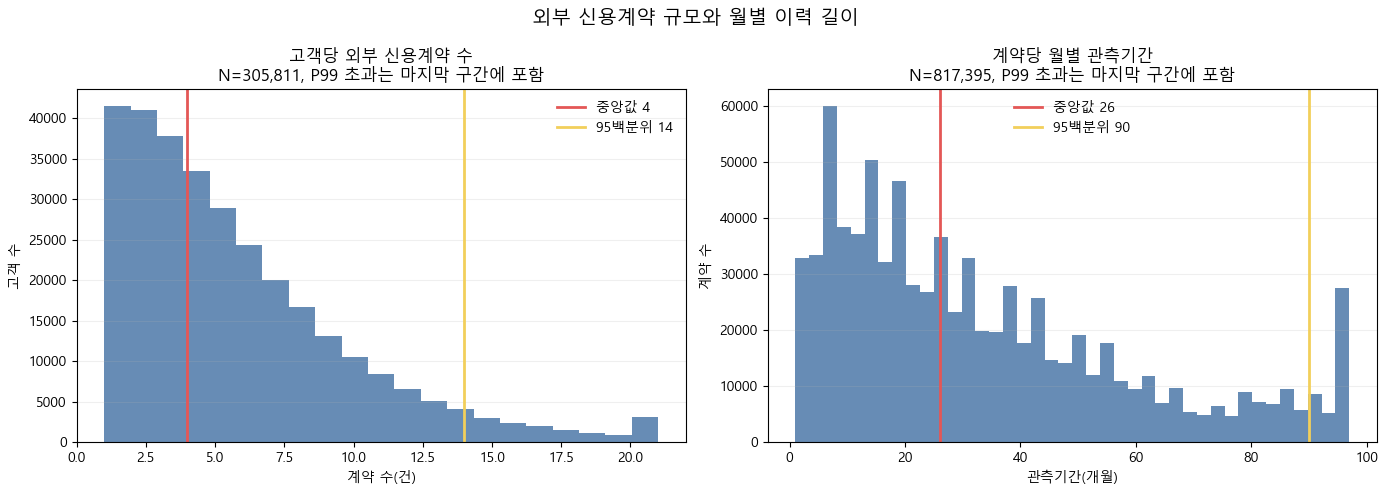

,METRIC,N,MISSING_COUNT,MEDIAN,P95,P99,MAX,ABOVE_P99_COUNT
0,고객당 외부 신용계약 수,305811,0,4.0000,14.0000,21.0000,116.0000,2397
1,계약당 월별 관측기간,817395,0,26.0000,90.0000,97.0000,97.0000,0


In [37]:
import matplotlib.pyplot as plt


plt.rcParams.update(
    {
        "font.family": ["Malgun Gothic", "DejaVu Sans"],
        "axes.unicode_minus": False,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "figure.titlesize": 14,
    }
)
COLORS = {
    "main": "#4C78A8",
    "secondary": "#72B7B2",
    "risk": "#E45756",
    "neutral": "#9D9D9D",
    "accent": "#F2CF5B",
}


def show_figure(fig: plt.Figure) -> None:
    """그래프를 외부 파일로 저장하지 않고 현재 노트북 셀에만 표시한다."""
    plt.show()
    plt.close(fig)


def label_vertical_bars(ax: plt.Axes, values, log_scale: bool = False) -> None:
    """작은 범주도 확인할 수 있도록 막대 위에 실제 건수를 표시한다."""
    for patch, value in zip(ax.patches, values):
        y = value * 1.12 if log_scale else value + max(values) * 0.012
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            y,
            f"{int(value):,}",
            ha="center",
            va="bottom",
            fontsize=8,
        )


def label_horizontal_bars(ax: plt.Axes, values) -> None:
    for patch, value in zip(ax.patches, values):
        ax.text(
            value + max(values) * 0.01,
            patch.get_y() + patch.get_height() / 2,
            f"{int(value):,}",
            ha="left",
            va="center",
            fontsize=8,
        )
    ax.set_xlim(0, max(values) * 1.18)


# 6.1 고객당 계약 수와 계약당 관측기간
volume_metrics = [
    ("고객당 외부 신용계약 수", customer_feature_table["BUR_CREDIT_COUNT"]),
    ("계약당 월별 관측기간", bb_contract_features["BB_OBS_MONTH_COUNT"]),
]
volume_distribution_summary = pd.DataFrame(
    [
        {
            "METRIC": name,
            "N": int(values.notna().sum()),
            "MISSING_COUNT": int(values.isna().sum()),
            "MEDIAN": float(values.median()),
            "P95": float(values.quantile(0.95)),
            "P99": float(values.quantile(0.99)),
            "MAX": float(values.max()),
            "ABOVE_P99_COUNT": int((values > values.quantile(0.99)).sum()),
        }
        for name, values in volume_metrics
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, values), x_label in zip(
    axes,
    volume_metrics,
    ["계약 수(건)", "관측기간(개월)"],
):
    p99 = float(values.quantile(0.99))
    clipped = values.clip(upper=p99)
    bins = min(40, max(10, int(clipped.nunique())))
    ax.hist(clipped, bins=bins, color=COLORS["main"], alpha=0.85)
    ax.axvline(
        values.median(),
        color=COLORS["risk"],
        linewidth=2,
        label=f"중앙값 {values.median():,.0f}",
    )
    ax.axvline(
        values.quantile(0.95),
        color=COLORS["accent"],
        linewidth=2,
        label=f"95백분위 {values.quantile(0.95):,.0f}",
    )
    ax.set_title(f"{name}\nN={values.notna().sum():,}, P99 초과는 마지막 구간에 포함")
    ax.set_xlabel(x_label)
    ax.set_ylabel("고객 수" if "고객당" in name else "계약 수")
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("외부 신용계약 규모와 월별 이력 길이")
fig.tight_layout()
show_figure(fig)


display(volume_distribution_summary)

#### 실행 결과 해석 — 계약 수와 관측기간 분포

- `bureau` 이력이 있는 고객 305,811명의 외부 신용계약 수는 중앙값 4건, 95백분위 14건, 99백분위 21건, 최대 116건이다. 21건을 초과하는 고객은 2,397명(0.78%)이며, 그래프에서는 이들을 마지막 구간에 포함했지만 원값은 삭제하거나 상한 처리하지 않았다.
- 월별 이력이 있는 817,395개 계약의 관측기간은 중앙값 26개월, 95백분위 90개월, 최대 97개월이다. 99백분위와 최댓값이 모두 97개월이므로 데이터가 제공하는 월별 이력 상한이 97개월일 가능성이 있으며, 긴 이력 자체를 이상치로 제거할 근거는 없다.
- 고객당 계약 수와 계약당 관측기간 모두 오른쪽 꼬리가 길다. 이후 고객 분석은 월별 행 수가 많은 고객이 과도하게 가중되지 않도록 이미 만든 고객 단위 특성을 사용해야 한다.

### 6.2 계약 구성과 최신 상태

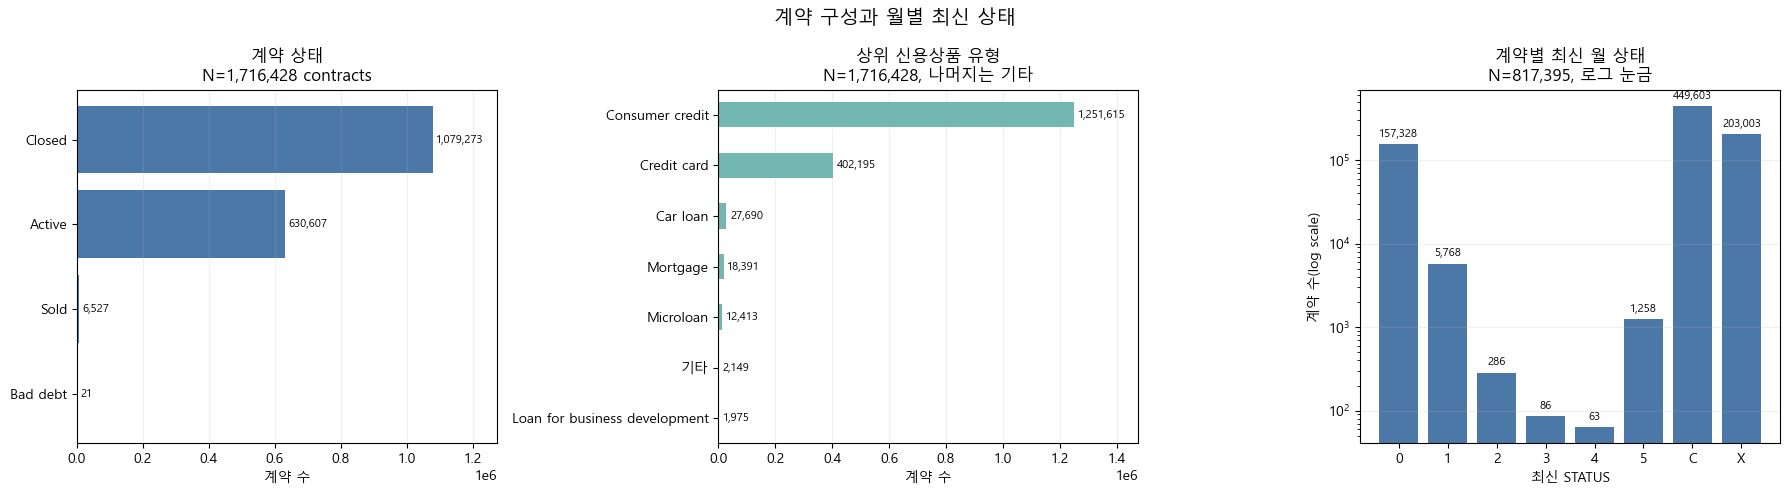

,CATEGORY,COUNT,RATE
0,Closed,1079273,0.6288
1,Active,630607,0.3674
2,Sold,6527,0.0038
3,Bad debt,21,0.0000


,CREDIT_TYPE,CONTRACT_COUNT,CONTRACT_RATE
0,Consumer credit,1251615,0.7292
1,Credit card,402195,0.2343
2,Car loan,27690,0.0161
3,Mortgage,18391,0.0107
4,Microloan,12413,0.0072
5,Loan for business development,1975,0.0012
6,Another type of loan,1017,0.0006


,LATEST_STATUS,CONTRACT_COUNT,CONTRACT_RATE
0,0,157328,0.1925
1,1,5768,0.0071
2,2,286,0.0003
3,3,86,0.0001
4,4,63,0.0001
5,5,1258,0.0015
6,C,449603,0.5500
7,X,203003,0.2484


In [38]:
# 6.2 계약 상태·신용유형·최신 월별 상태
active_summary = (
    bureau["CREDIT_ACTIVE"]
    .value_counts(dropna=False)
    .rename_axis("CATEGORY")
    .reset_index(name="COUNT")
)
active_summary["RATE"] = active_summary["COUNT"] / len(bureau)

credit_type_counts = bureau["CREDIT_TYPE"].value_counts(dropna=False)
top_credit_types = credit_type_counts.head(6)
other_credit_types = int(credit_type_counts.iloc[6:].sum())
credit_type_plot = pd.concat(
    [top_credit_types, pd.Series({"기타": other_credit_types})]
)

latest_status_plot = (
    bb_contract_features["BB_LATEST_STATUS"]
    .astype("string")
    .value_counts()
    .reindex(["0", "1", "2", "3", "4", "5", "C", "X"], fill_value=0)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
active_plot = active_summary.sort_values("COUNT")
axes[0].barh(active_plot["CATEGORY"].astype(str), active_plot["COUNT"], color=COLORS["main"])
label_horizontal_bars(axes[0], active_plot["COUNT"].to_numpy())
axes[0].set_title(f"계약 상태\nN={len(bureau):,} contracts")
axes[0].set_xlabel("계약 수")
axes[0].grid(axis="x", alpha=0.2)

credit_type_plot.sort_values().plot.barh(ax=axes[1], color=COLORS["secondary"])
label_horizontal_bars(axes[1], credit_type_plot.sort_values().to_numpy())
axes[1].set_title(f"상위 신용상품 유형\nN={len(bureau):,}, 나머지는 기타")
axes[1].set_xlabel("계약 수")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.2)

axes[2].bar(latest_status_plot.index, latest_status_plot.values, color=COLORS["main"])
axes[2].set_yscale("log")
label_vertical_bars(axes[2], latest_status_plot.values, log_scale=True)
axes[2].set_title(
    f"계약별 최신 월 상태\nN={len(bb_contract_features):,}, 로그 눈금"
)
axes[2].set_xlabel("최신 STATUS")
axes[2].set_ylabel("계약 수(log scale)")
axes[2].grid(axis="y", alpha=0.2)
fig.suptitle("계약 구성과 월별 최신 상태")
fig.tight_layout()
show_figure(fig)

contract_category_summary = pd.DataFrame(
    [
        {
            "METRIC": "Active contract rate",
            "NUMERATOR": int(bureau["CREDIT_ACTIVE"].eq("Active").sum()),
            "DENOMINATOR": len(bureau),
        },
        {
            "METRIC": "Closed contract rate",
            "NUMERATOR": int(bureau["CREDIT_ACTIVE"].eq("Closed").sum()),
            "DENOMINATOR": len(bureau),
        },
        {
            "METRIC": "Latest numeric delinquency STATUS 1-5",
            "NUMERATOR": int(
                bb_contract_features["BB_LATEST_STATUS"]
                .astype("string")
                .isin(["1", "2", "3", "4", "5"])
                .sum()
            ),
            "DENOMINATOR": len(bb_contract_features),
        },
    ]
)
contract_category_summary["RATE"] = (
    contract_category_summary["NUMERATOR"]
    / contract_category_summary["DENOMINATOR"]
)
credit_type_summary = (
    bureau["CREDIT_TYPE"]
    .value_counts(dropna=False)
    .rename_axis("CREDIT_TYPE")
    .reset_index(name="CONTRACT_COUNT")
)
credit_type_summary["CONTRACT_RATE"] = (
    credit_type_summary["CONTRACT_COUNT"] / len(bureau)
)
latest_status_summary_viz = (
    latest_status_plot.rename("CONTRACT_COUNT")
    .rename_axis("LATEST_STATUS")
    .reset_index()
)
latest_status_summary_viz["CONTRACT_RATE"] = (
    latest_status_summary_viz["CONTRACT_COUNT"] / len(bb_contract_features)
)



display(active_summary)
display(credit_type_summary.head(7))
display(latest_status_summary_viz)

#### 실행 결과 해석 — 계약 상태·상품·최신 월 상태

- 전체 1,716,428개 계약 중 `Closed`는 1,079,273건(62.88%), `Active`는 630,607건(36.74%)이다. `Sold` 6,527건과 `Bad debt` 21건은 선형축에서 작게 보이므로 막대 옆 실제 건수를 함께 표시했다.
- Consumer credit 72.92%와 Credit card 23.43%가 전체 계약의 96.35%를 차지한다. 상품유형별 분석에서는 나머지 소수 유형의 높은 비율이나 극단값을 큰 패턴으로 과대해석하지 않아야 한다.
- 월별 이력이 있는 계약의 최신 상태는 `C` 449,603건(55.00%), `X` 203,003건(24.84%), `0` 157,328건(19.25%)이다. 최신 상태가 숫자 연체 `1`~`5`인 계약은 7,461건(0.91%)이다.
- 최신 시점의 연체 비중이 낮다고 해서 과거 연체가 없었다는 의미는 아니다. 최신 상태 그래프와 5절의 전체기간 연체·최대 상태 특성을 분리해 해석한다.

### 6.3 총신용과 총부채 관계

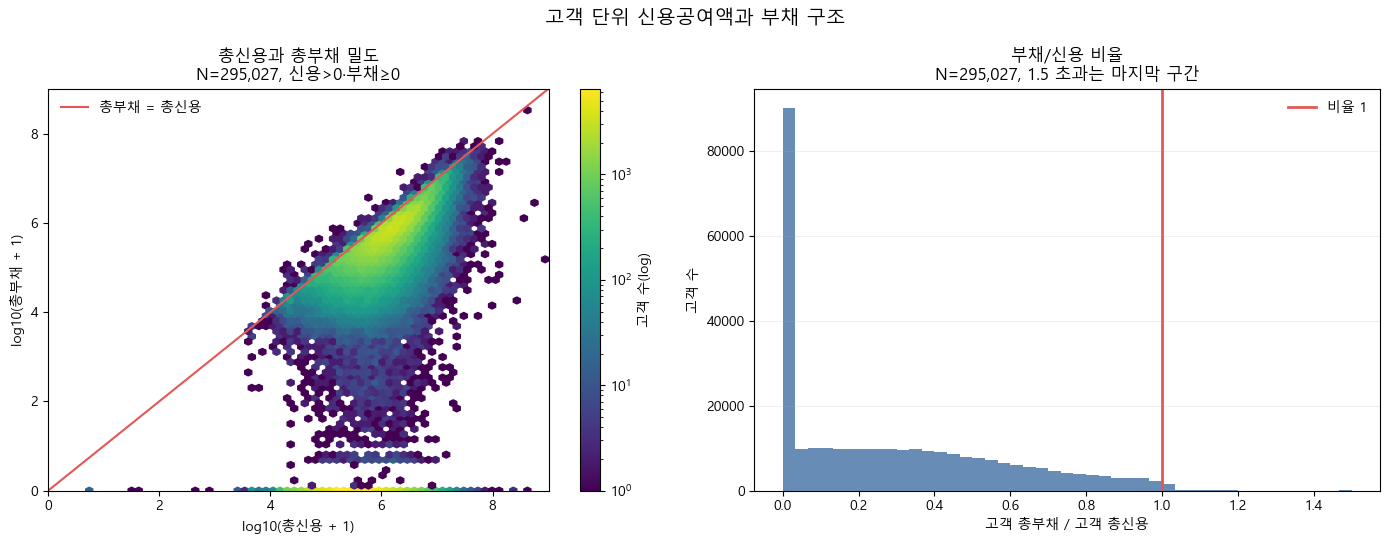

,METRIC,COUNT,DENOMINATOR,RATE
0,scatter eligible: credit > 0 and debt >= 0,295027,305811,0.9647
1,invalid/nonpositive total credit denominator,1276,305811,0.0042
2,negative debt/credit ratio,1265,305811,0.0041
3,debt/credit ratio > 1,1755,305811,0.0057
4,total debt = 0,80654,297439,0.2712


In [39]:
# 6.3 총신용과 총부채 관계
credit = customer_feature_table["BUR_TOTAL_CREDIT"]
debt = customer_feature_table["BUR_TOTAL_DEBT"]
amount_valid = credit.gt(0) & debt.ge(0) & credit.notna() & debt.notna()
log_credit = np.log10(credit.loc[amount_valid] + 1)
log_debt = np.log10(debt.loc[amount_valid] + 1)

ratio = customer_feature_table["BUR_DEBT_CREDIT_RATIO"]
ratio_nonnegative = ratio.loc[ratio.notna() & ratio.ge(0)]
ratio_plot_cap = 1.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
hexbin = axes[0].hexbin(
    log_credit,
    log_debt,
    gridsize=65,
    mincnt=1,
    bins="log",
    cmap="viridis",
)
axis_min = min(float(log_credit.min()), float(log_debt.min()))
axis_max = max(float(log_credit.max()), float(log_debt.max()))
axes[0].plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    color=COLORS["risk"],
    linewidth=1.5,
    label="총부채 = 총신용",
)
axes[0].set_xlim(axis_min, axis_max)
axes[0].set_ylim(axis_min, axis_max)
axes[0].set_title(
    f"총신용과 총부채 밀도\nN={amount_valid.sum():,}, 신용>0·부채≥0"
)
axes[0].set_xlabel("log10(총신용 + 1)")
axes[0].set_ylabel("log10(총부채 + 1)")
axes[0].legend(frameon=False)
fig.colorbar(hexbin, ax=axes[0], label="고객 수(log)")

axes[1].hist(
    ratio_nonnegative.clip(upper=ratio_plot_cap),
    bins=45,
    color=COLORS["main"],
    alpha=0.85,
)
axes[1].axvline(1, color=COLORS["risk"], linewidth=2, label="비율 1")
axes[1].set_title(
    f"부채/신용 비율\nN={len(ratio_nonnegative):,}, 1.5 초과는 마지막 구간"
)
axes[1].set_xlabel("고객 총부채 / 고객 총신용")
axes[1].set_ylabel("고객 수")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.2)
fig.suptitle("고객 단위 신용공여액과 부채 구조")
fig.tight_layout()
show_figure(fig)

amount_relationship_summary = pd.DataFrame(
    [
        {
            "METRIC": "scatter eligible: credit > 0 and debt >= 0",
            "COUNT": int(amount_valid.sum()),
            "DENOMINATOR": len(customer_feature_table),
        },
        {
            "METRIC": "invalid/nonpositive total credit denominator",
            "COUNT": int(customer_feature_table["INVALID_DENOM_BUR_TOTAL_CREDIT"].sum()),
            "DENOMINATOR": len(customer_feature_table),
        },
        {
            "METRIC": "negative debt/credit ratio",
            "COUNT": int(customer_feature_table["BUR_DEBT_CREDIT_RATIO_LT_0"].sum()),
            "DENOMINATOR": len(customer_feature_table),
        },
        {
            "METRIC": "debt/credit ratio > 1",
            "COUNT": int(customer_feature_table["BUR_DEBT_CREDIT_RATIO_GT_1"].sum()),
            "DENOMINATOR": len(customer_feature_table),
        },
        {
            "METRIC": "total debt = 0",
            "COUNT": int(debt.eq(0).sum()),
            "DENOMINATOR": int(debt.notna().sum()),
        },
    ]
)
amount_relationship_summary["RATE"] = (
    amount_relationship_summary["COUNT"]
    / amount_relationship_summary["DENOMINATOR"]
)


# 6.4 월별 이력 커버리지와 최근 연체
display(amount_relationship_summary)

#### 실행 결과 해석 — 총신용과 총부채

- 산점도는 총신용이 양수이고 총부채가 0 이상인 295,027명(전체 `bureau` 고객의 96.47%)을 사용했다. 금액 원값을 제거하지 않고 `log10(금액+1)` 좌표와 hexbin 고객 밀도로 표시했다.
- 유효한 총부채 값이 있는 297,439명 중 총부채가 0인 고객은 80,654명(27.12%)이다. 따라서 0 부근의 높은 밀도는 오류로 간주할 수 없으며, 부채 보유 여부와 양수 부채 규모를 분리하는 것이 적절하다.
- 대부분의 고객은 `총부채 = 총신용` 기준선 아래에 위치하지만 부채/신용 비율이 1을 초과하는 고객도 1,755명(0.57%) 존재한다. 음수 비율 1,265명(0.41%)은 그래프에서 제외하되 5절의 품질 플래그로 유지했다.
- 이 그림은 두 금액의 관측 관계를 보여줄 뿐 채무부담의 인과효과나 상환곤란을 의미하지 않는다. `TARGET`과의 관계는 7절에서 동일한 분모 규칙으로 별도 확인한다.

### 6.4 월별 이력 커버리지와 최근 연체

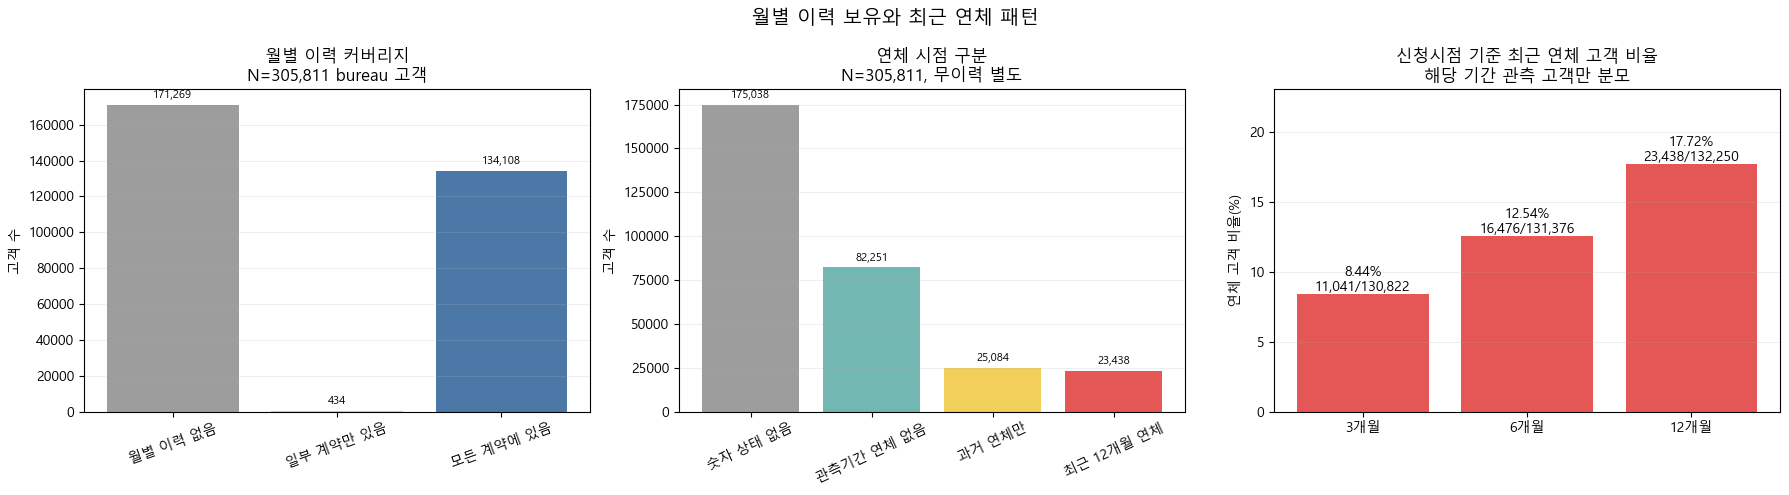

,GROUP,COUNT,SECTION,RATE
0,월별 이력 없음,171269,BB coverage,0.5600
1,일부 계약만 있음,434,BB coverage,0.0014
2,모든 계약에 있음,134108,BB coverage,0.4385
3,숫자 상태 없음,175038,Delinquency timing,0.5724
4,관측기간 연체 없음,82251,Delinquency timing,0.2690
5,과거 연체만,25084,Delinquency timing,0.0820
6,최근 12개월 연체,23438,Delinquency timing,0.0766


,WINDOW,DELINQUENT_CUSTOMERS,OBSERVED_CUSTOMERS,DELINQUENT_RATE
0,3개월,11041,130822,0.0844
1,6개월,16476,131376,0.1254
2,12개월,23438,132250,0.1772


In [40]:
coverage_ratio = customer_feature_table["BB_COVERED_CREDIT_RATIO"]
coverage_group = pd.Series(
    np.select(
        [
            coverage_ratio.eq(0),
            coverage_ratio.gt(0) & coverage_ratio.lt(1),
            coverage_ratio.eq(1),
        ],
        ["월별 이력 없음", "일부 계약만 있음", "모든 계약에 있음"],
        default="분류 불가",
    ),
    index=customer_feature_table.index,
)
coverage_plot = coverage_group.value_counts().reindex(
    ["월별 이력 없음", "일부 계약만 있음", "모든 계약에 있음"],
    fill_value=0,
)

has_numeric_status = customer_feature_table[
    "BB_CUSTOMER_VALID_STATUS_MONTH_COUNT"
].fillna(0).gt(0)
ever_delinquent = customer_feature_table[
    "BB_CUSTOMER_DELINQUENT_MONTH_COUNT"
].fillna(0).gt(0)
recent_12m_delinquent = customer_feature_table[
    "BB_CUSTOMER_DELINQUENT_COUNT_12M"
].fillna(0).gt(0)
delinquency_timing = pd.Series(
    np.select(
        [
            ~has_numeric_status,
            has_numeric_status & ~ever_delinquent,
            ever_delinquent & ~recent_12m_delinquent,
            recent_12m_delinquent,
        ],
        [
            "숫자 상태 없음",
            "관측기간 연체 없음",
            "과거 연체만",
            "최근 12개월 연체",
        ],
        default="분류 불가",
    ),
    index=customer_feature_table.index,
)
timing_plot = delinquency_timing.value_counts().reindex(
    ["숫자 상태 없음", "관측기간 연체 없음", "과거 연체만", "최근 12개월 연체"],
    fill_value=0,
)

recent_rows = []
for window in [3, 6, 12]:
    observed = customer_feature_table[f"BB_CUSTOMER_RECENT_OBS_COUNT_{window}M"].fillna(0).gt(0)
    delinquent = customer_feature_table[
        f"BB_CUSTOMER_DELINQUENT_COUNT_{window}M"
    ].fillna(0).gt(0)
    recent_rows.append(
        {
            "WINDOW": f"{window}개월",
            "DELINQUENT_CUSTOMERS": int((observed & delinquent).sum()),
            "OBSERVED_CUSTOMERS": int(observed.sum()),
            "DELINQUENT_RATE": float((observed & delinquent).sum() / observed.sum()),
        }
    )
recent_delinquency_summary = pd.DataFrame(recent_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(
    coverage_plot.index,
    coverage_plot.values,
    color=[COLORS["neutral"], COLORS["accent"], COLORS["main"]],
)
label_vertical_bars(axes[0], coverage_plot.to_numpy())
axes[0].set_title(f"월별 이력 커버리지\nN={len(customer_feature_table):,} bureau 고객")
axes[0].set_ylabel("고객 수")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.2)

axes[1].bar(
    timing_plot.index,
    timing_plot.values,
    color=[COLORS["neutral"], COLORS["secondary"], COLORS["accent"], COLORS["risk"]],
)
label_vertical_bars(axes[1], timing_plot.to_numpy())
axes[1].set_title(f"연체 시점 구분\nN={len(customer_feature_table):,}, 무이력 별도")
axes[1].set_ylabel("고객 수")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.2)

axes[2].bar(
    recent_delinquency_summary["WINDOW"],
    recent_delinquency_summary["DELINQUENT_RATE"] * 100,
    color=COLORS["risk"],
)
for index, row in recent_delinquency_summary.iterrows():
    axes[2].text(
        index,
        row["DELINQUENT_RATE"] * 100,
        (
            f"{row['DELINQUENT_RATE'] * 100:.2f}%\n"
            f"{row['DELINQUENT_CUSTOMERS']:,}/{row['OBSERVED_CUSTOMERS']:,}"
        ),
        ha="center",
        va="bottom",
    )
axes[2].set_title("신청시점 기준 최근 연체 고객 비율\n해당 기간 관측 고객만 분모")
axes[2].set_ylabel("연체 고객 비율(%)")
axes[2].set_ylim(
    0,
    float(recent_delinquency_summary["DELINQUENT_RATE"].max() * 100 * 1.3),
)
axes[2].grid(axis="y", alpha=0.2)
fig.suptitle("월별 이력 보유와 최근 연체 패턴")
fig.tight_layout()
show_figure(fig)

coverage_timing_summary = pd.concat(
    [
        coverage_plot.rename_axis("GROUP").reset_index(name="COUNT").assign(
            SECTION="BB coverage"
        ),
        timing_plot.rename_axis("GROUP").reset_index(name="COUNT").assign(
            SECTION="Delinquency timing"
        ),
    ],
    ignore_index=True,
)
coverage_timing_summary["RATE"] = (
    coverage_timing_summary["COUNT"] / len(customer_feature_table)
)


display(coverage_timing_summary)
display(recent_delinquency_summary)

#### 실행 결과 해석 — 이력 보유와 최근 연체

- `bureau` 고객 305,811명 중 월별 이력이 전혀 없는 고객은 171,269명(56.00%), 모든 계약에 월별 이력이 있는 고객은 134,108명(43.85%), 일부 계약만 있는 고객은 434명(0.14%)이다. 7절에서는 Application 고객까지 포함해 ‘외부 신용이력 없음’ 집단을 별도로 추가해야 한다.
- 유효한 숫자 상태가 없는 고객은 175,038명(57.24%)이다. 숫자 상태가 있는 고객 중 관측기간 연체 없음은 82,251명, 과거 연체만 있음은 25,084명, 최근 12개월 연체 있음은 23,438명이다. `C`·`X`만 있는 고객을 정상 0으로 합치지 않았기 때문에 월별 이력 없음과 숫자 상태 없음의 수가 다르다.
- 신청시점 기준 최근 구간에 관측이 있는 고객만 분모로 했을 때 연체 고객 비율은 3개월 8.44%(11,041/130,822), 6개월 12.54%(16,476/131,376), 12개월 17.72%(23,438/132,250)다.
- 3·6·12개월 창은 서로 포함되는 누적 구간이므로 기간이 길수록 비율이 커지는 것은 자연스럽다. 이 차이를 최근 악화 추세로 해석하지 않고, 악화 판단에는 5절의 최근 3개월 대 이전기간 비교 플래그를 사용한다.

## 7. Application 통합 및 TARGET 설명 분석

이 프로젝트의 목적은 종료된 Kaggle 대회에 제출하는 것이 아니라, 부실위험을 설명하고 조건 조정 가능성을 탐색하는 대출 심사 보조 방법론을 만드는 것이다. 따라서 Kaggle train/test를 모델 제출용 분할로 비교하지 않는다.

`application_train`과 `application_test`는 `DATASET_SOURCE`를 남긴 채 전체 Application 고객표로 통합한다. 다만 `TARGET`은 train에만 존재하므로 전체 고객 커버리지는 356,255명으로 분석하고, 상환곤란과의 관측 관계는 라벨이 있는 307,511명으로만 분석한다. 향후 모델 검증도 Kaggle test가 아니라 라벨 고객 내부 교차검증을 사용한다.

`TARGET=1`은 대출 실행 후 상환곤란을 의미하며 승인 거절 라벨이 아니다. 아래 결과는 승인정책이나 인과효과가 아니라 외부 신용이력과 상환곤란의 관측 관계로 제한해 해석한다.

### 7.1 Application 전체 통합과 이력 커버리지

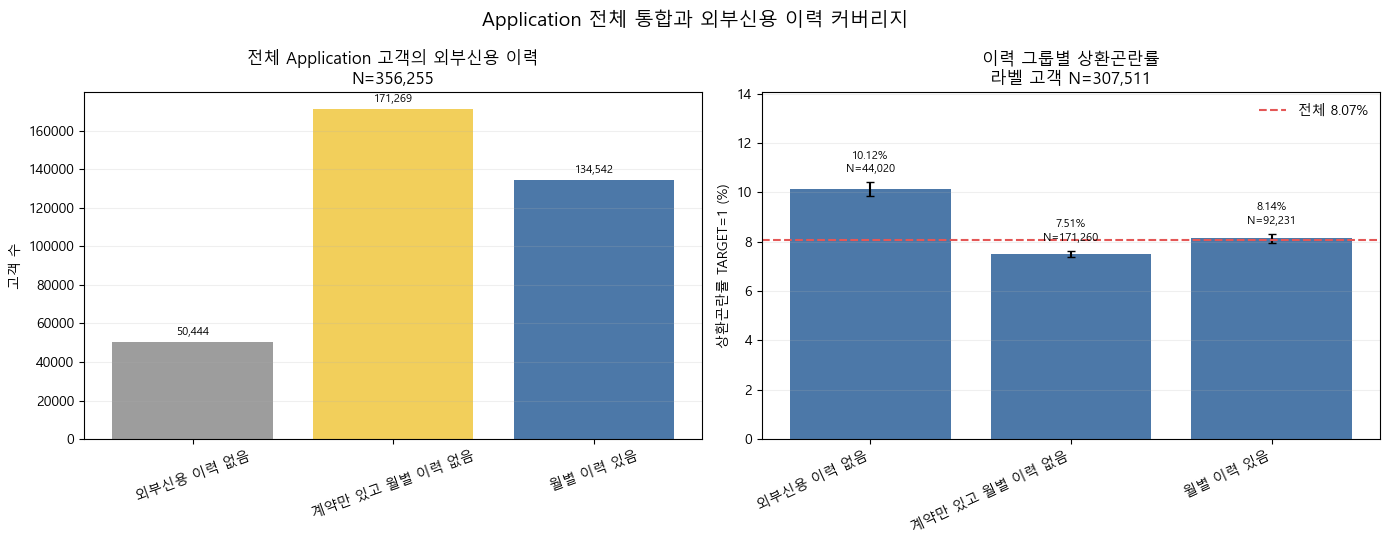

,METRIC,COUNT
0,labeled application rows,307511
1,unlabeled application rows,48744
2,combined application rows,356255
3,combined duplicate SK_ID_CURR,0
4,bureau customers outside combined application,0


,HISTORY_GROUP,CUSTOMER_COUNT,CUSTOMER_RATE
0,외부신용 이력 없음,50444,0.1416
1,계약만 있고 월별 이력 없음,171269,0.4807
2,월별 이력 있음,134542,0.3777


,HISTORY_GROUP,CUSTOMER_COUNT,TARGET_1_COUNT,TARGET_RATE,WILSON_LOW,WILSON_HIGH
0,외부신용 이력 없음,44020,4457,0.1012,0.0985,0.1041
1,계약만 있고 월별 이력 없음,171260,12858,0.0751,0.0738,0.0763
2,월별 이력 있음,92231,7510,0.0814,0.0797,0.0832


In [41]:
def wilson_interval(events: pd.Series, totals: pd.Series, z: float = 1.96):
    events = events.astype(float)
    totals = totals.astype(float)
    rate = events / totals
    denominator = 1 + z**2 / totals
    center = (rate + z**2 / (2 * totals)) / denominator
    half_width = (
        z
        * np.sqrt(rate * (1 - rate) / totals + z**2 / (4 * totals**2))
        / denominator
    )
    return center - half_width, center + half_width


def target_rate_table(data: pd.DataFrame, group_column: str, order: list[str]):
    summary = (
        data.groupby(group_column, observed=True)
        .agg(
            CUSTOMER_COUNT=("TARGET", "size"),
            TARGET_1_COUNT=("TARGET", "sum"),
            TARGET_RATE=("TARGET", "mean"),
        )
        .reindex(order)
        .dropna(subset=["CUSTOMER_COUNT"])
        .reset_index()
    )
    summary["TARGET_1_COUNT"] = summary["TARGET_1_COUNT"].astype(int)
    summary["CUSTOMER_COUNT"] = summary["CUSTOMER_COUNT"].astype(int)
    lower, upper = wilson_interval(
        summary["TARGET_1_COUNT"],
        summary["CUSTOMER_COUNT"],
    )
    summary["WILSON_LOW"] = lower
    summary["WILSON_HIGH"] = upper
    return summary


def plot_target_rates(
    ax: plt.Axes,
    summary: pd.DataFrame,
    group_column: str,
    title: str,
    overall_rate: float,
) -> None:
    rates = summary["TARGET_RATE"].to_numpy() * 100
    lower_error = (summary["TARGET_RATE"] - summary["WILSON_LOW"]).to_numpy() * 100
    upper_error = (summary["WILSON_HIGH"] - summary["TARGET_RATE"]).to_numpy() * 100
    x = np.arange(len(summary))
    ax.bar(
        x,
        rates,
        color=COLORS["main"],
        yerr=np.vstack([lower_error, upper_error]),
        capsize=3,
    )
    ax.axhline(
        overall_rate * 100,
        color=COLORS["risk"],
        linestyle="--",
        linewidth=1.5,
        label=f"전체 {overall_rate * 100:.2f}%",
    )
    ax.set_xticks(x, summary[group_column].astype(str), rotation=25, ha="right")
    ax.set_ylabel("상환곤란률 TARGET=1 (%)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(frameon=False)
    ax.set_ylim(0, max(float((rates + upper_error).max() * 1.35), overall_rate * 130))
    for index, row in summary.iterrows():
        ax.text(
            index,
            row["WILSON_HIGH"] * 100 + ax.get_ylim()[1] * 0.02,
            f"{row['TARGET_RATE'] * 100:.2f}%\nN={row['CUSTOMER_COUNT']:,}",
            ha="center",
            va="bottom",
            fontsize=8,
        )


# 7.1 Kaggle 파일 구분은 보존하되 전체 Application 고객으로 통합한다.
application_train_link = pd.read_csv(
    DATA_DIR / "application_train.csv",
    encoding="utf-8-sig",
    usecols=["SK_ID_CURR", "TARGET"],
)
application_test_link = pd.read_csv(
    DATA_DIR / "application_test.csv",
    encoding="utf-8-sig",
    usecols=["SK_ID_CURR"],
)
application_train_link["DATASET_SOURCE"] = "labeled_train"
application_test_link["DATASET_SOURCE"] = "unlabeled_test"
application_test_link["TARGET"] = np.nan
application_all = pd.concat(
    [application_train_link, application_test_link],
    ignore_index=True,
)

assert application_train_link["SK_ID_CURR"].is_unique
assert application_test_link["SK_ID_CURR"].is_unique
assert application_all["SK_ID_CURR"].is_unique

application_customer = application_all.merge(
    customer_feature_table,
    on="SK_ID_CURR",
    how="left",
    validate="one_to_one",
)
application_customer["HAS_BUREAU"] = application_customer[
    "BUR_CREDIT_COUNT"
].notna()
application_customer["HAS_BUREAU_BALANCE"] = application_customer[
    "HAS_BUREAU_BALANCE"
].fillna(False).astype(bool)
application_customer["HISTORY_GROUP"] = np.select(
    [
        ~application_customer["HAS_BUREAU"],
        (
            application_customer["HAS_BUREAU"]
            & ~application_customer["HAS_BUREAU_BALANCE"]
        ),
        application_customer["HAS_BUREAU_BALANCE"],
    ],
    ["외부신용 이력 없음", "계약만 있고 월별 이력 없음", "월별 이력 있음"],
    default="분류 불가",
)

application_integration_audit = pd.DataFrame(
    [
        {
            "METRIC": "labeled application rows",
            "COUNT": len(application_train_link),
        },
        {
            "METRIC": "unlabeled application rows",
            "COUNT": len(application_test_link),
        },
        {
            "METRIC": "combined application rows",
            "COUNT": len(application_all),
        },
        {
            "METRIC": "combined duplicate SK_ID_CURR",
            "COUNT": int(application_all["SK_ID_CURR"].duplicated().sum()),
        },
        {
            "METRIC": "bureau customers outside combined application",
            "COUNT": int(
                (
                    ~customer_feature_table["SK_ID_CURR"].isin(
                        application_all["SK_ID_CURR"]
                    )
                ).sum()
            ),
        },
    ]
)

history_order = [
    "외부신용 이력 없음",
    "계약만 있고 월별 이력 없음",
    "월별 이력 있음",
]
history_coverage_summary = (
    application_customer["HISTORY_GROUP"]
    .value_counts()
    .reindex(history_order, fill_value=0)
    .rename_axis("HISTORY_GROUP")
    .reset_index(name="CUSTOMER_COUNT")
)
history_coverage_summary["CUSTOMER_RATE"] = (
    history_coverage_summary["CUSTOMER_COUNT"] / len(application_customer)
)

labeled_customer = application_customer.loc[
    application_customer["TARGET"].notna()
].copy()
labeled_customer["TARGET"] = labeled_customer["TARGET"].astype("int8")
overall_target_rate = float(labeled_customer["TARGET"].mean())

history_target_summary = target_rate_table(
    labeled_customer,
    "HISTORY_GROUP",
    history_order,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].bar(
    history_coverage_summary["HISTORY_GROUP"],
    history_coverage_summary["CUSTOMER_COUNT"],
    color=[COLORS["neutral"], COLORS["accent"], COLORS["main"]],
)
label_vertical_bars(axes[0], history_coverage_summary["CUSTOMER_COUNT"].to_numpy())
axes[0].set_title(f"전체 Application 고객의 외부신용 이력\nN={len(application_customer):,}")
axes[0].set_ylabel("고객 수")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.2)
plot_target_rates(
    axes[1],
    history_target_summary,
    "HISTORY_GROUP",
    f"이력 그룹별 상환곤란률\n라벨 고객 N={len(labeled_customer):,}",
    overall_target_rate,
)
fig.suptitle("Application 전체 통합과 외부신용 이력 커버리지")
fig.tight_layout()
show_figure(fig)



display(application_integration_audit)
display(history_coverage_summary)
display(history_target_summary)

#### 실행 결과 해석 — 전체 고객 통합과 라벨 범위

- 라벨이 있는 Application 고객은 307,511명, 라벨이 없는 기존 Kaggle test 고객은 48,744명으로 통합 후 전체 356,255명이다. `SK_ID_CURR` 중복은 0건이며, 5절에서 만든 bureau 고객 305,811명은 모두 통합 Application 고객에 포함된다.
- 전체 고객 중 외부신용 계약 자체가 없는 고객은 50,444명(14.16%), 계약은 있지만 월별 이력이 없는 고객은 171,269명(48.07%), 월별 이력이 있는 고객은 134,542명(37.77%)이다. 이 세 집단을 구분함으로써 무이력을 금액 0이나 정상 상태로 대체하지 않는다.
- 라벨 고객의 전체 상환곤란률은 8.07%다. 외부신용 이력이 없는 고객은 10.12%(4,457/44,020), 계약만 있고 월별 이력이 없는 고객은 7.51%, 월별 이력이 있는 고객은 8.14%다.
- ‘외부신용 이력 없음’의 높은 비율은 정보 부족 자체, 고객 구성 또는 다른 신청 특성과 연관될 수 있다. 이 결과만으로 외부신용 이력 생성이 위험을 낮춘다고 해석할 수 없다.

### 7.2 계약 규모·활성·부채 비율과 TARGET

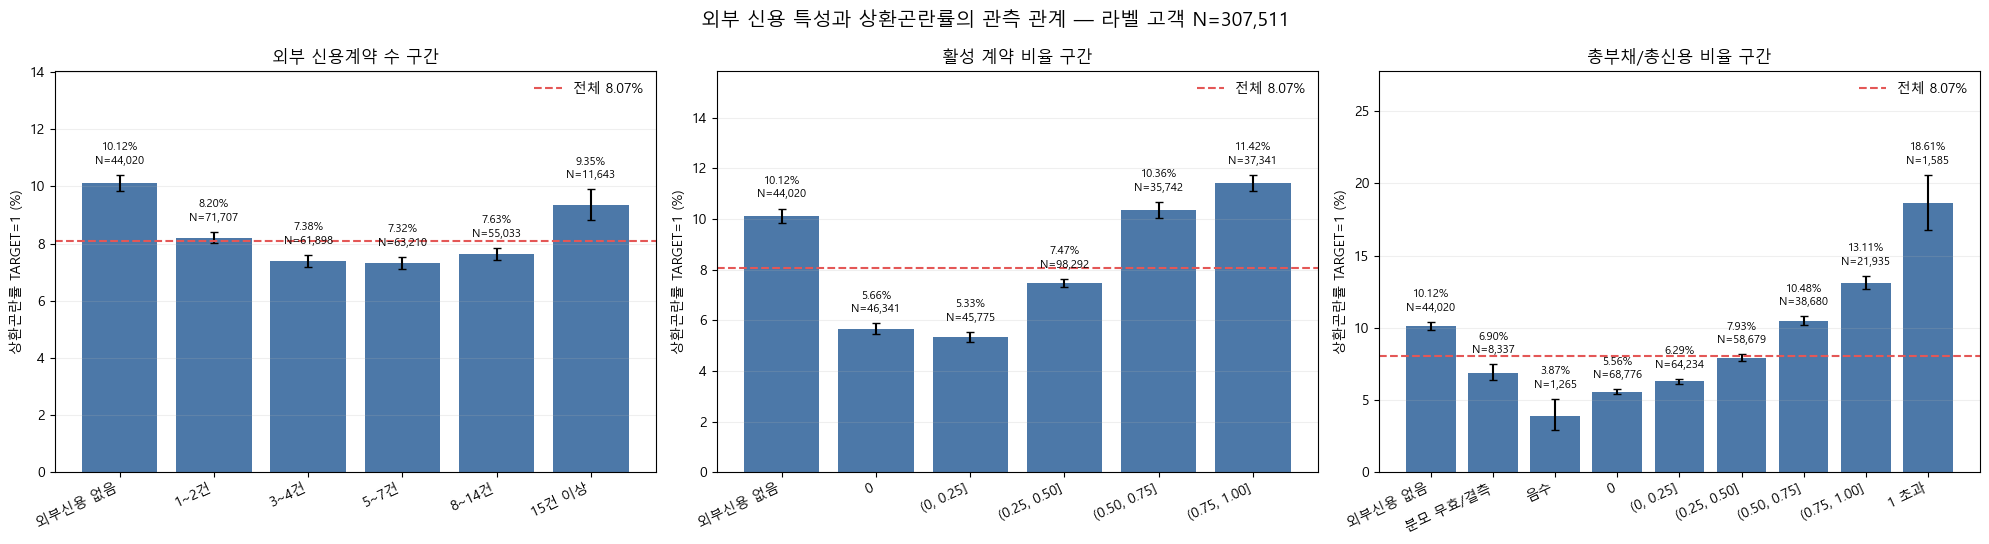

,CREDIT_COUNT_GROUP,CUSTOMER_COUNT,TARGET_1_COUNT,TARGET_RATE,WILSON_LOW,WILSON_HIGH
0,외부신용 없음,44020,4457,0.1012,0.0985,0.1041
1,1~2건,71707,5882,0.0820,0.0800,0.0841
2,3~4건,61898,4570,0.0738,0.0718,0.0759
3,5~7건,63210,4626,0.0732,0.0712,0.0752
4,8~14건,55033,4201,0.0763,0.0741,0.0786
5,15건 이상,11643,1089,0.0935,0.0884,0.0990


,ACTIVE_RATIO_GROUP,CUSTOMER_COUNT,TARGET_1_COUNT,TARGET_RATE,WILSON_LOW,WILSON_HIGH
0,외부신용 없음,44020,4457,0.1012,0.0985,0.1041
1,0,46341,2621,0.0566,0.0545,0.0587
2,"(0, 0.25]",45775,2442,0.0533,0.0513,0.0554
3,"(0.25, 0.50]",98292,7339,0.0747,0.0730,0.0763
4,"(0.50, 0.75]",35742,3702,0.1036,0.1005,0.1068
5,"(0.75, 1.00]",37341,4264,0.1142,0.1110,0.1175


,DEBT_RATIO_GROUP,CUSTOMER_COUNT,TARGET_1_COUNT,TARGET_RATE,WILSON_LOW,WILSON_HIGH
0,외부신용 없음,44020,4457,0.1012,0.0985,0.1041
1,분모 무효/결측,8337,575,0.0690,0.0637,0.0746
2,음수,1265,49,0.0387,0.0294,0.0508
3,0,68776,3824,0.0556,0.0539,0.0573
4,"(0, 0.25]",64234,4040,0.0629,0.0610,0.0648
5,"(0.25, 0.50]",58679,4656,0.0793,0.0772,0.0816
6,"(0.50, 0.75]",38680,4053,0.1048,0.1018,0.1079
7,"(0.75, 1.00]",21935,2876,0.1311,0.1267,0.1356
8,1 초과,1585,295,0.1861,0.1677,0.2060


In [42]:
# 7.2 계약 규모, 활성 비율, 부채/신용 비율과 TARGET의 관측 관계
credit_count_order = ["외부신용 없음", "1~2건", "3~4건", "5~7건", "8~14건", "15건 이상"]
labeled_customer["CREDIT_COUNT_GROUP"] = np.select(
    [
        ~labeled_customer["HAS_BUREAU"],
        labeled_customer["BUR_CREDIT_COUNT"].between(1, 2),
        labeled_customer["BUR_CREDIT_COUNT"].between(3, 4),
        labeled_customer["BUR_CREDIT_COUNT"].between(5, 7),
        labeled_customer["BUR_CREDIT_COUNT"].between(8, 14),
        labeled_customer["BUR_CREDIT_COUNT"].ge(15),
    ],
    credit_count_order,
    default="분류 불가",
)

active_ratio_order = [
    "외부신용 없음",
    "0",
    "(0, 0.25]",
    "(0.25, 0.50]",
    "(0.50, 0.75]",
    "(0.75, 1.00]",
]
labeled_customer["ACTIVE_RATIO_GROUP"] = np.select(
    [
        ~labeled_customer["HAS_BUREAU"],
        labeled_customer["BUR_ACTIVE_RATIO"].eq(0),
        labeled_customer["BUR_ACTIVE_RATIO"].gt(0)
        & labeled_customer["BUR_ACTIVE_RATIO"].le(0.25),
        labeled_customer["BUR_ACTIVE_RATIO"].gt(0.25)
        & labeled_customer["BUR_ACTIVE_RATIO"].le(0.50),
        labeled_customer["BUR_ACTIVE_RATIO"].gt(0.50)
        & labeled_customer["BUR_ACTIVE_RATIO"].le(0.75),
        labeled_customer["BUR_ACTIVE_RATIO"].gt(0.75)
        & labeled_customer["BUR_ACTIVE_RATIO"].le(1.00),
    ],
    active_ratio_order,
    default="분류 불가",
)

debt_ratio_order = [
    "외부신용 없음",
    "분모 무효/결측",
    "음수",
    "0",
    "(0, 0.25]",
    "(0.25, 0.50]",
    "(0.50, 0.75]",
    "(0.75, 1.00]",
    "1 초과",
]
labeled_customer["DEBT_RATIO_GROUP"] = np.select(
    [
        ~labeled_customer["HAS_BUREAU"],
        (
            labeled_customer["HAS_BUREAU"]
            & labeled_customer["BUR_DEBT_CREDIT_RATIO"].isna()
        ),
        labeled_customer["BUR_DEBT_CREDIT_RATIO"].lt(0),
        labeled_customer["BUR_DEBT_CREDIT_RATIO"].eq(0),
        labeled_customer["BUR_DEBT_CREDIT_RATIO"].gt(0)
        & labeled_customer["BUR_DEBT_CREDIT_RATIO"].le(0.25),
        labeled_customer["BUR_DEBT_CREDIT_RATIO"].gt(0.25)
        & labeled_customer["BUR_DEBT_CREDIT_RATIO"].le(0.50),
        labeled_customer["BUR_DEBT_CREDIT_RATIO"].gt(0.50)
        & labeled_customer["BUR_DEBT_CREDIT_RATIO"].le(0.75),
        labeled_customer["BUR_DEBT_CREDIT_RATIO"].gt(0.75)
        & labeled_customer["BUR_DEBT_CREDIT_RATIO"].le(1.00),
        labeled_customer["BUR_DEBT_CREDIT_RATIO"].gt(1),
    ],
    debt_ratio_order,
    default="분류 불가",
)

credit_count_target_summary = target_rate_table(
    labeled_customer,
    "CREDIT_COUNT_GROUP",
    credit_count_order,
)
active_ratio_target_summary = target_rate_table(
    labeled_customer,
    "ACTIVE_RATIO_GROUP",
    active_ratio_order,
)
debt_ratio_target_summary = target_rate_table(
    labeled_customer,
    "DEBT_RATIO_GROUP",
    debt_ratio_order,
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
plot_target_rates(
    axes[0],
    credit_count_target_summary,
    "CREDIT_COUNT_GROUP",
    "외부 신용계약 수 구간",
    overall_target_rate,
)
plot_target_rates(
    axes[1],
    active_ratio_target_summary,
    "ACTIVE_RATIO_GROUP",
    "활성 계약 비율 구간",
    overall_target_rate,
)
plot_target_rates(
    axes[2],
    debt_ratio_target_summary,
    "DEBT_RATIO_GROUP",
    "총부채/총신용 비율 구간",
    overall_target_rate,
)
fig.suptitle(
    f"외부 신용 특성과 상환곤란률의 관측 관계 — 라벨 고객 N={len(labeled_customer):,}"
)
fig.tight_layout()
show_figure(fig)



display(credit_count_target_summary)
display(active_ratio_target_summary)
display(debt_ratio_target_summary)

#### 실행 결과 해석 — 계약 규모·활성 비율·부채 비율

- 고객당 외부 신용계약 수와 상환곤란률은 단조 관계가 아니다. 3~4건과 5~7건 구간은 각각 7.38%, 7.32%로 낮지만 15건 이상은 9.35%로 다시 높아진다. 따라서 계약 수는 선형 변수 하나보다 구간 또는 비선형 효과로 다루는 편이 타당하다.
- 활성 계약 비율은 0~0.25 구간에서 5.33%지만 0.50~0.75 구간은 10.36%, 0.75~1.00 구간은 11.42%다. 현재 활성 계약의 비중이 높은 고객에서 상환곤란률이 높아지는 뚜렷한 관측 패턴이 나타난다.
- 총부채/총신용 비율은 0인 고객 5.56%, 0.50~0.75 구간 10.48%, 0.75~1.00 구간 13.11%, 1 초과 구간 18.61%로 증가한다. 1 초과 구간은 1,585명으로 표본이 상대적으로 작아 95% Wilson 구간도 넓지만 방향성은 명확하다.
- 음수 비율 집단의 3.87%는 유리한 고객 특성으로 해석하지 않는다. 5절에서 확인한 음수 부채·갱신시점 문제와 연결된 품질 집단이므로 별도 플래그로 유지한다.
- 이 결과는 향후 부실위험 설명과 조건 조정 후보를 정하는 근거지만, 대출금액을 줄이면 위험이 같은 폭으로 낮아진다는 인과효과를 입증하지는 않는다.

### 7.3 월별 연체 이력과 TARGET

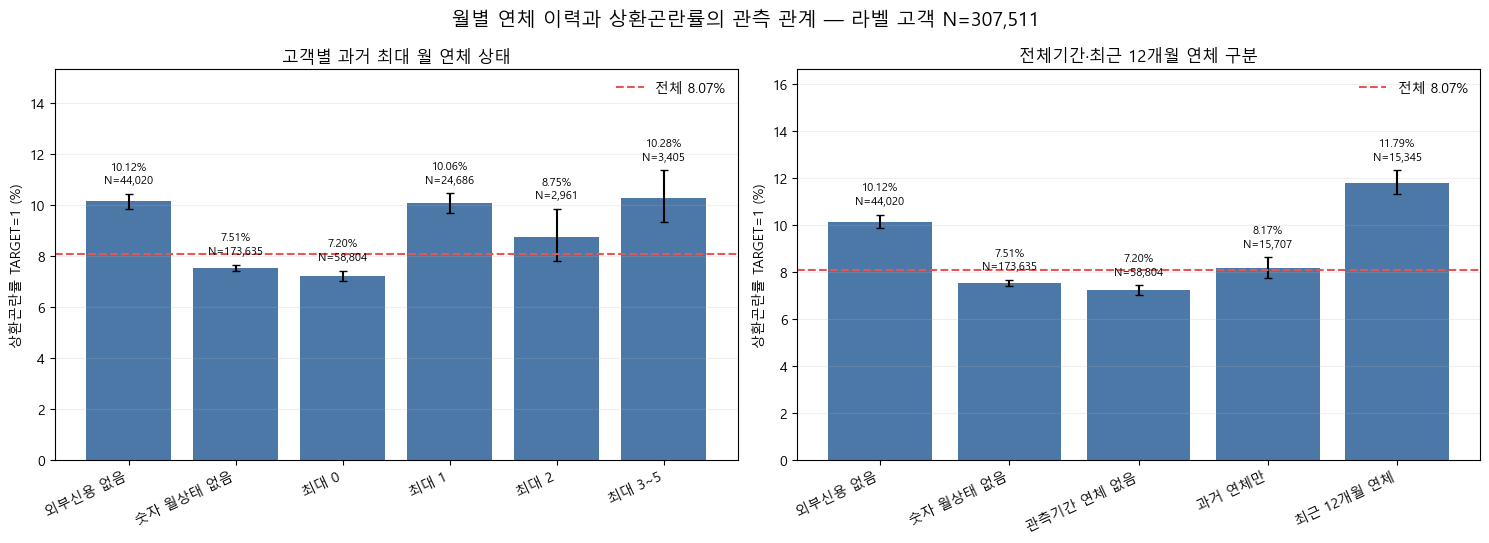

,MAX_STATUS_GROUP,CUSTOMER_COUNT,TARGET_1_COUNT,TARGET_RATE,WILSON_LOW,WILSON_HIGH
0,외부신용 없음,44020,4457,0.1012,0.0985,0.1041
1,숫자 월상태 없음,173635,13042,0.0751,0.0739,0.0764
2,최대 0,58804,4234,0.0720,0.0699,0.0741
3,최대 1,24686,2483,0.1006,0.0969,0.1044
4,최대 2,2961,259,0.0875,0.0778,0.0982
5,최대 3~5,3405,350,0.1028,0.0930,0.1134


,DELINQUENCY_TIMING_GROUP,CUSTOMER_COUNT,TARGET_1_COUNT,TARGET_RATE,WILSON_LOW,WILSON_HIGH
0,외부신용 없음,44020,4457,0.1012,0.0985,0.1041
1,숫자 월상태 없음,173635,13042,0.0751,0.0739,0.0764
2,관측기간 연체 없음,58804,4234,0.0720,0.0699,0.0741
3,과거 연체만,15707,1283,0.0817,0.0775,0.0861
4,최근 12개월 연체,15345,1809,0.1179,0.1129,0.1231


In [43]:
# 7.3 월별 연체 심도·시점과 TARGET의 관측 관계
max_status_order = [
    "외부신용 없음",
    "숫자 월상태 없음",
    "최대 0",
    "최대 1",
    "최대 2",
    "최대 3~5",
]
max_status_value = labeled_customer["BB_CUSTOMER_MAX_STATUS"].astype("float64")
labeled_customer["MAX_STATUS_GROUP"] = np.select(
    [
        ~labeled_customer["HAS_BUREAU"],
        (
            labeled_customer["HAS_BUREAU"]
            & labeled_customer["BB_CUSTOMER_MAX_STATUS"].isna()
        ),
        max_status_value.eq(0),
        max_status_value.eq(1),
        max_status_value.eq(2),
        max_status_value.ge(3),
    ],
    max_status_order,
    default="분류 불가",
)

delinquency_timing_order = [
    "외부신용 없음",
    "숫자 월상태 없음",
    "관측기간 연체 없음",
    "과거 연체만",
    "최근 12개월 연체",
]
has_numeric_status = labeled_customer[
    "BB_CUSTOMER_VALID_STATUS_MONTH_COUNT"
].fillna(0).gt(0).astype(bool)
ever_delinquent = labeled_customer[
    "BB_CUSTOMER_DELINQUENT_MONTH_COUNT"
].fillna(0).gt(0).astype(bool)
recent_12m_delinquent = labeled_customer[
    "BB_CUSTOMER_DELINQUENT_COUNT_12M"
].fillna(0).gt(0).astype(bool)
labeled_customer["DELINQUENCY_TIMING_GROUP"] = np.select(
    [
        ~labeled_customer["HAS_BUREAU"],
        labeled_customer["HAS_BUREAU"] & ~has_numeric_status,
        has_numeric_status & ~ever_delinquent,
        ever_delinquent & ~recent_12m_delinquent,
        recent_12m_delinquent,
    ],
    delinquency_timing_order,
    default="분류 불가",
)

max_status_target_summary = target_rate_table(
    labeled_customer,
    "MAX_STATUS_GROUP",
    max_status_order,
)
delinquency_timing_target_summary = target_rate_table(
    labeled_customer,
    "DELINQUENCY_TIMING_GROUP",
    delinquency_timing_order,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
plot_target_rates(
    axes[0],
    max_status_target_summary,
    "MAX_STATUS_GROUP",
    "고객별 과거 최대 월 연체 상태",
    overall_target_rate,
)
plot_target_rates(
    axes[1],
    delinquency_timing_target_summary,
    "DELINQUENCY_TIMING_GROUP",
    "전체기간·최근 12개월 연체 구분",
    overall_target_rate,
)
fig.suptitle(
    f"월별 연체 이력과 상환곤란률의 관측 관계 — 라벨 고객 N={len(labeled_customer):,}"
)
fig.tight_layout()
show_figure(fig)



display(max_status_target_summary)
display(delinquency_timing_target_summary)

#### 실행 결과 해석 — 연체 심도와 최근성

- 고객별 과거 최대 월 상태가 `0`인 집단의 상환곤란률은 7.20%, 최대 `1`은 10.06%, 최대 `3~5`는 10.28%다. 최대 `2`는 8.75%로 완전한 단조 관계는 아니며 표본 수와 다른 고객 특성의 영향을 함께 고려해야 한다.
- 최근 12개월 연체 집단은 11.79%(1,809/15,345)로 과거 연체만 있는 집단 8.17%, 관측기간 연체가 없는 집단 7.20%보다 높다. 전체기간 최대 심도뿐 아니라 최근성 특성을 별도로 유지할 근거가 된다.
- 외부신용 이력이 없는 집단은 10.12%이고 숫자 월상태가 없는 집단은 7.51%다. 두 집단을 하나의 결측 범주로 합치면 서로 다른 정보 부재 구조를 잃게 된다.
- 최대 `2`, 최대 `3~5` 등 작은 집단은 오차막대가 넓다. 점추정치 순위보다 Wilson 신뢰구간과 표본 수를 함께 보고 후속 다변량 분석에서 재확인한다.
- 모든 `TARGET` 관계는 상환곤란과의 관측 상관관계다. 승인·거절 정책의 효과 또는 외부 신용행동의 인과효과로 표현하지 않는다.

## 8. 결론 및 다음 분석

### 8.1 1차 EDA에서 확정한 구조

- `bureau_balance` 월별 행은 `SK_ID_BUREAU` 계약 단위로 먼저 집계하고, `bureau`와 결합한 뒤 `SK_ID_CURR` 고객 단위로 집계해야 한다.
- 계약 특성 817,395행, 고객 특성 305,811행에서 기준 키 유일성과 16개 범위·분모 검증을 통과했다.
- Application train/test는 제출용 분할로 비교하지 않고 전체 356,255명으로 통합했다. 데이터 출처는 보존하지만 `TARGET` 관계는 라벨이 존재하는 307,511명만 사용한다.
- 전체 Application 고객은 외부신용 이력 없음, 계약만 있고 월별 이력 없음, 월별 이력 있음으로 구분한다. 이력 없음, 값 0, 상태 결측은 서로 대체하지 않는다.

### 8.2 핵심 관측 결과

1. 활성 계약 비율이 0.25 이하인 집단의 상환곤란률은 약 5.3%지만 0.75 초과 집단은 11.42%로 높다.
2. 총부채/총신용 비율은 0인 집단 5.56%, 0.50~0.75 구간 10.48%, 0.75~1.00 구간 13.11%, 1 초과 집단 18.61%로 증가한다.
3. 최근 12개월 연체 집단의 상환곤란률은 11.79%로 과거 연체만 있는 집단 8.17%, 관측기간 연체가 없는 집단 7.20%보다 높다.
4. 고객당 계약 수는 단조 관계가 아니다. 3~7건 구간은 약 7.3%지만 15건 이상은 9.35%로 다시 높아져 비선형 효과를 고려해야 한다.
5. 외부신용 이력이 없는 라벨 고객의 상환곤란률은 10.12%다. 이는 정보 부재와 고객 구성의 관측 관계이며 인과효과로 해석하지 않는다.

### 8.3 후속 분석에 유지할 원칙

- 우선 유지할 특성은 `BUR_ACTIVE_RATIO`, `BUR_DEBT_CREDIT_RATIO`, 최근 12개월 연체 여부·횟수, 전체기간 최대 연체 상태, 계약 수, 월별 이력 커버리지와 무이력 플래그다.
- 음수 부채, 1 초과 비율, 현재-과거 연체 불일치는 원값을 삭제하지 않고 품질 플래그와 함께 사용한다.
- `TARGET`은 상환곤란 라벨이지 승인·거절 라벨이 아니다. 본 데이터는 승인된 신청 중심이므로 실제 심사정책을 재현한다고 주장하지 않는다.
- 향후 부실확률 모델은 Kaggle test 제출이 아니라 라벨 고객 내부 교차검증으로 평가한다. 모델은 최종 목적이 아니라 그레이존 정의와 조건 조정 시나리오를 계산하기 위한 도구다.
- 다음 단계에서는 Application 신청금액·소득·연상환액으로 상환부담 특성을 만들고, 외부 신용이력과의 상호작용 및 조건 조정 후보를 분석한다.

### 8.4 최종 실행 점검

분석 코드와 해석 작성은 완료했다. 사용자는 커널을 재시작한 뒤 노트북을 처음부터 끝까지 실행하여 셀 순서 의존성, 그래프·표의 인라인 출력, 출력 수치와 마크다운 해석의 일치를 최종 확인한다.
